# ITT Barrio Obrero — Comuna 9, Cali
## Indice de Transformacion Territorial · 6 Dimensiones · 2023-2026
---
**Zona:** Barrio Obrero (poligono unico, sin tramos)  
**Normalizacion:** ref_min / ref_max fijos por indicador (juicio experto)  
**Dimensiones:** Seguridad (30%) · Movilidad (25%) · Entorno Urbano (20% ref) · Educ y Des (13% ref) · Cohesion Social (12%)  
**Periodo:** 2023 - 2025 -prov 2026


## Celda 1 — Instalacion de dependencias


In [2]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q

import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium']: check_pkg(p)
print('Dependencias verificadas')


Dependencias verificadas


## Celda 2 — Importaciones y configuracion


In [3]:
import json, os, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
warnings.filterwarnings("ignore")

# Paleta Okabe-Ito (accesible para daltonismo)
OKI_AZUL     = "#0072B2"
OKI_NARANJA  = "#E69F00"
OKI_VERDE    = "#009E73"
OKI_AMARILLO = "#F0E442"
OKI_AZUL_C   = "#56B4E9"
OKI_BERMELL  = "#D55E00"
OKI_MORADO   = "#CC79A7"
OKI_GRIS     = "#333333"

# Color por dimension
C_SEG = OKI_AZUL
C_MOV = OKI_NARANJA
C_COH = OKI_VERDE
C_ITT = OKI_GRIS
BG    = "#F4F6F9"

NIVEL_COLORS = {
    "Activacion":     OKI_BERMELL,
    "Consolidacion":  OKI_NARANJA,
    "Transformacion": OKI_VERDE,
    "Escala":         OKI_AZUL,
}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})
print("Configuracion visual lista - Paleta Okabe-Ito activa")

Configuracion visual lista - Paleta Okabe-Ito activa


In [4]:
!pwd
!ls /content
!find /content -maxdepth 3 -type d -iname "*itt*"


/content
itt_obrero_coh_trim.png
itt_obrero_deficit_card.png
itt_obrero_entorno_evolucion.png
itt_obrero_entorno_heatmap.png
itt_obrero_heatmap_coh.png
itt_obrero_heatmap_mov.png
itt_obrero_heatmap_seg.png
itt_obrero_mov_trim.png
itt_obrero_seg_trim.png
itt_obrero_vulnerabilidad.png
itt_repos_cali
itt_roosevelt_cards.png
itt_roosevelt_ciiu.png
itt_roosevelt_cobertura_datos.png
itt_roosevelt_coh_trim.png
itt_roosevelt_de_evol_linea.png
itt_roosevelt_de_evolucion.png
itt_roosevelt_deficit_card.png
itt_roosevelt_de_heatmap.png
itt_roosevelt_de_slope.png
itt_roosevelt_de_trim_3series.png
itt_roosevelt_de_trim_contextual.png
itt_roosevelt_de_trim.png
itt_roosevelt_dimensiones_evolucion.png
itt_roosevelt_educacion_base.png
itt_roosevelt_educacion_evol_abs.png
itt_roosevelt_educacion_evol_tasas.png
itt_roosevelt_educacion_heatmap.png
itt_roosevelt_entorno_evol_barras.png
itt_roosevelt_entorno_evol.png
itt_roosevelt_entorno_heatmap.png
itt_roosevelt_evolucion_global.png
itt_roosevelt_global.pn

In [5]:
%cd /content
!git clone https://github.com/j0rg3c45/Itt_repos_cali.git


/content
fatal: destination path 'itt_repos_cali' already exists and is not an empty directory.


## Celda 3A — Subida ZIP (Colab)


In [6]:
import os
from pathlib import Path

if os.path.exists("/content/itt_repos_cali"):
    !git -C /content/itt_repos_cali pull
else:
    !git clone https://github.com/j0rg3c45/Itt_repos_cali.git /content/itt_repos_cali

DATA_DIR = Path("/content/itt_repos_cali/data/itt_barrio_obrero")
print("Carpetas disponibles:")
for p in sorted(DATA_DIR.iterdir()):
    mark = "OK" if (p.is_dir() or p.suffix == ".geojson") else "  "
    print(f"  {mark}  {p.name}")


Already up to date.
Carpetas disponibles:
      .gitkeep
  OK  1_Dimension_Seguridad
  OK  2_Dimensión_Cohesion_Social
  OK  3_Dimension_Movilidad
  OK  4_Desarrollo_Economico
  OK  5_Entorno_Urbano
  OK  6_Educacion
  OK  Geojson_Barrio_Obrero.geojson
      Geojson_Barrio_Obrero.qmd
      README.md


## Celda 3 — Parametros, rutas y umbrales ref_min / ref_max
Los umbrales definen el rango de normalizacion de cada indicador.  
Ajustarlos segun juicio experto, datos historicos o comparacion con otras zonas.


In [7]:
from pathlib import Path
import os

REPO = Path("/content/itt_repos_cali")
D    = REPO / "data" / "itt_barrio_obrero"

# Para ejecucion local descomentar:
# D = Path("./data/itt_barrio_obrero")

PATHS = {
    "poligono":    str(D / "Geojson_Barrio_Obrero.geojson"),
    "homicidios":  str(D / "1_Dimension_Seguridad" / "DATIC_homicidios_2023_2026T1_Barrio_O.geojson"),
    "hurtos":      str(D / "1_Dimension_Seguridad" / "DATIC_hurtos_2023_2026T1_Barrio_O.geojson"),
    "comparendos": str(D / "1_Dimension_Seguridad" / "DATIC_comparendos_2023_2026T1_Barrio_O.geojson"),
    "cai":         str(D / "1_Dimension_Seguridad" / "CAI_MECAL_CALI_OBRERO.geojson"),
    "vif":         str(D / "2_Dimensión_Cohesion_Social" / "DATIC_violencia_intrafamiliar_2023_2026T1_Barrio_O.geojson"),
    "vbg":         str(D / "2_Dimensión_Cohesion_Social" / "VBG_2025_OBRERO.geojson"),
    "siniestros":  str(D / "3_Dimension_Movilidad" / "BD_SINIESTROS_2023_2026_COMUNA_BARRIO_OBRERO.geojson"),
    "arboles":     str(D / "5_Entorno_Urbano" / "Arboles_Dagma_OBRERO.geojson"),
    "sedes":       str(D / "6_Educacion" / "Sedes_educativas_oficiales_OBRERO.geojson"),
    "registro_mercantil": str(D / "4_Desarrollo_Economico" / "registro_mercantil_2025_con_coordenadas_filtrado_poligono_Barrio_Obrero.geojson"),
}

ANIOS = [2023, 2024, 2025, 2026]
ANO_CORTE = 2026
ZONA_NOMBRE = "Barrio Obrero — Comuna 9"

# ── Pesos ITT: 6 dimensiones (suma = 1.00) ───────────────────────────────────
# Desarrollo Económico se incorpora con 15%; las 5 dims originales ceden 3% c/u.
PESOS = {
    "Seguridad": 0.27,   # antes 0.30
    "Movilidad": 0.22,   # antes 0.25
    "EntornoU":  0.17,   # antes 0.20
    "EducDes":   0.10,   # antes 0.13
    "Cohesion":  0.09,   # antes 0.12
    "DesEco":    0.15,   # nueva dimensión
}

# ── Umbrales de normalización (ref_min, ref_max, inverso, descripción) ────────
REFS = {
    # Seguridad
    "homicidios":      (0,   5,  True,  "Homicidios anuales en el barrio"),
    "hurtos":          (10, 60,  True,  "Hurtos anuales en el barrio"),
    # Movilidad
    "siniestralidad":  (1,  15,  True,  "Siniestros viales anuales"),
    "lesionados":      (1,  12,  True,  "Accidentes con lesionados anuales"),
    "mortales":        (0,   3,  True,  "Accidentes mortales anuales"),
    # Cohesión Social
    "vif":             (1,  15,  True,  "Violencia intrafamiliar anual"),
    "rinas":           (0,  10,  True,  "Riñas / conflictividad anual"),
    "spa":             (0,  10,  True,  "Sustancias psicoactivas (comparendos) anuales"),
}

# ── Referencias fijas para dimensiones sin serie trimestral ──────────────────
REF_ENTORNO_U      = 39.2   # provisional; actualizado por EU-2 (NDVI + árboles)
REF_EDUC_DES       = 54.9   # provisional; actualizado por ED-3 (SIMAT/SIMPADE)
REF_DES_ECO        = 50.0   # provisional; actualizado por DE-3 (Registro Mercantil)
REF_VULNERABILIDAD = 54.1   # contexto (Sub PyE 2025); no entra al score ITT

print(f"Zona: {ZONA_NOMBRE}  |  Periodo: {ANIOS[0]}-{ANIOS[-1]}")
for nombre, path in PATHS.items():
    mark = "OK  " if os.path.exists(path) else "FALTA"
    print(f"  {mark}  {nombre}: {os.path.basename(path)}")
print()
print("Pesos ITT (6 dimensiones):", " | ".join(f"{k}={v:.0%}" for k, v in PESOS.items()))
print(f"Suma pesos: {sum(PESOS.values()):.2f}")
print()
print("Umbrales de normalización:")
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f"  {ind:18s}  [{rmin:>3} - {rmax:>3}]  inv={inv}  — {desc}")


Zona: Barrio Obrero — Comuna 9  |  Periodo: 2023-2026
  OK    poligono: Geojson_Barrio_Obrero.geojson
  OK    homicidios: DATIC_homicidios_2023_2026T1_Barrio_O.geojson
  OK    hurtos: DATIC_hurtos_2023_2026T1_Barrio_O.geojson
  OK    comparendos: DATIC_comparendos_2023_2026T1_Barrio_O.geojson
  OK    cai: CAI_MECAL_CALI_OBRERO.geojson
  OK    vif: DATIC_violencia_intrafamiliar_2023_2026T1_Barrio_O.geojson
  OK    vbg: VBG_2025_OBRERO.geojson
  OK    siniestros: BD_SINIESTROS_2023_2026_COMUNA_BARRIO_OBRERO.geojson
  OK    arboles: Arboles_Dagma_OBRERO.geojson
  OK    sedes: Sedes_educativas_oficiales_OBRERO.geojson
  OK    registro_mercantil: registro_mercantil_2025_con_coordenadas_filtrado_poligono_Barrio_Obrero.geojson

Pesos ITT (6 dimensiones): Seguridad=27% | Movilidad=22% | EntornoU=17% | EducDes=10% | Cohesion=9% | DesEco=15%
Suma pesos: 1.00

Umbrales de normalización:
  homicidios          [  0 -   5]  inv=True  — Homicidios anuales en el barrio
  hurtos              [ 10 -  60

## Celda 4 — Carga de datos


In [8]:
def load_gj(path):
    with open(path, encoding='utf-8') as f: return json.load(f)

gdf_barrio = gpd.read_file(PATHS['poligono'])
gdf_barrio_wgs = gdf_barrio.to_crs('EPSG:4326')

raw_hom  = load_gj(PATHS['homicidios'])
raw_hur  = load_gj(PATHS['hurtos'])
raw_sin  = load_gj(PATHS['siniestros'])
raw_vif  = load_gj(PATHS['vif'])
raw_comp = load_gj(PATHS['comparendos'])
raw_arb  = load_gj(PATHS['arboles'])
raw_sed  = load_gj(PATHS['sedes'])
raw_cai  = load_gj(PATHS['cai'])

for n, r in [('Homicidios',raw_hom),('Hurtos',raw_hur),('Siniestros',raw_sin),
             ('VIF',raw_vif),('Comparendos',raw_comp),('Arboles',raw_arb),
             ('Sedes',raw_sed),('CAI',raw_cai)]:
    print(f'  {n:15s}: {len(r["features"]):>4} registros')


  Homicidios     :    3 registros
  Hurtos         :  122 registros
  Siniestros     :   16 registros
  VIF            :   24 registros
  Comparendos    :  374 registros
  Arboles        :  151 registros
  Sedes          :    2 registros
  CAI            :    1 registros


## Celda 6 — Procesamiento de indicadores


In [9]:
def procesar(raw, col_fecha, filtro=None, filtro_col=None, formato_fecha=None):
    df = pd.DataFrame([f["properties"] for f in raw["features"]])
    if filtro and filtro_col: df = df[df[filtro_col]==filtro].copy()
    df["_fecha"] = pd.to_datetime(df[col_fecha], format=formato_fecha)
    df["año"]      = df["_fecha"].dt.year
    df["trimestre"] = df["_fecha"].dt.quarter
    return df[df["año"].isin(ANIOS)].copy()

def agg_anual(df): return df.groupby("año").size().reindex(ANIOS, fill_value=0)
def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=["año","trimestre"])
    return df.groupby(["año","trimestre"]).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, "fechah", formato_fecha="%m/%d/%Y")    # DATIC: MM/DD/YYYY
df_hur = procesar(raw_hur, "fecha_hech")                           # DATIC: ISO
df_sin = procesar(raw_sin, "Fecha")                                # siniestros: sin cambio
df_les = df_sin[df_sin["Tipo_Confi"]=="Lesiones"].copy()
df_mor = df_sin[df_sin["Tipo_Confi"]=="Mortal"].copy()
df_vif = procesar(raw_vif, "fecha_hech")                           # DATIC: ISO
df_rin = procesar(raw_comp, "fecha_hech", filtro="RIÑAS", filtro_col="agrupado")

# Tabla anual
base = pd.DataFrame({"año": ANIOS})
for nombre, df_src in [("homicidios",df_hom),("hurtos",df_hur),("siniestralidad",df_sin),
                        ("lesionados",df_les),("mortales",df_mor),("vif",df_vif),("rinas",df_rin)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=["año","trimestre"])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [("homicidios",df_hom),("hurtos",df_hur),("siniestralidad",df_sin),
                        ("lesionados",df_les),("mortales",df_mor),("vif",df_vif),("rinas",df_rin)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ["año","trimestre",nombre]
    corr_trim = corr_trim.merge(ser, on=["año","trimestre"], how="left").fillna({nombre:0})
corr_trim["periodo"] = corr_trim["año"].astype(str) + "-Q" + corr_trim["trimestre"].astype(str)


# DATIC cubre hasta 2026-Q1: Q2/Q3/Q4 de 2026 = sin dato (NaN)
mask_q2plus = (corr_trim["año"] == 2026) & (corr_trim["trimestre"] > 1)
corr_trim.loc[mask_q2plus, ["homicidios","hurtos","vif","rinas"]] = np.nan

# Siniestros llega a 2026-Q2: Q3 y Q4 de 2026 = sin dato (NaN)
mask_sin_q3plus = (corr_trim["año"] == 2026) & (corr_trim["trimestre"] > 2)
corr_trim.loc[mask_sin_q3plus, ["siniestralidad","lesionados","mortales"]] = np.nan

print("Indicadores anuales:")
print(base.to_string(index=False))
print()
print("Indicadores trimestrales (NaN = sin dato):")
print(corr_trim.to_string(index=False))

Indicadores anuales:
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023           0      31               8           6         1    9      4
2024           2      47               4           3         0    4      2
2025           1      33               3           2         0    7      3
2026           0      11               1           1         0    4      0

Indicadores trimestrales (NaN = sin dato):
 año  trimestre  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas periodo
2023          1         0.0    13.0             6.0         4.0       1.0  6.0    2.0 2023-Q1
2023          2         0.0     8.0             1.0         1.0       0.0  2.0    2.0 2023-Q2
2023          3         0.0     6.0             1.0         1.0       0.0  1.0    0.0 2023-Q3
2023          4         0.0     4.0             0.0         0.0       0.0  0.0    0.0 2023-Q4
2024          1         2.0     9.0             2.0         1.0       0.0  1.0    0.0 2024

## Celda 7 — Normalizacion con ref_min / ref_max e ITT
Usa umbrales fijos definidos en Celda 3 (no min-max relativo de la muestra).  
Para `Entorno Urbano`, esta celda toma el valor vigente de `REF_ENTORNO_U`: puede ser el referente fijo original o el proxy calculado en la Celda 3B.


In [10]:
def score_ref(valor, ref_min, ref_max, inverso):
    """Normalización min-max con umbrales fijos.
    inverso=True: menor valor = mejor score (homicidios, deserción, etc.)."""
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# ── Paso 1: score por indicador (indicadores ya en base) ─────────────────────
for ind, (rmin, rmax, inv, desc) in REFS.items():
    if ind in base.columns:
        base[f'score_{ind}'] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

# ── SPA: no está en base, se calcula desde comparendos ya cargados ────────────
if 'score_spa' not in base.columns:
    _df_spa = pd.DataFrame([f['properties'] for f in raw_comp['features']])
    _df_spa = _df_spa[_df_spa['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
    _df_spa['_fecha'] = pd.to_datetime(_df_spa['fecha_hech'], errors='coerce')
    _df_spa['año']    = _df_spa['_fecha'].dt.year
    _spa_anual = _df_spa.groupby('año').size().reindex(ANIOS, fill_value=0)
    base['spa']       = _spa_anual.values
    base['score_spa'] = base['spa'].apply(lambda v: score_ref(v, 0, 10, True))
    print(f"SPA anual calculado: {dict(zip(ANIOS, base['spa'].values))}")


# ── Paso 2: score por dimensión (promedio simple de sus indicadores) ──────────
base['score_seguridad'] = (base['score_homicidios'] + base['score_hurtos']) / 2
base['score_movilidad'] = (base['score_siniestralidad'] + base['score_lesionados'] + base['score_mortales']) / 3
# Cohesión: VIF + Riñas + SPA  (REF_VULNERABILIDAD es dato de contexto, no entra al score)
base['score_cohesion']  = (base['score_vif'] + base['score_rinas'] + base['score_spa']) / 3
# Entorno Urbano y Educación: provisionales; actualizados en EU-2 y ED-3
base['score_entorno_u'] = REF_ENTORNO_U
base['score_educ_des']  = REF_EDUC_DES
# Desarrollo Económico: provisional; actualizado en DE-3
base['score_des_eco']   = REF_DES_ECO

# ── Paso 3: ITT Global — suma ponderada de 6 dimensiones ─────────────────────
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des']  +
    PESOS['Cohesion']  * base['score_cohesion']  +
    PESOS['DesEco']    * base['score_des_eco']
)

def clasificar(v):
    if v < 40:   return 'Activacion'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Transformacion'
    else:        return 'Escala'

base['nivel'] = base['ITT'].apply(clasificar)

print('ITT Barrio Obrero — Normalización con ref_min/ref_max fijos | 6 Dimensiones')
print(f'  EntornoU : {REF_ENTORNO_U:.1f}  (fuente: {globals().get("FUENTE_ENTORNO_U","provisional — ejecutar EU-2")})')
print(f'  EducDes  : {REF_EDUC_DES:.1f}  (fuente: SIMAT/SIMPADE 2023-2025 — ejecutar ED-3)')
print(f'  DesEco   : {REF_DES_ECO:.1f}  (fuente: provisional — ejecutar DE-3)')
print()
print('Scores por dimensión e ITT:')
cols = ['año','score_seguridad','score_movilidad','score_cohesion',
        'score_entorno_u','score_educ_des','score_des_eco','ITT','nivel']
print(base[cols].round(1).to_string(index=False))
print()
print('Detalle contribución al ITT:')
dim_map = [('Seg','seguridad','Seguridad'),('Mov','movilidad','Movilidad'),
           ('EU','entorno_u','EntornoU'),('EyD','educ_des','EducDes'),
           ('Coh','cohesion','Cohesion'),('DE','des_eco','DesEco')]
for _, row in base.iterrows():
    det = ' + '.join(f'{d}={row[f"score_{k}"]*PESOS[p]:.1f}' for d,k,p in dim_map)
    print(f'  {int(row["año"])}: {det} = ITT {row["ITT"]:.1f} ({row["nivel"]})')


SPA anual calculado: {2023: np.int64(9), 2024: np.int64(1), 2025: np.int64(29), 2026: np.int64(2)}
ITT Barrio Obrero — Normalización con ref_min/ref_max fijos | 6 Dimensiones
  EntornoU : 39.2  (fuente: provisional — ejecutar EU-2)
  EducDes  : 54.9  (fuente: SIMAT/SIMPADE 2023-2025 — ejecutar ED-3)
  DesEco   : 50.0  (fuente: provisional — ejecutar DE-3)

Scores por dimensión e ITT:
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  score_des_eco  ITT          nivel
2023             79.0             57.1            37.6             39.2            54.9           50.0 56.9  Consolidacion
2024             43.0             86.8            82.9             39.2            54.9           50.0 57.8  Consolidacion
2025             67.0             92.2            42.4             39.2            54.9           50.0 61.8 Transformacion
2026             99.0            100.0            86.2             39.2            54.9           50.0 76.1 Transformacio

## Celda 5 — Mapa de geolocalizacion


In [11]:
# ── Celda 5 — Mapa interactivo: NDVI overlay + seguridad + entorno ─────────────
import folium, io, base64
import numpy as np
import rasterio
import matplotlib.cm as cm
from PIL import Image

centroid = gdf_barrio_wgs.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=17,
               tiles='CartoDB positron')

# ── Polígono barrio ───────────────────────────────────────────────────────────
folium.GeoJson(
    gdf_barrio_wgs.__geo_interface__,
    name='Polígono Barrio Obrero',
    style_function=lambda x: {
        'fillColor': '#2E7D32', 'color': '#1B4F8A',
        'weight': 2.5, 'fillOpacity': 0.08
    }
).add_to(m)

# ── NDVI overlay (raster 2025) ────────────────────────────────────────────────
ndvi_tif = DATA_DIR / '5_Entorno_Urbano' / 'NDVI_Barrio_Obrero' / 'Barrio_Obrero_ndvi_2025.tif'
if ndvi_tif.exists():
    with rasterio.open(ndvi_tif) as src:
        data   = src.read(1).astype(float)
        bounds = src.bounds          # ya en EPSG:4326
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

    # Normalizar –0.1 → 0.5 con colormap YlGn
    vmin, vmax_n = -0.1, 0.5
    norm = np.clip((data - vmin) / (vmax_n - vmin), 0, 1)
    rgba = (cm.YlGn(norm) * 255).astype(np.uint8)

    # Máscara de transparencia donde haya NaN
    if np.any(np.isnan(data)):
        rgba[np.isnan(data), 3] = 0

    buf = io.BytesIO()
    Image.fromarray(rgba).save(buf, format='PNG')
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    folium.raster_layers.ImageOverlay(
        image=f'data:image/png;base64,{img_b64}',
        bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
        name='NDVI 2025 (vegetación)',
        opacity=0.65,
        show=False
    ).add_to(m)

# ── Seguridad: Homicidios ─────────────────────────────────────────────────────
fg_hom = folium.FeatureGroup(name='Homicidios', show=True)
for feat in raw_hom['features']:
    p = feat['properties']
    geom = feat.get('geometry', {})
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    else:
        continue
    fecha = str(p.get('fechah', p.get('fecha_hech', '')))[:10]
    folium.Marker(
        [lat, lon],
        popup=f'<b>Homicidio</b><br>{fecha}',
        icon=folium.Icon(color='red', icon='exclamation-sign', prefix='glyphicon')
    ).add_to(fg_hom)
fg_hom.add_to(m)

# ── Seguridad: Hurtos ─────────────────────────────────────────────────────────
fg_hur = folium.FeatureGroup(name='Hurtos', show=False)
for feat in raw_hur['features']:
    p = feat['properties']
    geom = feat.get('geometry', {})
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    else:
        continue
    fecha = str(p.get('fecha_hech', ''))[:10]
    folium.CircleMarker(
        [lat, lon], radius=5,
        color='#1565C0', fill=True, fill_color='#1E88E5', fill_opacity=0.7,
        popup=f'<b>Hurto</b><br>{fecha}'
    ).add_to(fg_hur)
fg_hur.add_to(m)

# ── Seguridad: Riñas (comparendos RIÑAS) ─────────────────────────────────────
fg_rin = folium.FeatureGroup(name='Riñas / Conflictividad', show=False)
for feat in raw_comp['features']:
    p = feat['properties']
    if str(p.get('agrupado', '')).upper() != 'RIÑAS':
        continue
    geom = feat.get('geometry', {})
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    elif p.get('lat') and p.get('lon'):
        lat, lon = p['lat'], p['lon']
    else:
        continue
    fecha = str(p.get('fecha_hech', ''))[:10]
    folium.Marker(
        [lat, lon],
        popup=f'<b>Riña</b><br>{fecha}',
        icon=folium.Icon(color='pink', icon='flash', prefix='glyphicon')
    ).add_to(fg_rin)
fg_rin.add_to(m)

# ── Movilidad: Siniestros ─────────────────────────────────────────────────────
fg_sin = folium.FeatureGroup(name='Siniestros viales', show=False)
for feat in raw_sin['features']:
    p = feat['properties']
    geom = feat.get('geometry', {})
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    else:
        continue
    fecha = str(p.get('Fecha', ''))[:10]
    tipo  = p.get('Tipo_Confi', 'Siniestro')
    folium.Marker(
        [lat, lon],
        popup=f'<b>{tipo}</b><br>{fecha}',
        icon=folium.Icon(color='orange', icon='road', prefix='glyphicon')
    ).add_to(fg_sin)
fg_sin.add_to(m)

# ── Cohesión: VIF ─────────────────────────────────────────────────────────────
fg_vif = folium.FeatureGroup(name='VIF', show=False)
for feat in raw_vif['features']:
    p = feat['properties']
    geom = feat.get('geometry', {})
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    else:
        continue
    fecha = str(p.get('fecha_hech', ''))[:10]
    folium.Marker(
        [lat, lon],
        popup=f'<b>VIF</b><br>{fecha}',
        icon=folium.Icon(color='purple', icon='home', prefix='glyphicon')
    ).add_to(fg_vif)
fg_vif.add_to(m)

# ── Entorno: Árboles DAGMA ────────────────────────────────────────────────────
fg_arb = folium.FeatureGroup(name='Árboles DAGMA', show=True)
for feat in raw_arb['features']:
    geom = feat.get('geometry', {})
    p    = feat['properties']
    if geom and geom.get('coordinates'):
        lon, lat = geom['coordinates'][:2]
    elif p.get('latitud') and p.get('longitud'):
        lat, lon = p['latitud'], p['longitud']
    else:
        continue
    folium.CircleMarker(
        [lat, lon], radius=4,
        color='#2E7D32', fill=True, fill_color='#43A047', fill_opacity=0.8,
        popup=f'<b>Árbol DAGMA</b><br>{p.get("especie","") or p.get("ESPECIE","")}'
    ).add_to(fg_arb)
fg_arb.add_to(m)

# ── Educación: Sedes ──────────────────────────────────────────────────────────
for feat in raw_sed['features']:
    p = feat['properties']
    if p.get('Latitud_D'):
        folium.Marker(
            [p['Latitud_D'], p['Longitud_D']],
            popup=f'<b>{p.get("NombreSede","Sede")}</b><br>{p.get("Clasificac","")}',
            icon=folium.Icon(color='cadetblue', icon='education', prefix='glyphicon')
        ).add_to(m)

# ── Seguridad: CAI / MECAL ────────────────────────────────────────────────────
for feat in raw_cai['features']:
    p = feat['properties']
    if p.get('LATITUD'):
        folium.Marker(
            [p['LATITUD'], p['LONGITUD']],
            popup=f'<b>{p.get("UNIDAD","CAI")}</b>',
            icon=folium.Icon(color='darkblue', icon='tower', prefix='glyphicon')
        ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m


## 1. Dimensión Seguridad — Peso: 27%

Indicadores: **Homicidios** · **Hurtos**
Fuente: DATIC Barrio Obrero 2023-2026 T1. Datos trimestrales disponibles; 2026-Q2/Q3/Q4 sin dato.
`score_seguridad = (score_homicidios + score_hurtos) / 2`


## Celda 9 — Heatmap: Dimension Seguridad


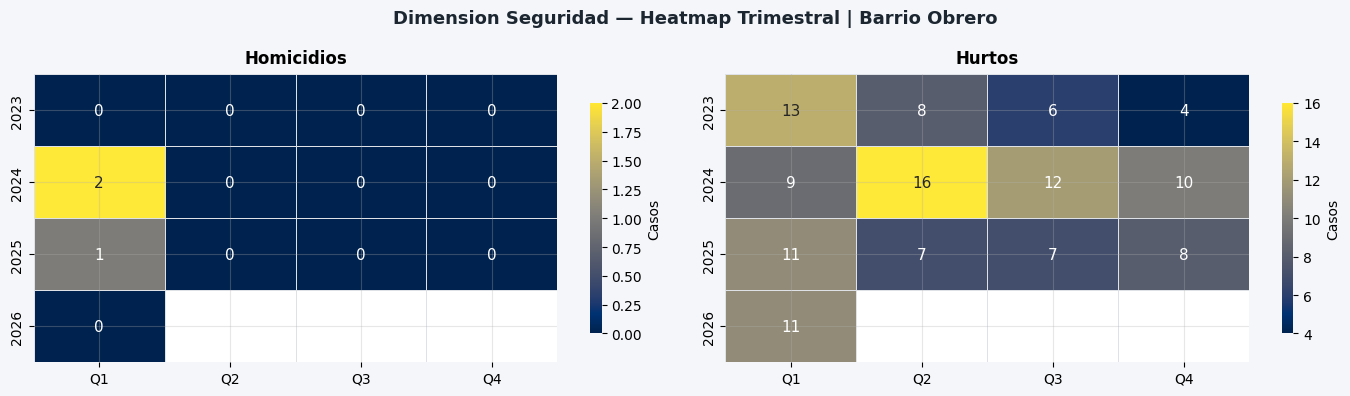

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)
fig.suptitle("Dimension Seguridad — Heatmap Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")
for ax, col, titulo_h in [
    (axes[0], "homicidios", "Homicidios"),
    (axes[1], "hurtos",     "Hurtos"),
    ]:
    pivot = corr_trim.pivot(index="año", columns="trimestre", values=col)
    pivot.columns = ["Q1","Q2","Q3","Q4"]
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="cividis",
        linewidths=0.5, linecolor="#DEE2E6", ax=ax, annot_kws={"size":11},
        cbar_kws={"label":"Casos","shrink":0.8})
    ax.set_title(titulo_h, fontweight="bold", pad=8)
    ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("itt_obrero_heatmap_seg.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


Conteo SPA por año y trimestre:
       Q1    Q2   Q3   Q4
año                      
2023  6.0   1.0  2.0  0.0
2024  0.0   1.0  0.0  0.0
2025  2.0  17.0  6.0  4.0
2026  2.0   NaN  NaN  NaN

Total 2023-2026 T1: 41 eventos  |  2023=9  |  2024=1  |  2025=29  |  2026=2


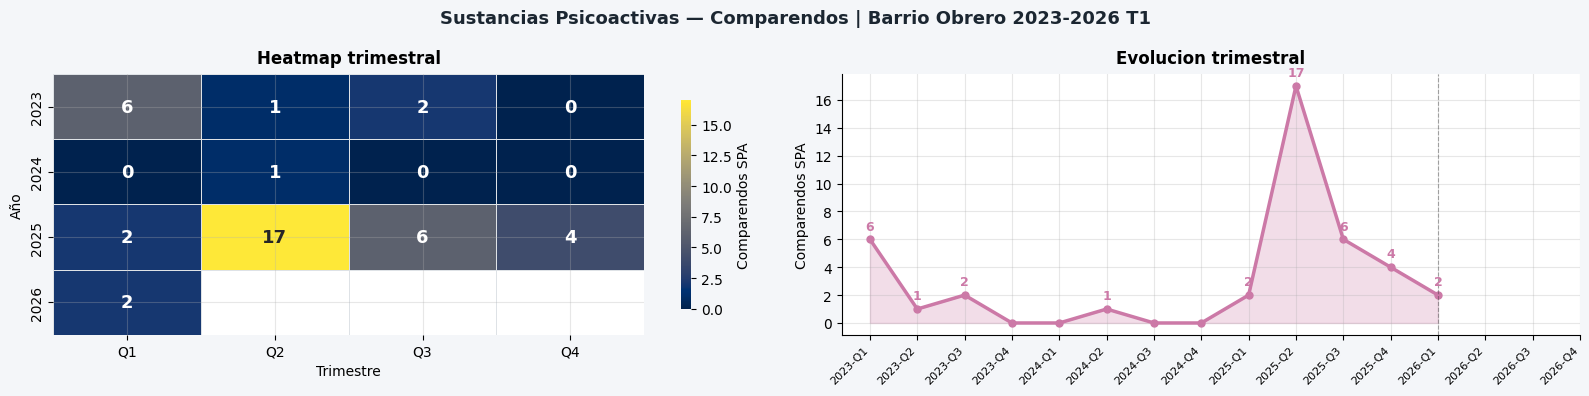


Sitios de ocurrencia:
sitio_hech
SITIOS PÚBLICOS O ABIERTOS AL PÚBLICO    41


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar SPA desde comparendos ya cargados
df_comp = pd.DataFrame([f['properties'] for f in raw_comp['features']])
df_spa = df_comp[df_comp['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
df_spa['_fecha'] = pd.to_datetime(df_spa['fecha_hech'], errors='coerce')
df_spa['año']       = df_spa['_fecha'].dt.year
df_spa['trimestre'] = df_spa['_fecha'].dt.quarter

ANIOS_SPA = [2023, 2024, 2025, 2026]
pivot_spa = (
    df_spa.groupby(['año','trimestre']).size()
    .unstack(fill_value=0)
    .reindex(index=ANIOS_SPA, fill_value=0)
    .reindex(columns=[1,2,3,4], fill_value=0)
    .astype(float)
)
pivot_spa.columns = ['Q1','Q2','Q3','Q4']

# 2026 solo tiene Q1: marcar Q2/Q3/Q4 como sin dato
pivot_spa.loc[2026, ['Q2','Q3','Q4']] = np.nan

print('Conteo SPA por año y trimestre:')
print(pivot_spa.to_string())
totales = {a: pivot_spa.loc[a].sum() for a in ANIOS_SPA}
print(f'\nTotal 2023-2026 T1: {df_spa.shape[0]} eventos  |  ' +
      '  |  '.join(f'{a}={int(totales[a]) if not pd.isna(totales[a]) else "?"}' for a in ANIOS_SPA))

fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Sustancias Psicoactivas — Comparendos | Barrio Obrero 2023-2026 T1',
             fontsize=13, fontweight='bold', color='#1B2631')

# Heatmap
mask_nan = pivot_spa.isna()
sns.heatmap(pivot_spa, annot=True, fmt='.0f', cmap='cividis',
    linewidths=0.5, linecolor='#DEE2E6', ax=axes[0],
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Comparendos SPA', 'shrink': 0.8},
    mask=mask_nan)
axes[0].set_title('Heatmap trimestral', fontweight='bold', pad=8)
axes[0].set_xlabel('Trimestre'); axes[0].set_ylabel('Año')

# Linea trimestral
periodos_spa = [f'{a}-Q{t}' for a in ANIOS_SPA for t in [1,2,3,4]]
x_spa = list(range(len(periodos_spa)))
vals_spa = [pivot_spa.loc[a, f'Q{t}'] for a in ANIOS_SPA for t in [1,2,3,4]]
vals_spa = [v if not pd.isna(v) else np.nan for v in vals_spa]

axes[1].fill_between(x_spa, vals_spa, alpha=0.25, color=OKI_MORADO)
axes[1].plot(x_spa, vals_spa, color=OKI_MORADO, linewidth=2.5, marker='o', markersize=5)
for i, v in enumerate(vals_spa):
    if pd.notna(v) and v > 0:
        axes[1].annotate(str(int(v)), (i, v),
            textcoords='offset points', xytext=(0, 7),
            ha='center', fontsize=9, fontweight='bold', color=OKI_MORADO)
ultimo_spa = max(i for i, v in enumerate(vals_spa) if pd.notna(v))
axes[1].axvline(ultimo_spa, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)
axes[1].set_xticks(x_spa)
axes[1].set_xticklabels(periodos_spa, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Evolucion trimestral', fontweight='bold', pad=8)
axes[1].set_ylabel('Comparendos SPA')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Detalle: sitios donde ocurren
print('\nSitios de ocurrencia:')
print(df_spa['sitio_hech'].value_counts().to_string())



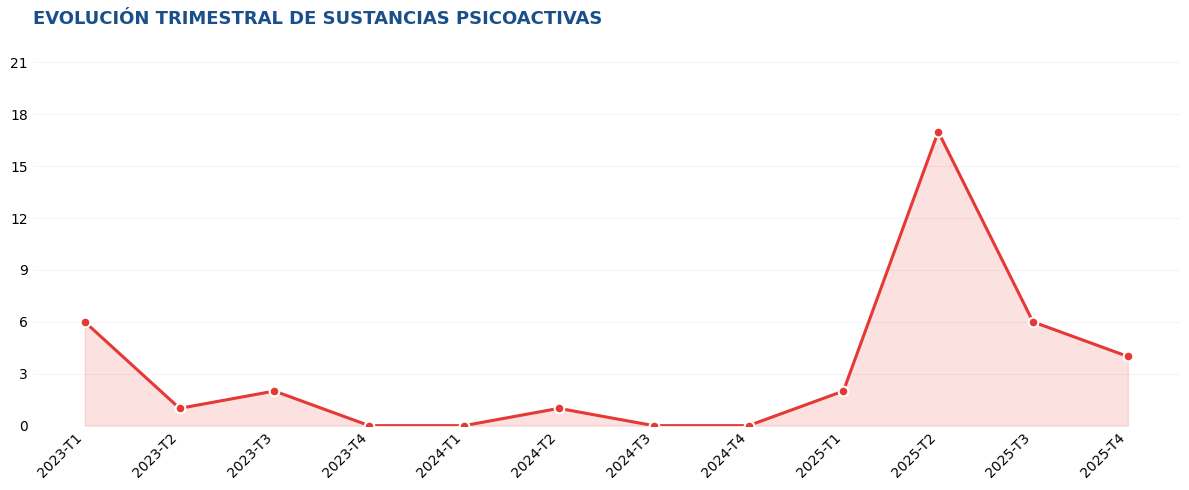

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# Preparar serie trimestral SPA
df_comp = pd.DataFrame([f['properties'] for f in raw_comp['features']])
df_spa = df_comp[df_comp['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
df_spa['_fecha'] = pd.to_datetime(df_spa['fecha_hech'], errors='coerce')
df_spa['año']       = df_spa['_fecha'].dt.year
df_spa['trimestre'] = df_spa['_fecha'].dt.quarter

ANIOS_SPA = [2023, 2024, 2025]
idx = pd.MultiIndex.from_product([ANIOS_SPA, [1,2,3,4]], names=['año','trimestre'])
serie = df_spa.groupby(['año','trimestre']).size().reindex(idx, fill_value=0).reset_index()
serie.columns = ['año','trimestre','casos']
serie['periodo'] = serie['año'].astype(str) + '-T' + serie['trimestre'].astype(str)

x = range(len(serie))
y = serie['casos'].values
labels = serie['periodo'].values

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')
ax.set_facecolor('white')

# Area + linea
ax.fill_between(x, y, alpha=0.15, color='#E53935')
ax.plot(x, y, color='#E53935', linewidth=2.2, marker='o',
        markersize=7, markerfacecolor='#E53935', markeredgecolor='white', markeredgewidth=1.5)

# Grilla horizontal suave
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(axis='y', color='#E0E0E0', linewidth=0.8, linestyle='-')
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

# Ejes
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, max(y) * 1.3 if max(y) > 0 else 5)
ax.tick_params(axis='y', labelsize=10)
for spine in ['top','right','left','bottom']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='both', length=0)

# Titulo estilo referencia
ax.set_title('EVOLUCIÓN TRIMESTRAL DE SUSTANCIAS PSICOACTIVAS',
             loc='left', fontsize=13, fontweight='bold', color='#1B4F8A', pad=14)

plt.tight_layout()
plt.show()


## Celda 12 — Evolucion trimestral: Seguridad


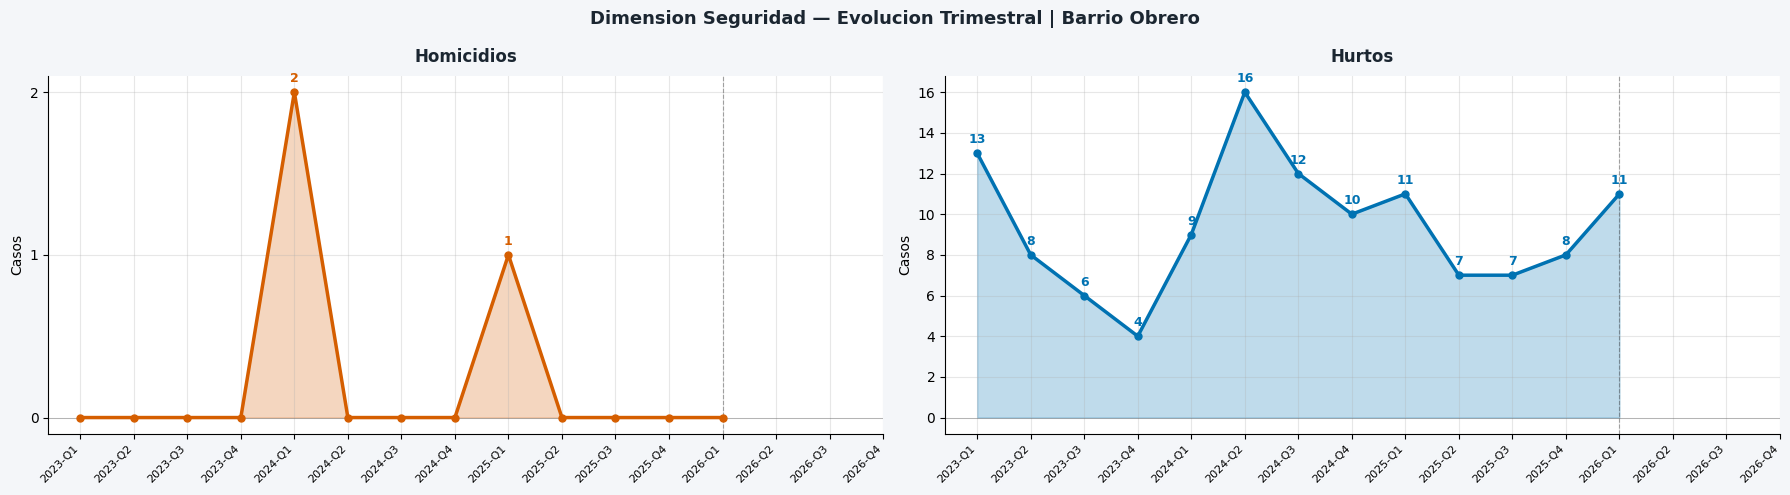

In [14]:
# Funcion reutilizable: linea + area rellena (NaN = hueco = sin dato)
periodos = corr_trim["periodo"].values
x = list(range(len(periodos)))

def plot_linefill(ax, col, titulo, color):
    vals = corr_trim[col].values.astype(float)
    valid = ~pd.isna(vals)
    ax.fill_between(x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(x, np.where(valid, vals, np.nan), color=color,
            linewidth=2.5, marker="o", markersize=5, zorder=3)
    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(str(int(v)), (i, v),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=9, fontweight="bold", color=color)
    ultimo_valido = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo_valido, color=OKI_GRIS, linewidth=0.8,
               linestyle="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=45, ha="right", fontsize=8)
    ax.set_title(titulo, fontweight="bold", pad=10, color="#1B2631")
    ax.set_ylabel("Casos")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle("Dimension Seguridad — Evolucion Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")
plot_linefill(axes[0], "homicidios", "Homicidios",  OKI_BERMELL)
plot_linefill(axes[1], "hurtos",     "Hurtos",       OKI_AZUL)
plt.tight_layout()
plt.savefig("itt_obrero_seg_trim.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## 2. Dimensión Cohesión Social — Peso: 9%

Indicadores: **VIF (Violencia Intrafamiliar)** · **Riñas / Conflictividad** · **SPA (Sustancias Psicoactivas)**
Fuente: DATIC 2023-2026 T1.
`score_cohesion = (score_vif + score_rinas + score_spa) / 3`
REF_VULNERABILIDAD (Sub PyE 2025) es dato de contexto — no entra al score.


## Celda 11 — Heatmap: Dimension Cohesion Social


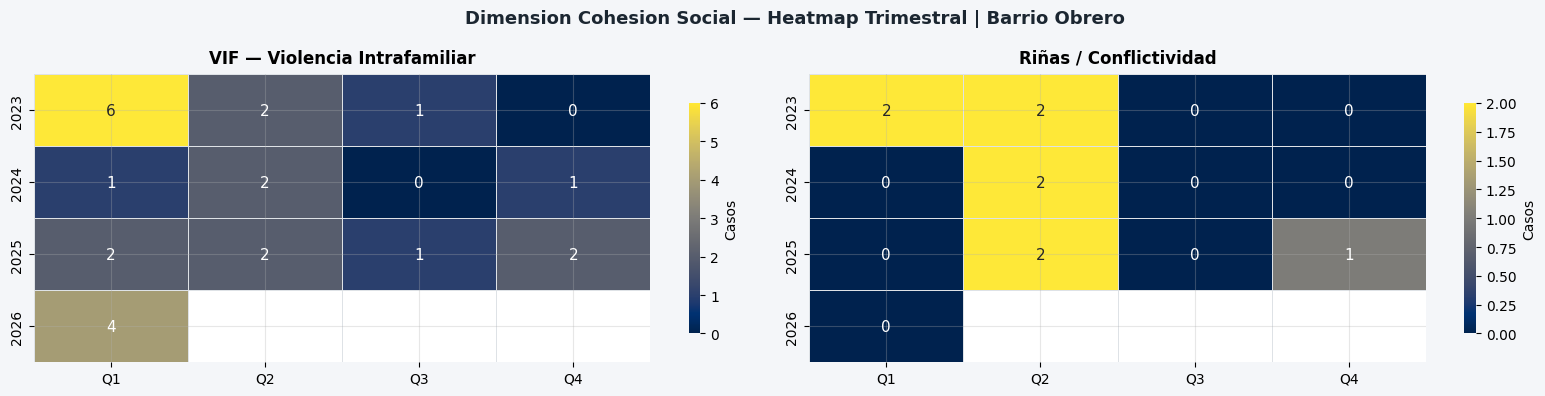

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle("Dimension Cohesion Social — Heatmap Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")
for ax, col, titulo_h in [
    (axes[0], "vif",   "VIF — Violencia Intrafamiliar"),
    (axes[1], "rinas", "Riñas / Conflictividad")]:
    pivot = corr_trim.pivot(index="año", columns="trimestre", values=col)
    pivot.columns = ["Q1","Q2","Q3","Q4"]
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="cividis",
        linewidths=0.5, linecolor="#DEE2E6", ax=ax, annot_kws={"size":11},
        cbar_kws={"label":"Casos","shrink":0.8})
    ax.set_title(titulo_h, fontweight="bold", pad=8)
    ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("itt_obrero_heatmap_coh.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## Celda 14 — Evolucion trimestral: Cohesion Social


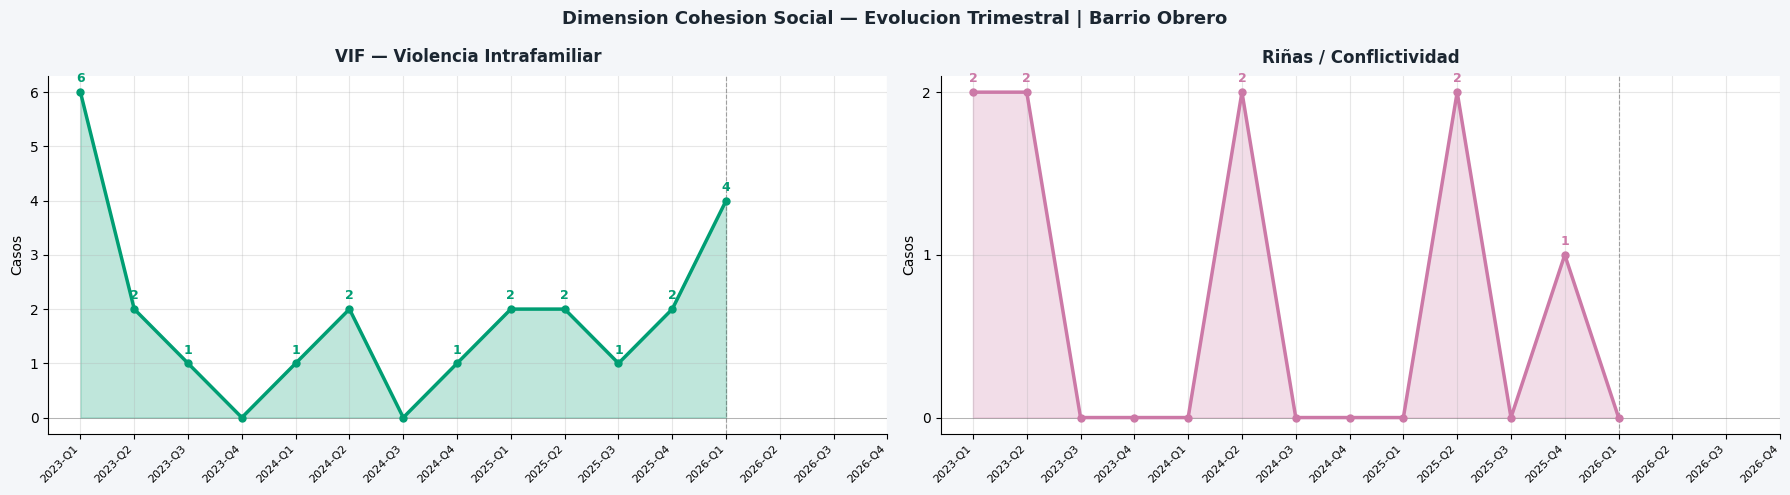

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle("Dimension Cohesion Social — Evolucion Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")
plot_linefill(axes[0], "vif",   "VIF — Violencia Intrafamiliar", OKI_VERDE)
plot_linefill(axes[1], "rinas", "Riñas / Conflictividad",        OKI_MORADO)
plt.tight_layout()
plt.savefig("itt_obrero_coh_trim.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

── Vulnerabilidad activa | Barrio Obrero (Sub PyE 2025) ──
  Personas : 73  |  Tasa: 54.1/1.000 hab  |  Score: 45.9


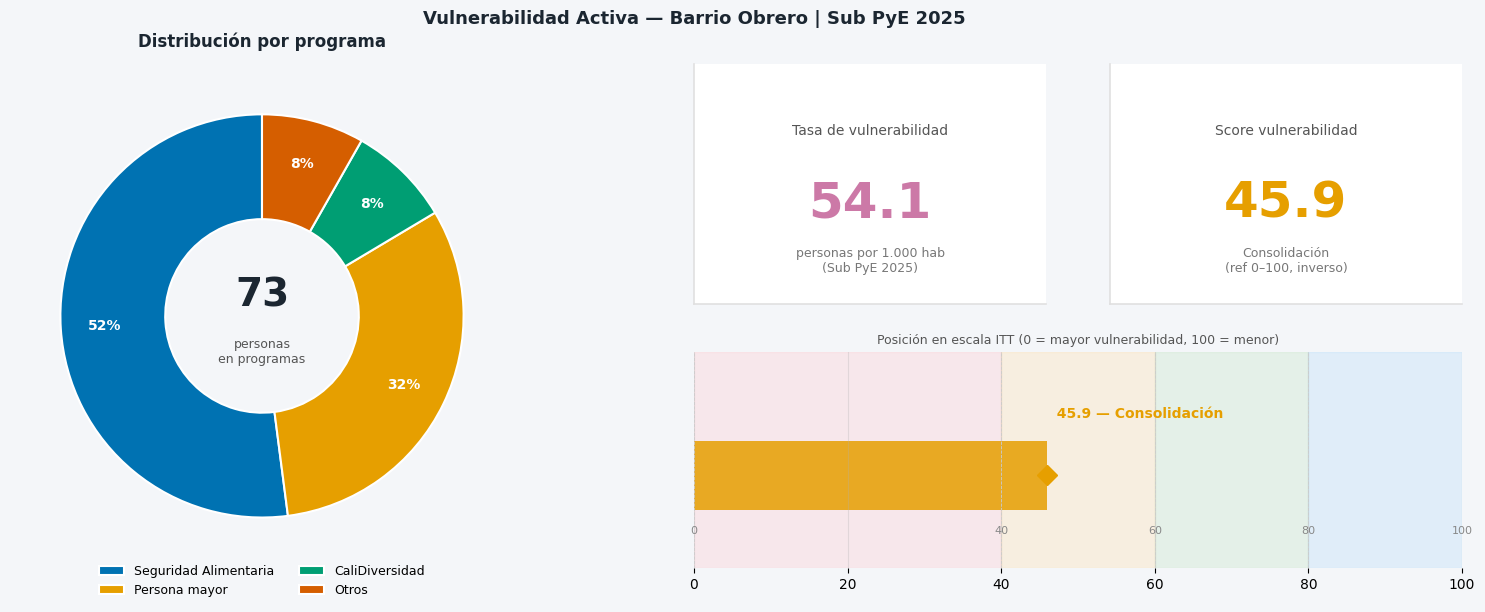

In [17]:
# ── Vulnerabilidad activa: Sub PyE 2025 ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

PATH_SUBPYE = str(REPO / "data" / "referencia" / "bienestar" /
                  "Caracterización Personas Sub PyE (2025).xlsx")
COL_BARRIO = "[Barrio de residencia] ¿En cuál barrio reside?"
COL_PROG   = "¿En cuál programa está siendo atendida la persona?"

POB_OBRERO   = 1349
VULN_REF_MIN = 0
VULN_REF_MAX = 100

df_sub    = pd.read_excel(PATH_SUBPYE)
mask_ob   = df_sub[COL_BARRIO].astype(str).str.upper().str.strip().str.contains("OBRERO", na=False)
df_ob     = df_sub[mask_ob].copy()

n_personas = len(df_ob)
tasa_vuln  = n_personas / POB_OBRERO * 1000
raw        = np.clip((tasa_vuln - VULN_REF_MIN) / (VULN_REF_MAX - VULN_REF_MIN) * 100, 0, 100)
score_vuln = round(100 - raw, 1)
REF_VULNERABILIDAD = score_vuln

print("── Vulnerabilidad activa | Barrio Obrero (Sub PyE 2025) ──")
print(f"  Personas : {n_personas}  |  Tasa: {tasa_vuln:.1f}/1.000 hab  |  Score: {score_vuln}")

# ── Preparar datos donut ──────────────────────────────────────────────────────
progs = df_ob[COL_PROG].value_counts()
# Agrupar slices < 5% en "Otros"
total_p  = progs.sum()
mask_peq = progs / total_p < 0.05
otros_n  = progs[mask_peq].sum()
progs_clean = progs[~mask_peq].copy()
if otros_n > 0:
    progs_clean["Otros"] = otros_n

colores_donut = [OKI_AZUL, OKI_NARANJA, OKI_VERDE, OKI_BERMELL, OKI_MORADO][:len(progs_clean)]

# ── Layout: 1 donut + 2 cards ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG)
fig.suptitle("Vulnerabilidad Activa — Barrio Obrero | Sub PyE 2025",
             fontsize=13, fontweight="bold", color="#1B2631", y=1.01)

ax_donut = fig.add_axes([0.02, 0.08, 0.42, 0.84])   # izquierda
ax_card1 = fig.add_axes([0.50, 0.52, 0.22, 0.40])   # card superior
ax_card2 = fig.add_axes([0.76, 0.52, 0.22, 0.40])   # card superior derecha
ax_bar   = fig.add_axes([0.50, 0.08, 0.48, 0.36])   # barra inferior

# ── Donut ────────────────────────────────────────────────────────────────────
wedges, texts, autotexts = ax_donut.pie(
    progs_clean.values,
    labels=None,
    autopct="%1.0f%%",
    colors=colores_donut,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
ax_donut.legend(
    wedges, progs_clean.index,
    loc="lower center", bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=9, frameon=False
)
ax_donut.text(0, 0.1, str(n_personas), ha="center", va="center",
              fontsize=28, fontweight="bold", color="#1B2631")
ax_donut.text(0, -0.18, "personas\nen programas", ha="center", va="center",
              fontsize=9, color="#555555")
ax_donut.set_title("Distribución por programa", fontweight="bold",
                   color="#1B2631", pad=12)

# ── Card 1: Tasa por 1.000 hab ───────────────────────────────────────────────
for ax_c in [ax_card1, ax_card2]:
    ax_c.set_facecolor("white")
    ax_c.set_xticks([]); ax_c.set_yticks([])
    for spine in ax_c.spines.values():
        spine.set_edgecolor("#E0E0E0"); spine.set_linewidth(1.2)

ax_card1.text(0.5, 0.72, "Tasa de vulnerabilidad",
              ha="center", va="center", fontsize=10, color="#555555",
              transform=ax_card1.transAxes)
ax_card1.text(0.5, 0.42, f"{tasa_vuln:.1f}",
              ha="center", va="center", fontsize=36, fontweight="bold",
              color=OKI_MORADO, transform=ax_card1.transAxes)
ax_card1.text(0.5, 0.18, "personas por 1.000 hab\n(Sub PyE 2025)",
              ha="center", va="center", fontsize=9, color="#777777",
              transform=ax_card1.transAxes)

# ── Card 2: Score cohesión ────────────────────────────────────────────────────
nivel_color = (OKI_BERMELL if score_vuln < 40 else
               OKI_NARANJA if score_vuln < 60 else
               OKI_VERDE   if score_vuln < 80 else OKI_AZUL)
nivel_lbl   = ("Activación"    if score_vuln < 40 else
               "Consolidación" if score_vuln < 60 else
               "Transformación" if score_vuln < 80 else "Escala")

ax_card2.text(0.5, 0.72, "Score vulnerabilidad",
              ha="center", va="center", fontsize=10, color="#555555",
              transform=ax_card2.transAxes)
ax_card2.text(0.5, 0.42, f"{score_vuln}",
              ha="center", va="center", fontsize=36, fontweight="bold",
              color=nivel_color, transform=ax_card2.transAxes)
ax_card2.text(0.5, 0.18, f"{nivel_lbl}\n(ref 0–100, inverso)",
              ha="center", va="center", fontsize=9, color="#777777",
              transform=ax_card2.transAxes)

# ── Barra de contexto ─────────────────────────────────────────────────────────
ax_bar.set_facecolor(BG)
for spine in ax_bar.spines.values(): spine.set_visible(False)
niveles_bg = [(0,40,"#FFCDD2"),(40,60,"#FFE0B2"),(60,80,"#C8E6C9"),(80,100,"#BBDEFB")]
for x0, x1, c in niveles_bg:
    ax_bar.axvspan(x0, x1, alpha=0.35, color=c)
ax_bar.barh([0], [score_vuln], color=nivel_color, alpha=0.85, height=0.45)
ax_bar.plot(score_vuln, 0, marker="D", ms=10, color=nivel_color, zorder=5)
ax_bar.text(score_vuln, 0.35, f"  {score_vuln} — {nivel_lbl}",
            va="bottom", fontsize=10, fontweight="bold", color=nivel_color)
for x, lbl in [(0,"0"),(40,"40"),(60,"60"),(80,"80"),(100,"100")]:
    ax_bar.axvline(x, color="#CCCCCC", linewidth=0.6, linestyle="--")
    ax_bar.text(x, -0.38, lbl, ha="center", fontsize=8, color="#888888")
ax_bar.set_xlim(0, 100); ax_bar.set_ylim(-0.6, 0.8)
ax_bar.set_yticks([])
ax_bar.set_title("Posición en escala ITT (0 = mayor vulnerabilidad, 100 = menor)",
                 fontsize=9, color="#555555", pad=6)

plt.savefig("itt_obrero_vulnerabilidad.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()


## 3. Dimensión Movilidad — Peso: 22%

Indicadores: **Siniestralidad total** · **Accidentes con lesionados** · **Accidentes mortales**
Fuente: Siniestros viales Barrio Obrero 2023-2026 T2. 2026-Q3/Q4 sin dato.
`score_movilidad = (score_siniestralidad + score_lesionados + score_mortales) / 3`


## Celda 10 — Heatmap: Dimension Movilidad


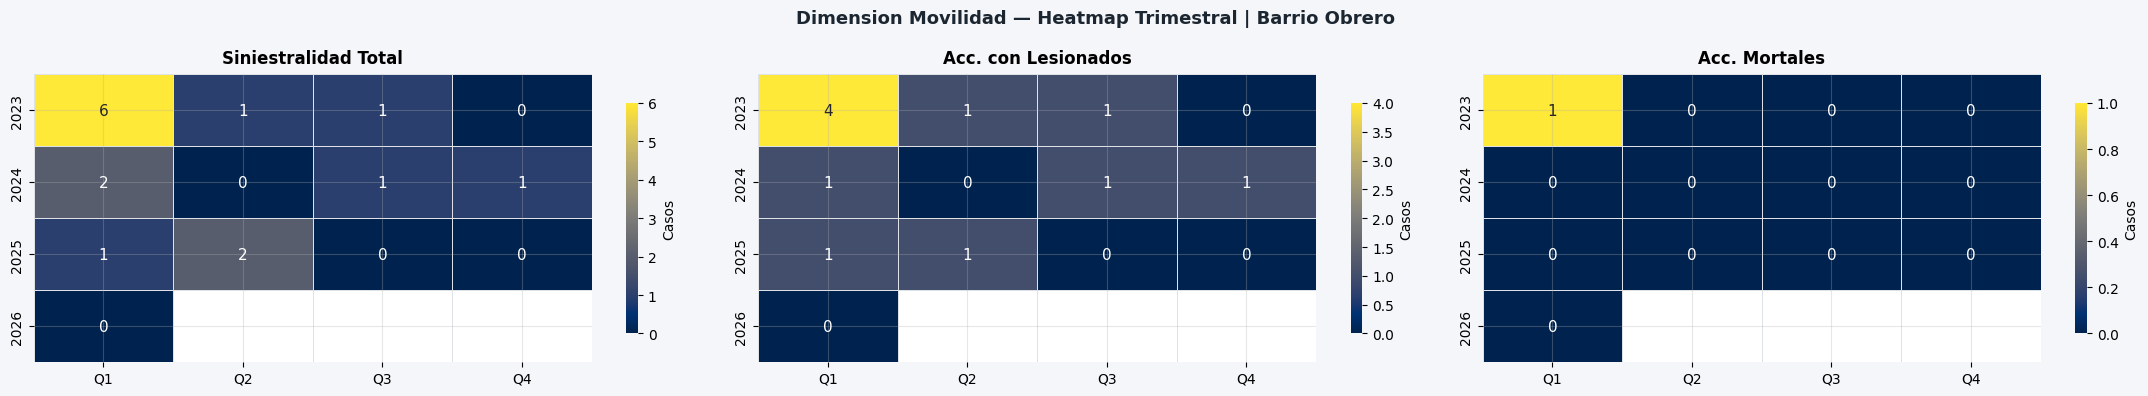

In [38]:
_corr_trim = corr_trim.copy()
_corr_trim = _corr_trim[
    (_corr_trim["año"] < 2026) |
    ((_corr_trim["año"] == 2026) & (_corr_trim["trimestre"] <= 1))
].copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 4), facecolor=BG)
fig.suptitle("Dimension Movilidad — Heatmap Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")

for ax, col, titulo_h in [
    (axes[0], "siniestralidad", "Siniestralidad Total"),
    (axes[1], "lesionados",     "Acc. con Lesionados"),
    (axes[2], "mortales",       "Acc. Mortales")
]:
    pivot = _corr_trim.pivot(index="año", columns="trimestre", values=col)
    pivot = pivot.reindex(columns=[1, 2, 3, 4])
    pivot.columns = ["Q1", "Q2", "Q3", "Q4"]

    sns.heatmap(
        pivot, annot=True, fmt=".0f", cmap="cividis",
        linewidths=0.5, linecolor="#DEE2E6", ax=ax, annot_kws={"size": 11},
        cbar_kws={"label": "Casos", "shrink": 0.8}
    )
    ax.set_title(titulo_h, fontweight="bold", pad=8)
    ax.set_ylabel("")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("itt_obrero_heatmap_mov_q1_2026.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

## Celda 13 — Evolucion trimestral: Movilidad


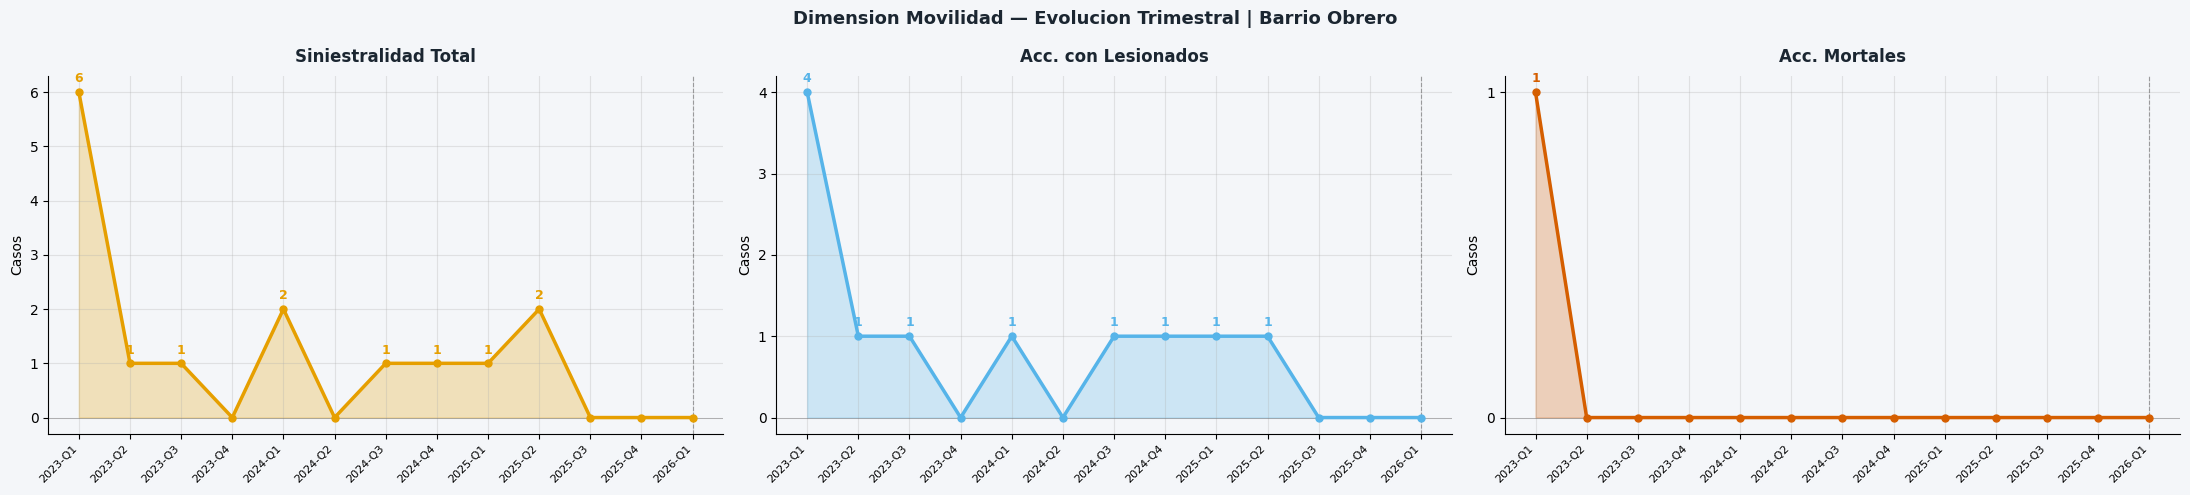

In [39]:
# ── Dimension Movilidad — Evolucion Trimestral | Barrio Obrero (hasta 2026-Q1) ──
_corr_trim = corr_trim.copy()
_corr_trim = _corr_trim[
    (_corr_trim["año"] < 2026) |
    ((_corr_trim["año"] == 2026) & (_corr_trim["trimestre"] <= 1))
].copy()

_periodos = _corr_trim["periodo"].tolist()
_x = np.arange(len(_periodos))

fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor=BG)
fig.suptitle("Dimension Movilidad — Evolucion Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")

cfg = [
    (axes[0], "siniestralidad", "Siniestralidad Total", OKI_NARANJA),
    (axes[1], "lesionados",     "Acc. con Lesionados",  OKI_AZUL_C),
    (axes[2], "mortales",       "Acc. Mortales",        OKI_BERMELL),
]

for ax, col, titulo, color in cfg:
    vals = _corr_trim[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.5, marker="o", markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(
                str(int(v)), (i, v),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=9, fontweight="bold", color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha="right", fontsize=8)
    ax.set_title(titulo, fontweight="bold", pad=10, color="#1B2631")
    ax.set_ylabel("Casos")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.set_facecolor(BG)

plt.tight_layout()
plt.savefig("itt_obrero_mov_trim_q1_2026.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## 4. Dimensión Entorno Urbano — Peso: 17%

Indicadores: **NDVI / Área Verde Neta** · **Árboles DAGMA** · **Déficit Habitacional Cualitativo**
Fuente: Rasters NDVI 2023-2026 (rasterio) + DAGMA árboles 2025 + DANE Déficit 2024.
Métrica anual — se extiende plana dentro de cada año en la serie trimestral.


## Celda 3B — Proxy de Entorno Urbano para Barrio Obrero

Esta celda recalcula `REF_ENTORNO_U` usando el Excel de `deficit habitacional` en `data/referencia/`.

- Base territorial: `Comuna 9`, usada como proxy para `Barrio Obrero`.
- Variable principal: `Deficit Cualitativo`.
- Variable de intensidad: `Deficit Cualitativo / Deficit Habitacional`.
- Regla de score: ambos componentes se normalizan a `0-100` con referencias fijas y luego se promedian.
- Si el Excel no aparece o no encuentra la Comuna 9, el notebook conserva el valor previo de `REF_ENTORNO_U`.


In [20]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Proxy de Entorno Urbano para Barrio Obrero usando deficit habitacional (Comuna 9).
# Este bloque sustituye el referente fijo solo para esta corrida si encuentra el Excel.
# Si falla la lectura, se mantiene el valor previo heredado de Pulmon de Oriente.
REF_ENTORNO_U = globals().get('REF_ENTORNO_U', 39.2)
FUENTE_ENTORNO_U = globals().get('FUENTE_ENTORNO_U', 'Pulmon de Oriente (referente fijo)')
DETALLE_ENTORNO_U = globals().get('DETALLE_ENTORNO_U', f'Score fijo heredado={REF_ENTORNO_U:.1f}')

PATH_PROXY_ENTORNO = [
    Path('/content/itt_repos_cali/data/referencia/vivienda/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx'),
    Path('data/referencia/vivienda/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx'),
    Path('./data/referencia/vivienda/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx'),
]

proxy_path = next((p for p in PATH_PROXY_ENTORNO if p.exists()), None)
if proxy_path is None:
    print('No se encontro el Excel de referencia. REF_ENTORNO_U conserva su valor actual:', REF_ENTORNO_U)
else:
    def score_ref_proxy(valor, ref_min, ref_max, inverso=True):
        if ref_max == ref_min:
            return 100.0
        raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
        return 100 - raw if inverso else raw

    df_proxy = pd.read_excel(proxy_path, sheet_name='Hoja1')
    df_proxy.columns = [str(c).strip() for c in df_proxy.columns]

    # Se toma la Comuna 9 como aproximacion territorial a Barrio Obrero.
    col_area = 'Comuna o Corregimiento'
    col_total = 'Déficit Habitacional'
    col_cual = 'Déficit Cualitativo'

    fila_c9 = df_proxy.loc[df_proxy[col_area].astype(str).str.strip() == '9']
    if fila_c9.empty:
        print('No se encontro la Comuna 9 en el Excel. REF_ENTORNO_U conserva su valor actual:', REF_ENTORNO_U)
    else:
        deficit_total = float(fila_c9.iloc[0][col_total])
        deficit_cual = float(fila_c9.iloc[0][col_cual])
        deficit_pct = (deficit_cual / deficit_total) * 100 if deficit_total else np.nan

        # Referencias fijas de Hoja1 (38 comunas/corregimientos), no min-max de la muestra local.
        REF_MIN_DEFICIT_CUAL = 86.0
        REF_MAX_DEFICIT_CUAL = 20179.0
        REF_MIN_DEFICIT_PCT = 69.8
        REF_MAX_DEFICIT_PCT = 96.6

        # Componente 1: volumen absoluto de deficit cualitativo.
        score_proxy_volumen = score_ref_proxy(deficit_cual, REF_MIN_DEFICIT_CUAL, REF_MAX_DEFICIT_CUAL, True)
        # Componente 2: intensidad relativa del deficit cualitativo dentro del deficit total.
        score_proxy_intensidad = score_ref_proxy(deficit_pct, REF_MIN_DEFICIT_PCT, REF_MAX_DEFICIT_PCT, True)

        # Proxy final de Entorno Urbano = promedio simple de ambos componentes.
        REF_ENTORNO_U = round((score_proxy_volumen + score_proxy_intensidad) / 2, 1)
        FUENTE_ENTORNO_U = 'Proxy por deficit habitacional (Comuna 9)'
        DETALLE_ENTORNO_U = (
            f'Deficit cualitativo={deficit_cual:,.0f}; '
            f'proporcion={deficit_pct:.1f}%; '
            f'score_volumen={score_proxy_volumen:.1f}; '
            f'score_intensidad={score_proxy_intensidad:.1f}; '
            f'promedio={REF_ENTORNO_U:.1f}'
        )

        print('Proxy Entorno Urbano activado para Barrio Obrero')
        print('Fuente:', proxy_path)
        print('Base territorial:', 'Comuna 9 (proxy para Barrio Obrero)')
        print(f'Deficit cualitativo: {deficit_cual:,.0f}')
        print(f'Deficit cualitativo / deficit habitacional: {deficit_pct:.1f}%')
        print(f'Score proxy volumen: {score_proxy_volumen:.1f}')
        print(f'Score proxy intensidad: {score_proxy_intensidad:.1f}')
        print(f'Nuevo REF_ENTORNO_U: {REF_ENTORNO_U:.1f}')


Proxy Entorno Urbano activado para Barrio Obrero
Fuente: /content/itt_repos_cali/data/referencia/vivienda/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx
Base territorial: Comuna 9 (proxy para Barrio Obrero)
Deficit cualitativo: 3,156
Deficit cualitativo / deficit habitacional: 87.5%
Score proxy volumen: 84.7
Score proxy intensidad: 33.8
Nuevo REF_ENTORNO_U: 59.3


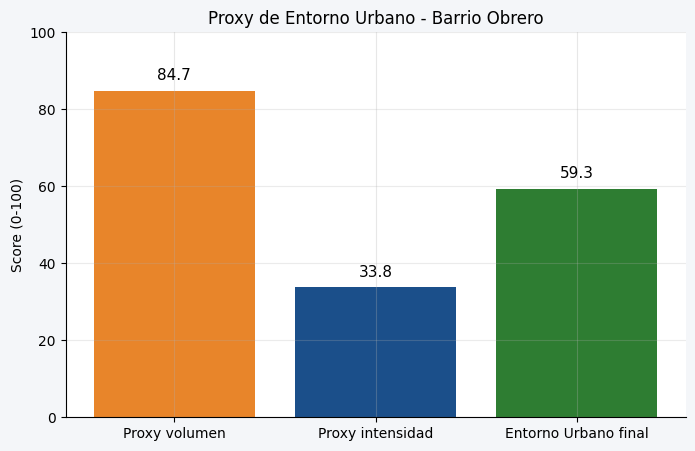

In [21]:
import matplotlib.pyplot as plt

labels = [
    'Proxy volumen',
    'Proxy intensidad',
    'Entorno Urbano final'
]
values = [
    score_proxy_volumen,
    score_proxy_intensidad,
    REF_ENTORNO_U
]
colors = ['#E8852A', '#1B4F8A', '#2E7D32']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylim(0, 100)
plt.ylabel('Score (0-100)')
plt.title('Proxy de Entorno Urbano - Barrio Obrero')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}',
             ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.show()


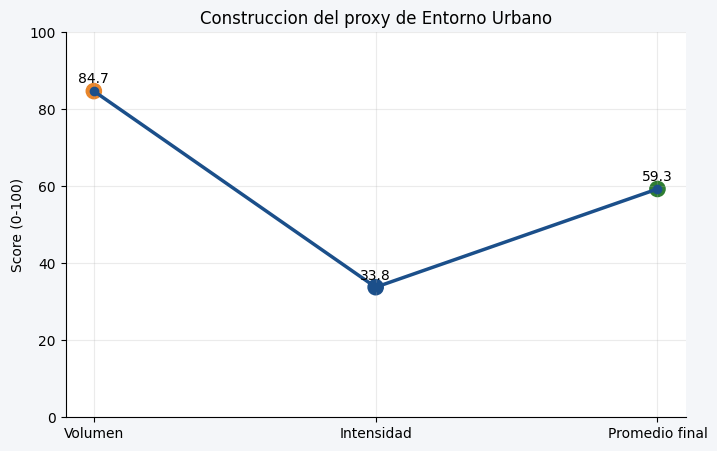

In [22]:
import matplotlib.pyplot as plt

x = ['Volumen', 'Intensidad', 'Promedio final']
y = [score_proxy_volumen, score_proxy_intensidad, REF_ENTORNO_U]

plt.figure(figsize=(8,5))
plt.plot(x, y, marker='o', linewidth=2.5, color='#1B4F8A')
plt.scatter(x, y, s=120, color=['#E8852A', '#1B4F8A', '#2E7D32'])

for xi, yi in zip(x, y):
    plt.text(xi, yi + 2, f'{yi:.1f}', ha='center')

plt.ylim(0, 100)
plt.ylabel('Score (0-100)')
plt.title('Construccion del proxy de Entorno Urbano')
plt.grid(alpha=0.25)
plt.show()


## Celda 3C — Heatmap de componentes del déficit cualitativo (2024)

Esta visualizacion muestra la composicion interna del `Deficit Cualitativo` usado como proxy de `Entorno Urbano`.

- Base territorial: `Comuna 9`, usada como proxy para `Barrio Obrero`.
- Periodo: `2024`.
- Lectura recomendada: colores mas intensos indican mayor peso dentro del deficit cualitativo total.
- Nota metodologica: es un corte anual 2024, no una serie mensual ni trimestral observada.


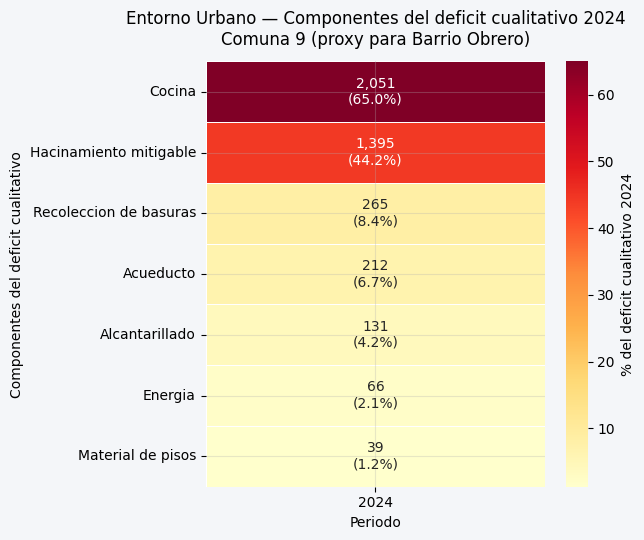

Composicion del deficit cualitativo 2024:
            componente  valor_2024  pct_deficit_cual
                Cocina      2051.0              65.0
Hacinamiento mitigable      1395.0              44.2
Recoleccion de basuras       265.0               8.4
             Acueducto       212.0               6.7
        Alcantarillado       131.0               4.2
               Energia        66.0               2.1
     Material de pisos        39.0               1.2


In [23]:
# Heatmap de componentes del deficit cualitativo 2024 para Comuna 9 / proxy de Barrio Obrero.
if 'fila_c9' not in globals() or fila_c9.empty:
    print('No hay fila de Comuna 9 cargada desde el Excel de referencia.')
else:
    cols_componentes = {
        'Hacinamiento mitigable': 'Déficit cualitativo Hacinamiento mitigable',
        'Material de pisos': 'Déficit cualitativo Material de pisos',
        'Cocina': 'Déficit cualitativo Cocina',
        'Acueducto': 'Déficit cualitativo Acueducto',
        'Alcantarillado': 'Déficit cualitativo Alcantarillado',
        'Energia': 'Déficit cualitativo Energia',
        'Recoleccion de basuras': 'Déficit cualitativo Recolección de basuras',
    }

    componentes_2024 = []
    for nombre, col in cols_componentes.items():
        valor = float(fila_c9.iloc[0][col])
        pct = (valor / deficit_cual * 100) if deficit_cual else 0.0
        componentes_2024.append({
            'componente': nombre,
            'valor_2024': valor,
            'pct_deficit_cual': pct,
            'etiqueta': f'{valor:,.0f}\n({pct:.1f}%)'
        })

    df_entorno_comp = pd.DataFrame(componentes_2024).sort_values('pct_deficit_cual', ascending=False)
    proxy_entorno_componentes_2024 = df_entorno_comp.copy()

    matriz = df_entorno_comp.set_index('componente')[['pct_deficit_cual']]
    matriz.columns = ['2024']
    anot = df_entorno_comp.set_index('componente')[['etiqueta']]
    anot.columns = ['2024']

    plt.figure(figsize=(6.5, 5.5))
    ax = sns.heatmap(
        matriz,
        annot=anot,
        fmt='',
        cmap='YlOrRd',
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': '% del deficit cualitativo 2024'}
    )
    ax.set_title('Entorno Urbano — Componentes del deficit cualitativo 2024\nComuna 9 (proxy para Barrio Obrero)', pad=12)
    ax.set_xlabel('Periodo')
    ax.set_ylabel('Componentes del deficit cualitativo')
    plt.tight_layout()
    plt.show()

    print('Composicion del deficit cualitativo 2024:')
    print(df_entorno_comp[['componente', 'valor_2024', 'pct_deficit_cual']].round({'valor_2024': 0, 'pct_deficit_cual': 1}).to_string(index=False))


## Celda EU — Entorno Urbano

Calcula el score de **Entorno Urbano** desde dos indicadores con datos reales del polígono:

- **NDVI / Área verde** (rasters TIF 2023-2026): % del barrio con NDVI ≥ 0.20 → serie anual.
- **Árboles DAGMA**: 151 puntos → densidad árb/ha → score estático aplicado a todos los años.

Composite: 50% score área verde + 50% score árboles. Reemplaza `REF_ENTORNO_U = 39.2` en `base`.

In [24]:
# ── Celda EU-1: procesar rasters NDVI (rasterio) ─────────────────────────────
import subprocess, importlib.util
import numpy as np
from pathlib import Path

if importlib.util.find_spec('rasterio') is None:
    subprocess.run(['pip', 'install', 'rasterio', '-q'], check=False)
import rasterio

NDVI_DIR    = DATA_DIR / '5_Entorno_Urbano' / 'NDVI_Barrio_Obrero'
NDVI_UMBRAL = 0.20
ARBOLES_N   = len(raw_arb['features'])   # cargado en Celda 4

ndvi_stats = {}
AREA_HA    = None

for año in ANIOS:
    tif = NDVI_DIR / f'Barrio_Obrero_ndvi_{año}.tif'
    if not tif.exists():
        print(f'  {año}: raster no encontrado')
        ndvi_stats[año] = {'ndvi_mean': np.nan, 'verde_m2': np.nan, 'pct_verde': np.nan}
        continue
    with rasterio.open(tif) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        # Pixel en m² (CRS geográfico, lat ~3.44°)
        px_lon_m = abs(src.transform.a) * 111320 * np.cos(np.radians(3.44))
        px_lat_m = abs(src.transform.e) * 110540
        px_area  = px_lon_m * px_lat_m
        total_px  = int(np.sum(~np.isnan(data)))
        verde_px  = int(np.sum(data >= NDVI_UMBRAL))
        ndvi_mean = round(float(np.nanmean(data)), 4)
        verde_m2  = round(verde_px * px_area)
        total_m2  = round(total_px * px_area)
        pct_verde = round(verde_px / total_px * 100, 1) if total_px > 0 else 0
        ndvi_stats[año] = {'ndvi_mean': ndvi_mean, 'verde_m2': verde_m2,
                           'pct_verde': pct_verde, 'total_m2': total_m2}
        if AREA_HA is None:
            AREA_HA = round(total_m2 / 10000, 2)
    print(f'{año}: NDVI_medio={ndvi_mean}  |  área_verde={verde_m2} m² ({pct_verde}%)')

dens_arboles_ha = round(ARBOLES_N / AREA_HA, 1) if AREA_HA else np.nan
print(f'\nÁrboles: {ARBOLES_N}  |  Área barrio: {AREA_HA} ha  |  Densidad: {dens_arboles_ha} árb/ha')


2023: NDVI_medio=0.0687  |  área_verde=5154 m² (6.4%)
2024: NDVI_medio=0.0809  |  área_verde=6938 m² (8.6%)
2025: NDVI_medio=0.0804  |  área_verde=6245 m² (7.8%)
2026: NDVI_medio=0.0688  |  área_verde=3469 m² (4.3%)

Árboles: 151  |  Área barrio: 8.03 ha  |  Densidad: 18.8 árb/ha


In [25]:
# ── Celda EU-2: scores EntornoU → actualizar base + recalcular ITT ───────────
REF_VERDE_MIN,   REF_VERDE_MAX   = 0, 30   # % área verde
REF_ARBOLES_MIN, REF_ARBOLES_MAX = 0, 50   # árboles/ha

score_arboles_fijo = round(score_ref(dens_arboles_ha,
                                     REF_ARBOLES_MIN, REF_ARBOLES_MAX, False), 1)
print(f'Score árboles (estático): {score_arboles_fijo}  ({dens_arboles_ha} árb/ha, ref 0-50)')

rows_eu = []
for año in ANIOS:
    st  = ndvi_stats.get(año, {})
    pct = st.get('pct_verde', np.nan)
    sc_verde = score_ref(pct, REF_VERDE_MIN, REF_VERDE_MAX, False) if not np.isnan(pct) else np.nan
    sc_eu    = round((sc_verde + score_arboles_fijo) / 2, 1) if not np.isnan(sc_verde) else score_arboles_fijo
    rows_eu.append(dict(
        año=año,
        ndvi_mean=st.get('ndvi_mean', np.nan),
        pct_verde=pct,
        verde_m2=st.get('verde_m2', np.nan),
        score_verde=sc_verde,
        score_arboles=score_arboles_fijo,
        score_entorno_u=sc_eu
    ))

df_eu = pd.DataFrame(rows_eu)

print()
print('── Entorno Urbano: indicadores y scores ─────────────────────────────────')
print(df_eu[['año','ndvi_mean','pct_verde','verde_m2','score_verde',
             'score_arboles','score_entorno_u']].to_string(index=False))
print()

# Actualizar base
for _, row in df_eu.iterrows():
    base.loc[base['año'] == int(row['año']), 'score_entorno_u'] = row['score_entorno_u']

# Recalcular ITT
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des']  +
    PESOS['Cohesion']  * base['score_cohesion']
)
base['nivel'] = base['ITT'].apply(clasificar)

print('ITT actualizado — EntornoU real (NDVI + árboles):')
print(base[['año','score_entorno_u','ITT','nivel']].round(1).to_string(index=False))


Score árboles (estático): 37.6  (18.8 árb/ha, ref 0-50)

── Entorno Urbano: indicadores y scores ─────────────────────────────────
 año  ndvi_mean  pct_verde  verde_m2  score_verde  score_arboles  score_entorno_u
2023     0.0687        6.4      5154    21.333333           37.6             29.5
2024     0.0809        8.6      6938    28.666667           37.6             33.1
2025     0.0804        7.8      6245    26.000000           37.6             31.8
2026     0.0688        4.3      3469    14.333333           37.6             26.0

ITT actualizado — EntornoU real (NDVI + árboles):
 año  score_entorno_u  ITT          nivel
2023             29.5 47.8  Consolidacion
2024             33.1 49.3  Consolidacion
2025             31.8 53.1  Consolidacion
2026             26.0 66.4 Transformacion


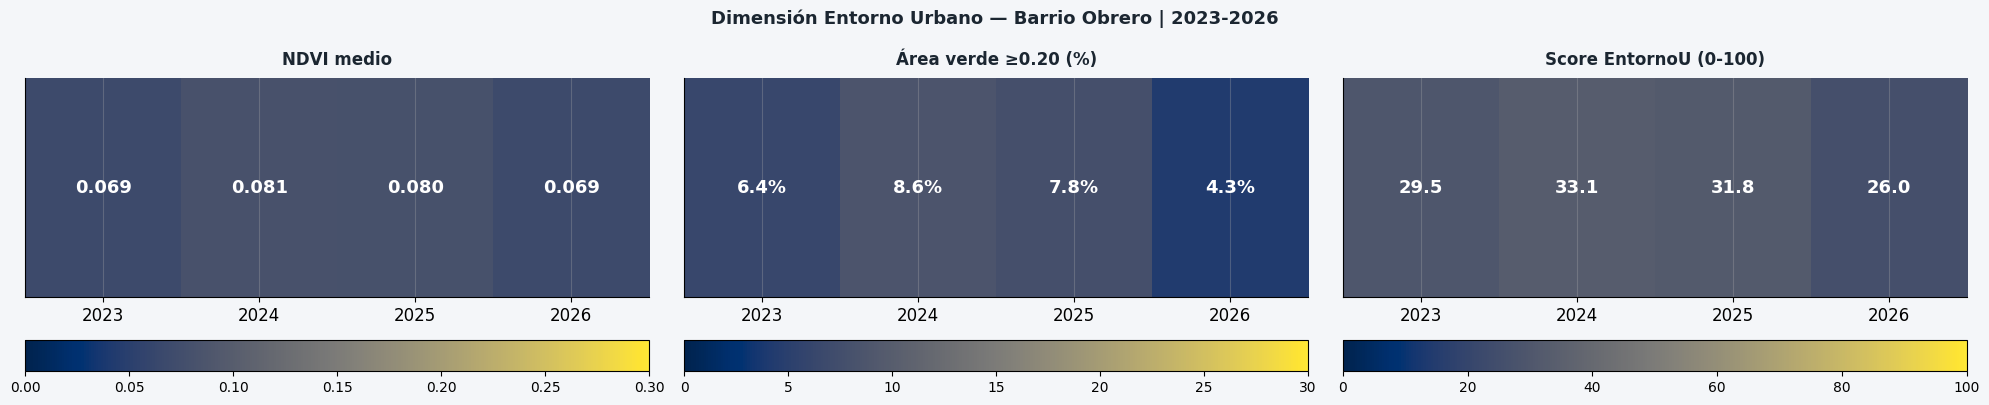

In [26]:
# ── Celda EU-3: heatmap Entorno Urbano ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimensión Entorno Urbano — Barrio Obrero | 2023-2026',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_eu.set_index('año').reindex(ANIOS)
configs_hm = [
    ('ndvi_mean',       'NDVI medio',            'cividis', 0,    0.30, ''),
    ('pct_verde',       'Área verde ≥0.20 (%)',  'cividis', 0,    30,   '%'),
    ('score_entorno_u', 'Score EntornoU (0-100)', 'cividis', 0,   100,  ''),
]
for ax, (col, titulo, cmap, vmin, vmax, sfx) in zip(axes, configs_hm):
    vals = df_e[col].values.astype(float).reshape(1, -1)
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(ANIOS))); ax.set_xticklabels(ANIOS, fontsize=12)
    ax.set_yticks([])
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    for j, v in enumerate(vals[0]):
        fmt = f'{v:.3f}' if col == 'ndvi_mean' else f'{v:.1f}{sfx}'
        txt = fmt if not np.isnan(v) else 'S/D'
        ax.text(j, 0, txt, ha='center', va='center',
                fontsize=13, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.14)

plt.tight_layout()
plt.savefig('itt_obrero_entorno_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


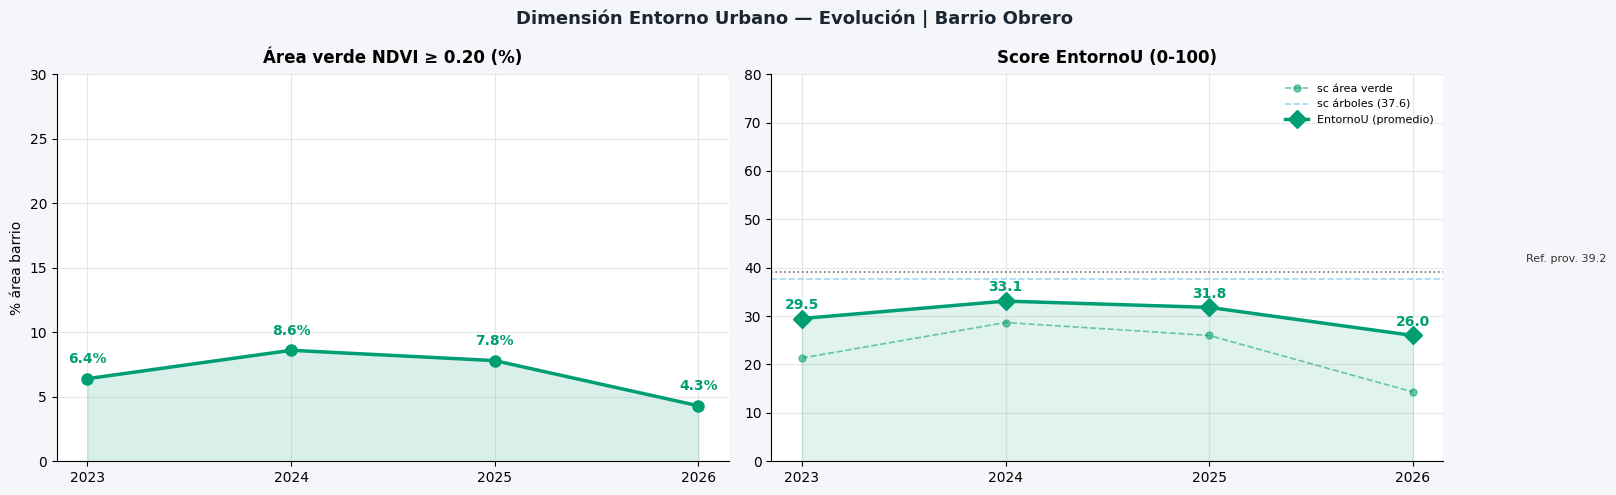

In [27]:
# ── Celda EU-4: evolución anual Entorno Urbano ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
fig.suptitle('Dimensión Entorno Urbano — Evolución | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_eu.set_index('año').reindex(ANIOS)
x    = list(range(len(ANIOS)))

# Panel 1: % área verde
ax = axes[0]; ax.set_facecolor('white')
vals = df_e['pct_verde'].values.astype(float)
ymax = max(30, float(np.nanmax(vals)) * 1.35) if not np.all(np.isnan(vals)) else 30
ax.plot(x, vals, color=OKI_VERDE, linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, vals, alpha=0.15, color=OKI_VERDE)
for xi, v in zip(x, vals):
    if not np.isnan(v):
        ax.text(xi, v + ymax * 0.04, f'{v:.1f}%',
                ha='center', fontsize=10, fontweight='bold', color=OKI_VERDE)
ax.set_xticks(x); ax.set_xticklabels(ANIOS)
ax.set_ylim(0, ymax); ax.set_ylabel('% área barrio')
ax.set_title('Área verde NDVI ≥ 0.20 (%)', fontweight='bold', pad=8)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Score con componentes
ax = axes[1]; ax.set_facecolor('white')
sc_eu  = df_e['score_entorno_u'].values.astype(float)
sc_v   = df_e['score_verde'].values.astype(float)
ax.plot(x, sc_v,
        color=OKI_VERDE,  linewidth=1.2, linestyle='--', marker='o',
        markersize=5, alpha=0.55, label='sc área verde', zorder=2)
ax.axhline(score_arboles_fijo, color=OKI_AZUL_C, linewidth=1.2,
           linestyle='--', alpha=0.55,
           label=f'sc árboles ({score_arboles_fijo})')
ax.plot(x, sc_eu, color=OKI_VERDE, linewidth=2.5, marker='D',
        markersize=9, label='EntornoU (promedio)', zorder=3)
ax.fill_between(x, sc_eu, alpha=0.12, color=OKI_VERDE)
for xi, v in zip(x, sc_eu):
    if not np.isnan(v):
        ax.text(xi, v + 2, f'{v:.1f}', ha='center', fontsize=10,
                fontweight='bold', color=OKI_VERDE)
ax.axhline(39.2, color=OKI_GRIS, linewidth=1.2, linestyle=':', alpha=0.7)
ax.text(len(x) - 0.05, 39.2 + 2, 'Ref. prov. 39.2',
        fontsize=8, color=OKI_GRIS, ha='right')
ax.set_xticks(x); ax.set_xticklabels(ANIOS)
ax.set_ylim(0, 80)
ax.set_title('Score EntornoU (0-100)', fontweight='bold', pad=8)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_obrero_entorno_evolucion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


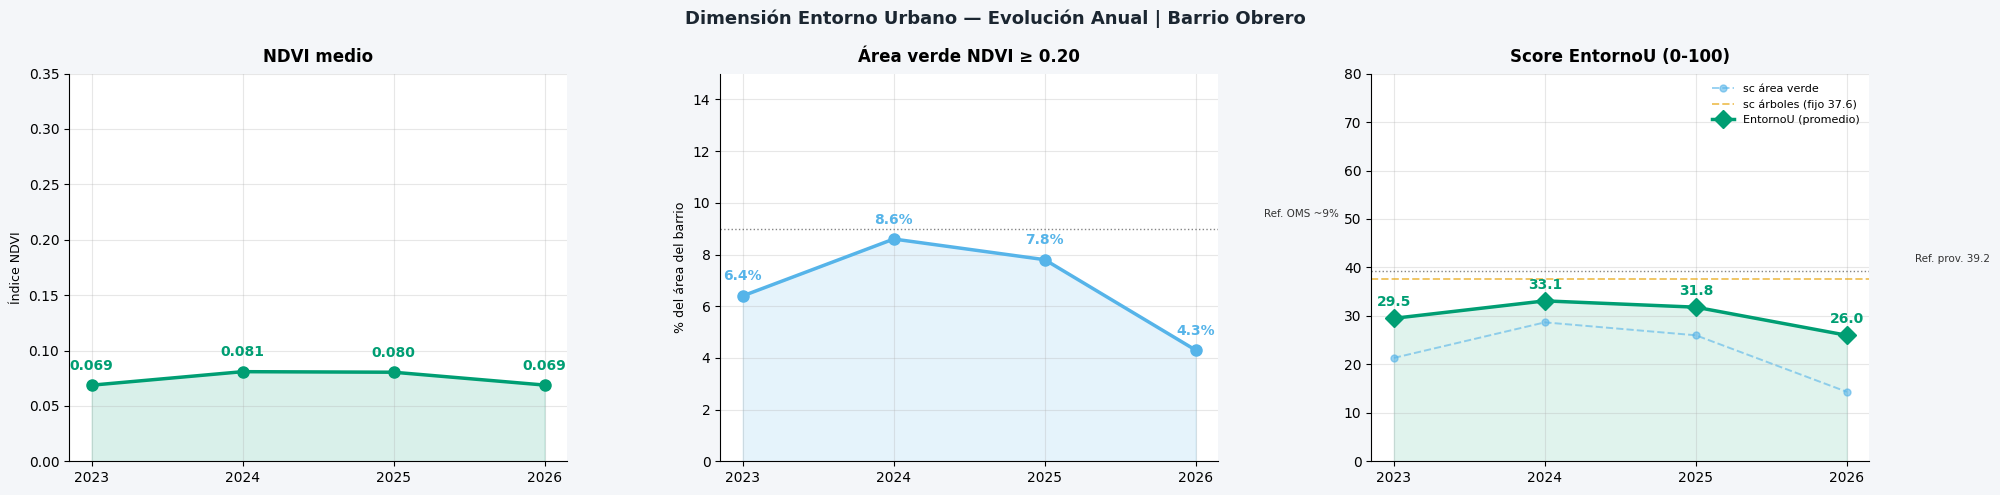

In [28]:
# ── Celda EU-4 (reemplazo): 3 indicadores Entorno Urbano en una sola figura ───
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimensión Entorno Urbano — Evolución Anual | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_eu.set_index('año').reindex(ANIOS)
x    = list(range(len(ANIOS)))

# ── Panel 1: NDVI medio ───────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('white')
vals = df_e['ndvi_mean'].values.astype(float)
ymax = max(0.35, float(np.nanmax(vals)) * 1.35) if not np.all(np.isnan(vals)) else 0.35
ax.plot(x, vals, color=OKI_VERDE, linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, vals, alpha=0.15, color=OKI_VERDE)
for xi, v in zip(x, vals):
    if not np.isnan(v):
        ax.text(xi, v + ymax * 0.04, f'{v:.3f}',
                ha='center', fontsize=10, fontweight='bold', color=OKI_VERDE)
ax.set_xticks(x); ax.set_xticklabels(ANIOS)
ax.set_ylim(0, ymax)
ax.set_ylabel('Índice NDVI', fontsize=9)
ax.set_title('NDVI medio', fontweight='bold', pad=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: % área verde ─────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('white')
vals = df_e['pct_verde'].values.astype(float)
ymax = max(15, float(np.nanmax(vals)) * 1.40) if not np.all(np.isnan(vals)) else 15
ax.plot(x, vals, color=OKI_AZUL_C, linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, vals, alpha=0.15, color=OKI_AZUL_C)
for xi, v in zip(x, vals):
    if not np.isnan(v):
        ax.text(xi, v + ymax * 0.04, f'{v:.1f}%',
                ha='center', fontsize=10, fontweight='bold', color=OKI_AZUL_C)
# Referencia OMS: 9 m²/hab → aprox 9% para zona densa (línea de contexto)
ax.axhline(9, color=OKI_GRIS, linewidth=1.0, linestyle=':', alpha=0.6)
ax.text(len(x) - 0.05, 9 + ymax * 0.03, 'Ref. OMS ~9%',
        fontsize=7.5, color=OKI_GRIS, ha='right')
ax.set_xticks(x); ax.set_xticklabels(ANIOS)
ax.set_ylim(0, ymax)
ax.set_ylabel('% del área del barrio', fontsize=9)
ax.set_title('Área verde NDVI ≥ 0.20', fontweight='bold', pad=8)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 3: Score EntornoU con componentes ───────────────────────────────────
ax = axes[2]; ax.set_facecolor('white')
sc_eu  = df_e['score_entorno_u'].values.astype(float)
sc_v   = df_e['score_verde'].values.astype(float)

ax.plot(x, sc_v,
        color=OKI_AZUL_C, linewidth=1.4, linestyle='--', marker='o',
        markersize=5, alpha=0.6, label='sc área verde', zorder=2)
ax.axhline(score_arboles_fijo, color=OKI_NARANJA, linewidth=1.4,
           linestyle='--', alpha=0.6,
           label=f'sc árboles (fijo {score_arboles_fijo})')
ax.plot(x, sc_eu, color=OKI_VERDE, linewidth=2.5, marker='D',
        markersize=9, label='EntornoU (promedio)', zorder=3)
ax.fill_between(x, sc_eu, alpha=0.12, color=OKI_VERDE)
for xi, v in zip(x, sc_eu):
    if not np.isnan(v):
        ax.text(xi, v + 2.5, f'{v:.1f}', ha='center', fontsize=10,
                fontweight='bold', color=OKI_VERDE)
ax.axhline(39.2, color=OKI_GRIS, linewidth=1.0, linestyle=':', alpha=0.6)
ax.text(len(x) - 0.05, 39.2 + 2, 'Ref. prov. 39.2',
        fontsize=7.5, color=OKI_GRIS, ha='right')
ax.set_xticks(x); ax.set_xticklabels(ANIOS)
ax.set_ylim(0, 80)
ax.set_title('Score EntornoU (0-100)', fontweight='bold', pad=8)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_obrero_entorno_evolucion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


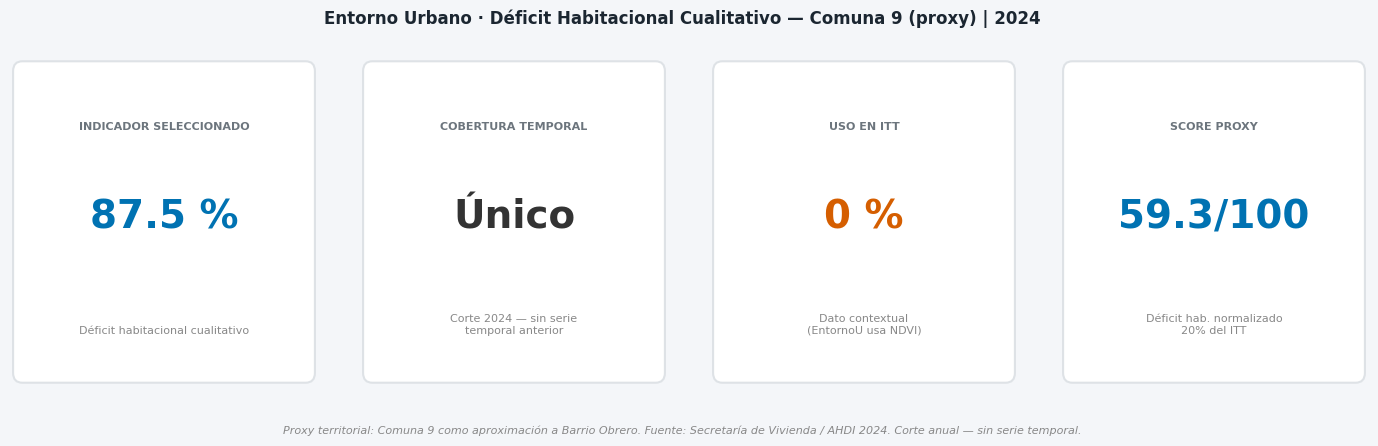

In [29]:
# ── Celda EU-3b: card Déficit Habitacional — formato dashboard ────────────────
fig = plt.figure(figsize=(14, 4), facecolor=BG)
fig.suptitle('Entorno Urbano · Déficit Habitacional Cualitativo — Comuna 9 (proxy) | 2024',
             fontsize=12, fontweight='bold', color='#1B2631', y=1.02)

posiciones = [
    [0.02, 0.08, 0.22, 0.82],
    [0.27, 0.08, 0.22, 0.82],
    [0.52, 0.08, 0.22, 0.82],
    [0.77, 0.08, 0.22, 0.82],
]

def card(ax, etiqueta_top, valor_str, etiqueta_bot, color_val):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    rect = mpatches.FancyBboxPatch(
        (0.04, 0.04), 0.92, 0.92,
        boxstyle='round,pad=0.03',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white'
    )
    ax.add_patch(rect)
    ax.text(0.5, 0.78, etiqueta_top, ha='center', fontsize=8,
            color='#6C757D', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.48, valor_str,    ha='center', fontsize=28,
            color=color_val, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.16, etiqueta_bot, ha='center', fontsize=8,
            color='#888888', transform=ax.transAxes)

axes_c = [fig.add_axes(p) for p in posiciones]

pct_val  = globals().get('deficit_pct', None)
sc_eu_val = globals().get('REF_ENTORNO_U', 39.2)

card(axes_c[0],
     'INDICADOR SELECCIONADO',
     f'{pct_val:.1f} %' if pct_val else 'N/D',
     'Déficit habitacional cualitativo',
     OKI_AZUL)

card(axes_c[1],
     'COBERTURA TEMPORAL',
     'Único',
     'Corte 2024 — sin serie\ntemporal anterior',
     OKI_GRIS)

card(axes_c[2],
     'USO EN ITT',
     '0 %',
     'Dato contextual\n(EntornoU usa NDVI)',
     OKI_BERMELL)

card(axes_c[3],
     'SCORE PROXY',
     f'{sc_eu_val:.1f}/100',
     f'Déficit hab. normalizado\n20% del ITT',
     OKI_AZUL)

fig.text(0.5, -0.04,
    'Proxy territorial: Comuna 9 como aproximación a Barrio Obrero. '
    'Fuente: Secretaría de Vivienda / AHDI 2024. Corte anual — sin serie temporal.',
    ha='center', fontsize=8, color='#888888', style='italic')

plt.savefig('itt_obrero_deficit_card.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda ED — Educación y Desarrollo

Calcula tasas anuales de **deserción** y **repitencia** para la **IE Republica de Argentina**
 (única IE oficial en Barrio Obrero, DANE `176001005368`).

- **Numerador deserción:** SIMPADE 2023-2025 — disponible en el repo (`data/referencia/educacion/SIMPADE/`).
- **Denominador matrícula:** SIMAT Anexo 6A Diciembre — descargado desde Drive en Colab (Celda ED-2).
- **Grados válidos:** 0-11 + Aceleración del Aprendizaje (excluye adultos, PFC, prejardín).
- **2026:** sin corte anual SIMAT/SIMPADE → mantiene `REF_EDUC_DES` provisional en `base`.

Los scores de deserción y repitencia reemplazan el referente provisional `REF_EDUC_DES = 54.9`
 en `base['score_educ_des']` y recalculan el ITT global.

In [30]:
# ── Celda ED-1: configuración + carga SIMPADE (local en repo) ───────────────
import os, subprocess, importlib.util
import pandas as pd
import numpy as np
from pathlib import Path

DANE_IE    = '176001005368'   # IE Republica de Argentina
AÑOS_EDUC  = [2023, 2024, 2025]

EDUC_DIR = REPO / 'data' / 'referencia' / 'educacion'
SIMPADE_FILES = {
    2023: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2023-11.xlsx', 'xlsx'),
    2024: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2024-11.xlsx', 'xlsx'),
    2025: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2025-11.csv',  'csv'),
}

# IDs de Google Drive — Anexo 6A diciembre (corte anual de matrícula)
SIMAT_DRIVE_IDS = {
    2023: '196frGLmnvMgXR_ZD--IqdRcaEGDrVoME',
    2024: '1DEkO7Das1dcEt7qE-gJKHGJE9S5b9rRj',
    2025: '18rLE8paAcWuoRziRCgjA5Yz5lJdv--cR',
}

GRADOS_EFIC  = list(range(0, 12)) + [99]   # 0-11 + aceleración
REF_DES_MIN, REF_DES_MAX = 0, 15           # tasa deserción %
REF_REP_MIN, REF_REP_MAX = 0, 20           # tasa repitencia %

# ── Cargar SIMPADE ────────────────────────────────────────────────────────
def cargar_simpade(año, path, fmt):
    try:
        if fmt == 'xlsx':
            df = pd.read_excel(path, dtype=str)
        else:
            df = pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str)
        df.columns = [c.strip() for c in df.columns]
        mask_ie  = df['DANE_EE'].str.strip() == DANE_IE
        mask_sec = df['SECTOR'].str.strip().str.upper() == 'OFICIAL'
        df_ie    = df[mask_ie & mask_sec]
        mask_adu = df_ie['GRADO'].astype(str).str.upper().str.contains('CICLO|ADULTO', na=False)
        return len(df_ie[~mask_adu])
    except Exception as e:
        print(f'  ERROR SIMPADE {año}: {e}')
        return np.nan

desertores_educ = {}
for año, (path, fmt) in SIMPADE_FILES.items():
    n = cargar_simpade(año, path, fmt)
    desertores_educ[año] = n
    print(f'SIMPADE {año}: {n} desertores  (IE Rep. Argentina, grados 0-11+acel, sector oficial)')

SIMPADE 2023: 194 desertores  (IE Rep. Argentina, grados 0-11+acel, sector oficial)
SIMPADE 2024: 89 desertores  (IE Rep. Argentina, grados 0-11+acel, sector oficial)
SIMPADE 2025: 102 desertores  (IE Rep. Argentina, grados 0-11+acel, sector oficial)


In [33]:
# ── Celda ED-2: descargar/cargar SIMAT Anexo 6A (Colab robusto) ─────────────
matricula_simat  = {}   # año → matrícula total IE grados eficiencia
repitentes_simat = {}   # año → n repitentes

def procesar_simat_6a(path_xlsx, año):
    df = pd.read_excel(path_xlsx, dtype=str)
    df.columns = [c.strip().upper().replace(' ', '_') for c in df.columns]

    col_dane = next((c for c in df.columns if 'CODIGO_DANE' in c and 'SEDE' not in c), None)
    if col_dane is None:
        print(f'  {año}: columna CODIGO_DANE no encontrada')
        return np.nan, np.nan

    if 'SECTOR' not in df.columns or 'GRADO' not in df.columns or 'REPITENTE' not in df.columns:
        print(f'  {año}: faltan columnas esperadas (SECTOR / GRADO / REPITENTE)')
        return np.nan, np.nan

    mask_ie  = df[col_dane].astype(str).str.strip() == DANE_IE
    mask_sec = df['SECTOR'].astype(str).str.strip().str.upper() == 'OFICIAL'

    df_ie = df[mask_ie & mask_sec].copy()
    df_ie['_G'] = pd.to_numeric(df_ie['GRADO'], errors='coerce')
    df_ef = df_ie[df_ie['_G'].isin(GRADOS_EFIC)]

    matricula  = len(df_ef)
    repitentes = int((df_ef['REPITENTE'].astype(str).str.strip().str.upper() == 'S').sum())
    return matricula, repitentes

if os.path.exists('/content'):
    if importlib.util.find_spec('gdown') is None:
        subprocess.run(['pip', 'install', 'gdown', '-q'], check=False)
    import gdown

    try:
        from google.colab import files
    except:
        files = None

    for año, fid in SIMAT_DRIVE_IDS.items():
        dest = Path(f'/content/simat_6a_dic_{año}.xlsx')

        # 1) Intentar descarga automática
        if not dest.exists():
            try:
                print(f'Descargando SIMAT 6A diciembre {año}...')
                url = f'https://drive.google.com/uc?id={fid}'
                gdown.download(url=url, output=str(dest), quiet=False, fuzzy=True)
            except Exception as e:
                print(f'  {año}: gdown falló -> {e}')
                print(f'  {año}: si abriste el enlace en el navegador, el archivo quedó en tu PC, no en /content.')

        # 2) Buscar si ya está en /content por una subida anterior
        if not dest.exists():
            candidatos = list(Path('/content').glob(f'*{año}*.xls*'))
            if len(candidatos) > 0:
                dest = candidatos[0]
                print(f'  {año}: usando archivo encontrado en /content -> {dest.name}')

        # 3) Subida manual si sigue faltando
        if not dest.exists() and files is not None:
            print(f'  {año}: sube manualmente el archivo SIMAT 6A de diciembre {año}')
            uploaded = files.upload()
            candidatos = [Path('/content') / k for k in uploaded.keys() if str(año) in k]
            if len(candidatos) > 0:
                dest = candidatos[0]
                print(f'  {año}: archivo subido -> {dest.name}')

        # 4) Procesar
        if Path(dest).exists():
            m, r = procesar_simat_6a(dest, año)
            matricula_simat[año]  = m
            repitentes_simat[año] = r
            print(f'  SIMAT 6A {año}: matricula={m}, repitentes={r}')
        else:
            print(f'  {año}: archivo no disponible en Colab — tasas quedarán como NaN')

else:
    print('No estamos en Colab — SIMAT 6A no disponible.')
    print('Las tasas requieren el archivo como denominador.')

print()
print('Resumen desertores / matricula / repitentes:')
for año in AÑOS_EDUC:
    m = matricula_simat.get(año, 'NaN')
    r = repitentes_simat.get(año, 'NaN')
    d = desertores_educ.get(año, 'NaN')
    print(f'  {año} — desertores(SIMPADE): {d}  |  matricula(SIMAT): {m}  |  repitentes(SIMAT): {r}')

  SIMAT 6A 2023: matricula=750, repitentes=109
Descargando SIMAT 6A diciembre 2024...


Downloading...
From: https://drive.google.com/uc?id=1DEkO7Das1dcEt7qE-gJKHGJE9S5b9rRj
To: /content/simat_6a_dic_2024.xlsx
100%|██████████| 40.3M/40.3M [00:00<00:00, 191MB/s]


  SIMAT 6A 2024: matricula=709, repitentes=80
Descargando SIMAT 6A diciembre 2025...


Downloading...
From: https://drive.google.com/uc?id=18rLE8paAcWuoRziRCgjA5Yz5lJdv--cR
To: /content/simat_6a_dic_2025.xlsx
100%|██████████| 41.1M/41.1M [00:00<00:00, 134MB/s] 


  SIMAT 6A 2025: matricula=762, repitentes=78

Resumen desertores / matricula / repitentes:
  2023 — desertores(SIMPADE): 194  |  matricula(SIMAT): 750  |  repitentes(SIMAT): 109
  2024 — desertores(SIMPADE): 89  |  matricula(SIMAT): 709  |  repitentes(SIMAT): 80
  2025 — desertores(SIMPADE): 102  |  matricula(SIMAT): 762  |  repitentes(SIMAT): 78


In [ ]:
# ── Celda ED-3: tasas → scores → actualizar base + recalcular ITT ───────────
rows_educ = []
for año in AÑOS_EDUC:
    m = matricula_simat.get(año, np.nan)
    r = repitentes_simat.get(año, np.nan)
    d = desertores_educ.get(año, np.nan)

    def _safe(v):
        try: return float(v)
        except: return np.nan

    m_f, r_f, d_f = _safe(m), _safe(r), _safe(d)

    tasa_des = round(d_f / m_f * 100, 2) if (not np.isnan(d_f) and not np.isnan(m_f) and m_f > 0) else np.nan
    tasa_rep = round(r_f / m_f * 100, 2) if (not np.isnan(r_f) and not np.isnan(m_f) and m_f > 0) else np.nan

    sc_des = score_ref(tasa_des, REF_DES_MIN, REF_DES_MAX, True) if not np.isnan(tasa_des) else np.nan
    sc_rep = score_ref(tasa_rep, REF_REP_MIN, REF_REP_MAX, True) if not np.isnan(tasa_rep) else np.nan

    sc_disp = [s for s in [sc_des, sc_rep] if not np.isnan(s)]
    # NaN si SIMAT no está cargado — no usar referencial para años con datos reales
    sc_educ = round(sum(sc_disp) / len(sc_disp), 1) if sc_disp else np.nan

    rows_educ.append(dict(
        año=año, matricula=m, desertores=d, repitentes=r,
        tasa_desercion=tasa_des, tasa_repitencia=tasa_rep,
        score_desercion=sc_des, score_repitencia=sc_rep,
        score_educ_des=sc_educ
    ))

df_educ = pd.DataFrame(rows_educ)

# ── Verificar disponibilidad SIMAT ───────────────────────────────────────
sin_simat = [r['año'] for _, r in df_educ.iterrows() if pd.isna(r['score_educ_des'])]
if sin_simat:
    print(f'⚠ SIMAT no disponible para {sin_simat} — ejecutar en Colab para scores reales.')
    print('  El ITT quedará NaN para esos años hasta cargar SIMAT.')
else:
    print('✓ SIMAT cargado — scores de educación calculados con datos reales.')
print()

print('── Educación y Desarrollo: tasas e indicadores ──────────────────────────')
cols_show = ['año','matricula','desertores','tasa_desercion','repitentes','tasa_repitencia','score_educ_des']
print(df_educ[cols_show].to_string(index=False))
print()

# ── Actualizar base con scores reales (2023-2025) ────────────────────────
for _, row in df_educ.iterrows():
    base.loc[base['año'] == int(row['año']), 'score_educ_des'] = row['score_educ_des']
# 2026 mantiene REF_EDUC_DES provisional (sin corte anual SIMAT/SIMPADE)

# ── Recalcular ITT (6 dimensiones) ──────────────────────────────────────
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des']  +
    PESOS['Cohesion']  * base['score_cohesion']  +
    PESOS['DesEco']    * base['score_des_eco']
)
base['nivel'] = base['ITT'].apply(clasificar)

print('ITT actualizado — EducDes real 2023-2025, provisional 2026:')
print(base[['año','score_educ_des','score_des_eco','ITT','nivel']].round(1).to_string(index=False))

✓ SIMAT cargado — scores de educación calculados con datos reales.

── Educación y Desarrollo: tasas e indicadores ──────────────────────────
 año  matricula  desertores  tasa_desercion  repitentes  tasa_repitencia  score_educ_des
2023        750         194           25.87         109            14.53            13.7
2024        709          89           12.55          80            11.28            30.0
2025        762         102           13.39          78            10.24            29.8

ITT actualizado — EducDes real 2023-2025, provisional 2026:
 año  score_educ_des  score_des_eco  ITT          nivel
2023            13.7           50.0 51.2  Consolidacion
2024            30.0           50.0 54.3  Consolidacion
2025            29.8           50.0 58.1  Consolidacion
2026            54.9           50.0 65.0 Transformacion


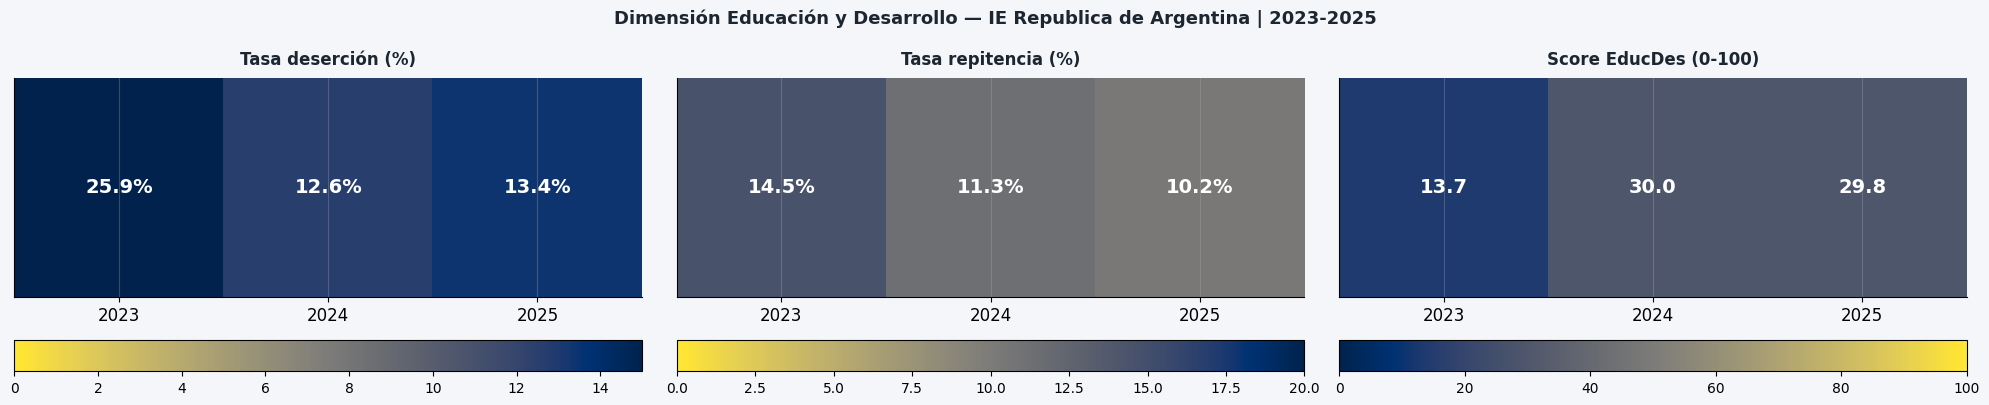

In [ ]:
# ── Celda ED-4: heatmap tasas + score EducDes ────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle(
    'Dimensión Educación y Desarrollo — IE Republica de Argentina | 2023-2025',
    fontsize=13, fontweight='bold', color='#1B2631'
)

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)

configs_hm = [
    ('tasa_desercion',  'Tasa deserción (%)',    'cividis_r', 0,   15, '%'),
    ('tasa_repitencia', 'Tasa repitencia (%)',   'cividis_r', 0,   20, '%'),
    ('score_educ_des',  'Score EducDes (0-100)', 'cividis',   0,  100, ''),
]
for ax, (col, titulo, cmap, vmin, vmax, sfx) in zip(axes, configs_hm):
    vals = df_e[col].values.astype(float).reshape(1, -1)
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(AÑOS_EDUC)))
    ax.set_xticklabels(AÑOS_EDUC, fontsize=12)
    ax.set_yticks([])
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    for j, v in enumerate(vals[0]):
        txt = f'{v:.1f}{sfx}' if not np.isnan(v) else 'S/D'
        ax.text(j, 0, txt, ha='center', va='center',
                fontsize=14, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.14)

plt.tight_layout()
plt.savefig('itt_obrero_educacion_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

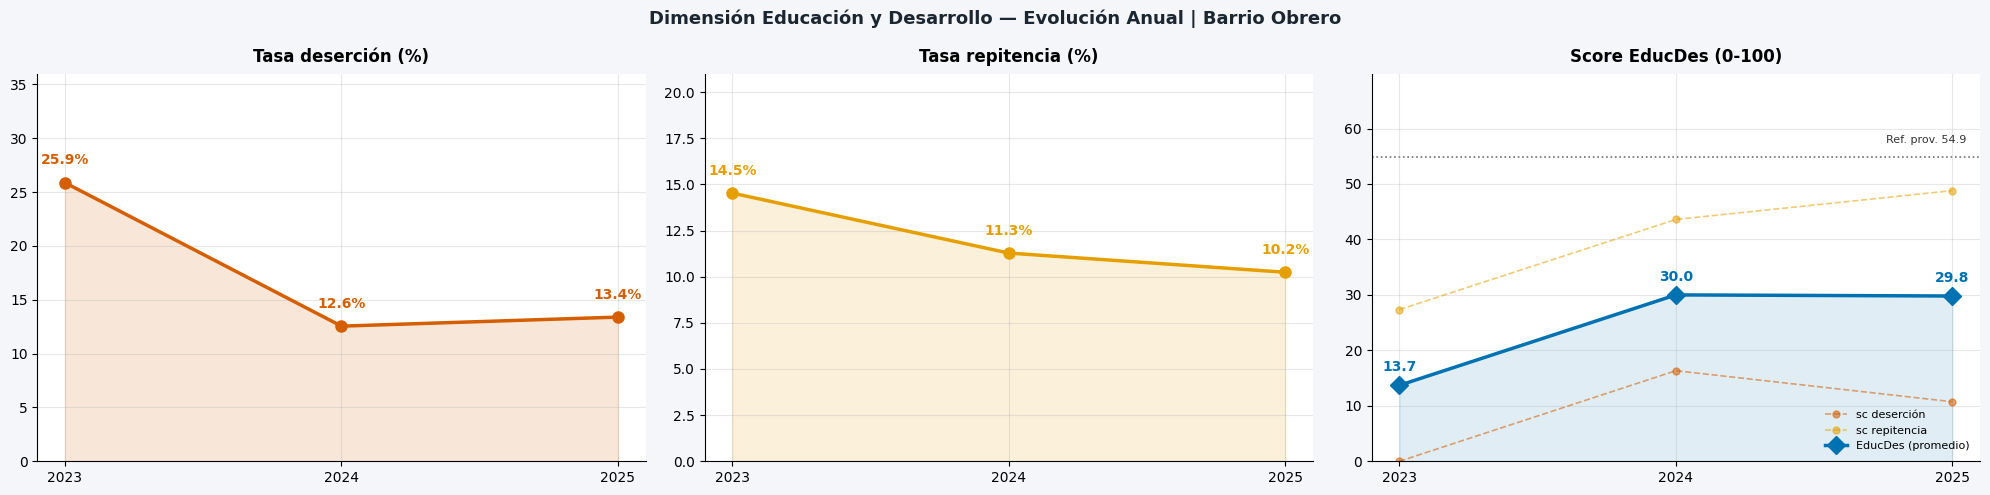

In [ ]:
# ── Celda ED-5: evolución anual línea + relleno ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle(
    'Dimensión Educación y Desarrollo — Evolución Anual | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631'
)

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)
x    = list(range(len(AÑOS_EDUC)))

cfg_lin = [
    ('tasa_desercion',  'Tasa deserción (%)',  OKI_BERMELL),
    ('tasa_repitencia', 'Tasa repitencia (%)', OKI_NARANJA),
]
for ax, (col, titulo, color) in zip(axes[:2], cfg_lin):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float)
    # ylim dinámico: máximo real + 25% de margen, mínimo 20
    vmax_data = np.nanmax(vals) if not np.all(np.isnan(vals)) else 20
    ymax = max(20, round(vmax_data * 1.3 + 2, 0))
    ax.plot(x, vals, color=color, linewidth=2.5, marker='o', markersize=8, zorder=3)
    ax.fill_between(x, vals, alpha=0.15, color=color)
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            # etiqueta siempre dentro del área: si el valor es muy alto, poner debajo
            offset = ymax * 0.04
            va_pos = 'bottom'
            if v + offset > ymax * 0.92:
                offset = -ymax * 0.06
                va_pos = 'top'
            ax.text(xi, v + offset, f'{v:.1f}%',
                    ha='center', va=va_pos, fontsize=10,
                    fontweight='bold', color=color)
    ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC)
    ax.set_ylim(0, ymax)
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

# Score EducDes — zoom centrado en el rango real + trazas individuales
ax = axes[2]
ax.set_facecolor('white')
sc_vals  = df_e['score_educ_des'].values.astype(float)
sc_des   = df_e['score_desercion'].values.astype(float)
sc_rep   = df_e['score_repitencia'].values.astype(float)

# Líneas de componentes en gris claro
ax.plot(x, sc_des, color=OKI_BERMELL, linewidth=1.2, linestyle='--',
        marker='o', markersize=5, alpha=0.55, label='sc deserción', zorder=2)
ax.plot(x, sc_rep, color=OKI_NARANJA, linewidth=1.2, linestyle='--',
        marker='o', markersize=5, alpha=0.55, label='sc repitencia', zorder=2)
# Línea principal EducDes
ax.plot(x, sc_vals, color=OKI_AZUL, linewidth=2.5, marker='D', markersize=9,
        label='EducDes (promedio)', zorder=3)
ax.fill_between(x, sc_vals, alpha=0.12, color=OKI_AZUL)

for xi, v in zip(x, sc_vals):
    if not np.isnan(v):
        ax.text(xi, v + 2.5, f'{v:.1f}', ha='center', fontsize=10,
                fontweight='bold', color=OKI_AZUL)

# Referencia provisional
ax.axhline(REF_EDUC_DES, color=OKI_GRIS, linewidth=1.2,
           linestyle=':', alpha=0.7, zorder=1)
ax.text(len(x) - 1 + 0.05, REF_EDUC_DES + 2.5,
        f'Ref. prov. {REF_EDUC_DES}', fontsize=8, color=OKI_GRIS, ha='right')

# ylim dinámico con mínimo visible de 0-60
all_sc = [v for v in list(sc_vals) + list(sc_des) + list(sc_rep) if not np.isnan(v)]
ymin_sc = max(0, min(all_sc) - 10) if all_sc else 0
ymax_sc = min(110, max(max(all_sc) + 12, REF_EDUC_DES + 15)) if all_sc else 110
ax.set_ylim(ymin_sc, ymax_sc)

ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC)
ax.set_title('Score EducDes (0-100)', fontweight='bold', pad=8)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_obrero_educacion_evolucion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


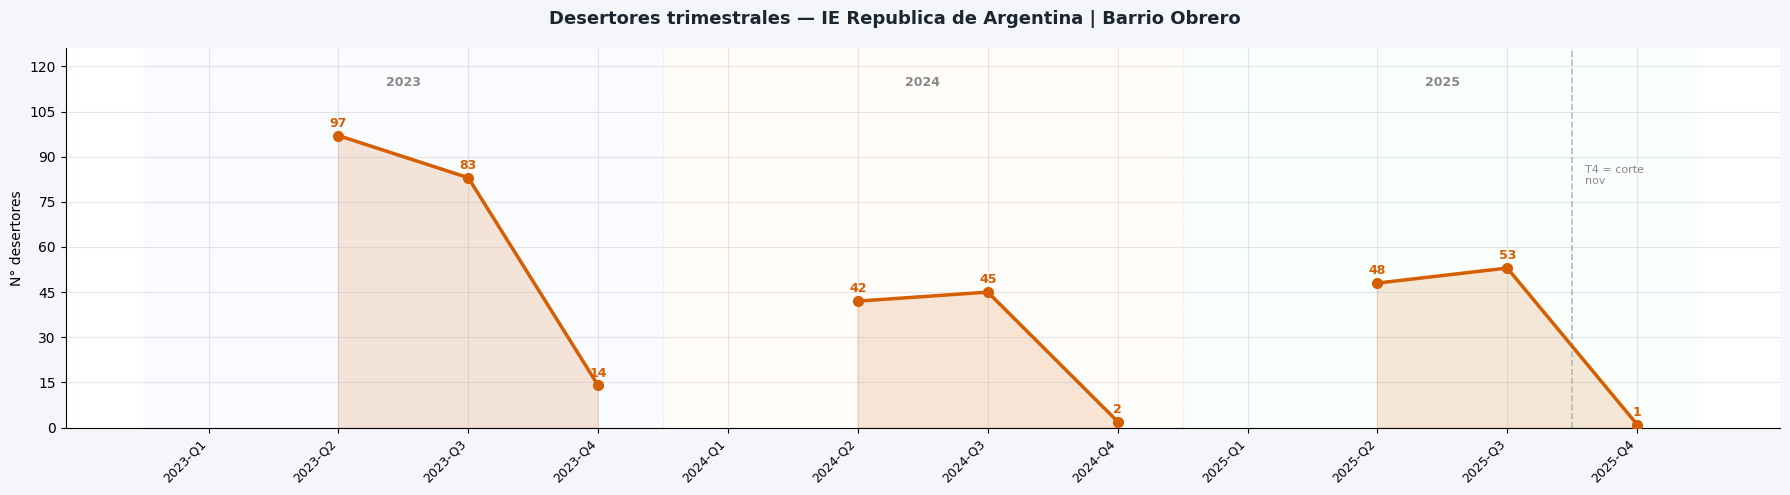

In [ ]:
# ── Desertores trimestrales — IE Republica de Argentina (independiente) ───────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

DANE_IE   = '176001005368'
EDUC_DIR  = REPO / 'data' / 'referencia' / 'educacion'
SIMPADE_FILES = {
    2023: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2023-11.xlsx', 'xlsx'),
    2024: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2024-11.xlsx', 'xlsx'),
    2025: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2025-11.csv',  'csv'),
}

def mes_a_trimestre(m):
    if m in [1,2,3]:   return 1
    if m in [4,5,6]:   return 2
    if m in [7,8,9]:   return 3
    if m in [10,11,12]: return 4
    return np.nan

# ── Cargar y agregar por trimestre ────────────────────────────────────────────
registros = []
for año, (path, fmt) in SIMPADE_FILES.items():
    try:
        df = pd.read_excel(path, dtype=str) if fmt == 'xlsx' \
             else pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str)
        df.columns = [c.strip() for c in df.columns]
        mask = (df['DANE_EE'].str.strip() == DANE_IE) & \
               (df['SECTOR'].str.strip().str.upper() == 'OFICIAL')
        df_ie = df[mask].copy()
        mask_adu = df_ie['GRADO'].astype(str).str.upper() \
                     .str.contains('CICLO|ADULTO', na=False)
        df_ie = df_ie[~mask_adu]
        df_ie['mes']  = pd.to_numeric(df_ie['MES_FINAL'], errors='coerce')
        df_ie['trim'] = df_ie['mes'].apply(mes_a_trimestre)
        df_ie['año']  = año
        registros.append(df_ie[['año','trim']].dropna())
    except Exception as e:
        print(f'{año}: no cargado — {e}')

df_simp = pd.concat(registros, ignore_index=True) if registros else pd.DataFrame()

# ── Construir serie 12 trimestres ─────────────────────────────────────────────
periodos_educ = []
for año in [2023, 2024, 2025]:
    for t in [1, 2, 3, 4]:
        n = df_simp[(df_simp['año']==año) & (df_simp['trim']==t)].shape[0] \
            if not df_simp.empty else 0
        periodos_educ.append({'periodo': f'{año}-Q{t}',
                               'año': año, 'trimestre': t,
                               'desertores': float(n) if n > 0 else np.nan})

df_ct  = pd.DataFrame(periodos_educ)
x      = list(range(len(df_ct)))
labels = df_ct['periodo'].tolist()
vals   = df_ct['desertores'].values.astype(float)
vmax   = float(np.nanmax(vals)) if not np.all(np.isnan(vals)) else 10

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5), facecolor=BG)
ax.set_facecolor('white')
fig.suptitle('Desertores trimestrales — IE Republica de Argentina | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

ax.plot(x, vals, color=OKI_BERMELL, linewidth=2.5,
        marker='o', markersize=7, zorder=3)
ax.fill_between(x, np.where(~np.isnan(vals), vals, np.nan),
                alpha=0.15, color=OKI_BERMELL)

for xi, v in zip(x, vals):
    if not np.isnan(v) and v > 0:
        ax.text(xi, v + vmax * 0.03, str(int(v)),
                ha='center', fontsize=9, fontweight='bold', color=OKI_BERMELL)

# Línea de corte nov (T4 parcial)
idx_corte = df_ct[df_ct['periodo'] == '2025-Q3'].index[0]
ax.axvline(x=idx_corte + 0.5, color='#AAAAAA', linewidth=1.2,
           linestyle='--', alpha=0.8)
ax.text(idx_corte + 0.6, vmax * 0.90, 'T4 = corte\nnov',
        fontsize=8, color='#888888', va='top')

# Separadores de año
for sep in ['2024-Q1', '2025-Q1']:
    xi_sep = df_ct[df_ct['periodo'] == sep].index[0]
    ax.axvline(x=xi_sep - 0.5, color='#DDDDDD', linewidth=1.0,
               linestyle=':', alpha=0.6)

# Fondo por año
for año, color_f in zip([2023,2024,2025], ['#F0F4FF','#FFF8F0','#F0FFF4']):
    ini = df_ct[df_ct['año']==año].index[0]
    fin = df_ct[df_ct['año']==año].index[-1]
    ax.axvspan(ini-0.5, fin+0.5, alpha=0.3, color=color_f, zorder=0)
    ax.text((ini+fin)/2, vmax*1.17, str(año),
            ha='center', fontsize=9, color='#888888', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('N° desertores', fontsize=10)
ax.set_ylim(0, vmax * 1.3)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('itt_obrero_educacion_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


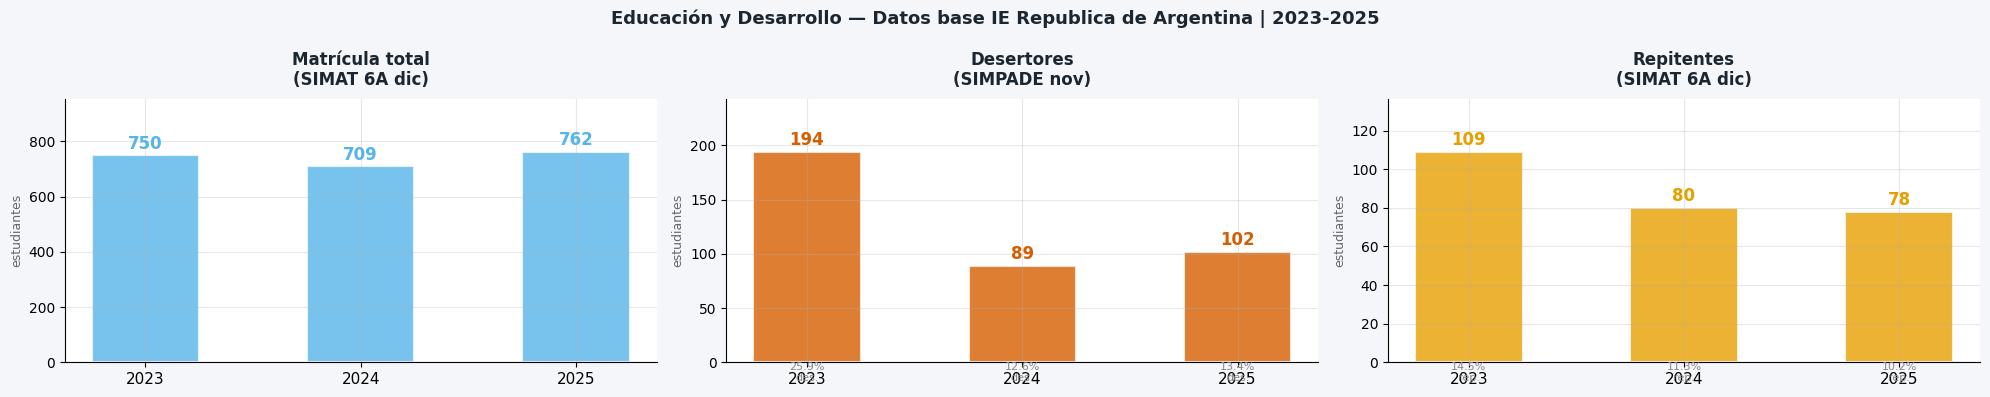

── Datos base: matrícula, desertores, repitentes, tasas ─────────────────
 año  matricula  desertores  tasa_desercion  repitentes  tasa_repitencia  score_educ_des
2023        750         194           25.87         109            14.53            13.7
2024        709          89           12.55          80            11.28            30.0
2025        762         102           13.39          78            10.24            29.8


In [ ]:
# ── Celda ED-3b: tabla visual — matrícula, desertores, repitentes ─────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle(
    'Educación y Desarrollo — Datos base IE Republica de Argentina | 2023-2025',
    fontsize=13, fontweight='bold', color='#1B2631'
)

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)

configs = [
    ('matricula',   'Matrícula total\n(SIMAT 6A dic)',     OKI_AZUL_C,  'estudiantes'),
    ('desertores',  'Desertores\n(SIMPADE nov)',            OKI_BERMELL, 'estudiantes'),
    ('repitentes',  'Repitentes\n(SIMAT 6A dic)',          OKI_NARANJA, 'estudiantes'),
]

x      = list(range(len(AÑOS_EDUC)))
ancho  = 0.5

for ax, (col, titulo, color, unidad) in zip(axes, configs):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float)

    bars = ax.bar(x, vals, color=color, alpha=0.80, width=ancho,
                  edgecolor='white', linewidth=1.5)

    # Etiqueta encima de cada barra
    vmax = np.nanmax(vals) if not np.all(np.isnan(vals)) else 1
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            ax.text(xi, v + vmax * 0.03, f'{int(v)}',
                    ha='center', fontsize=12, fontweight='bold', color=color)

    # Tasa derivada como subtítulo de cada barra
    if col == 'desertores':
        for xi, row in enumerate(df_educ.itertuples()):
            td = row.tasa_desercion
            if not np.isnan(td):
                ax.text(xi, -vmax * 0.09, f'{td:.1f}%\ndes.',
                        ha='center', fontsize=8, color='#888888', clip_on=False)
    elif col == 'repitentes':
        for xi, row in enumerate(df_educ.itertuples()):
            tr = row.tasa_repitencia
            if not np.isnan(tr):
                ax.text(xi, -vmax * 0.09, f'{tr:.1f}%\nrep.',
                        ha='center', fontsize=8, color='#888888', clip_on=False)

    ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC, fontsize=11)
    ax.set_ylim(0, vmax * 1.25)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel(unidad, fontsize=9, color='#666666')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_obrero_educacion_base.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── También imprimir tabla completa ──────────────────────────────────────────
print('── Datos base: matrícula, desertores, repitentes, tasas ─────────────────')
print(df_educ[['año','matricula','desertores','tasa_desercion',
               'repitentes','tasa_repitencia','score_educ_des']].to_string(index=False))


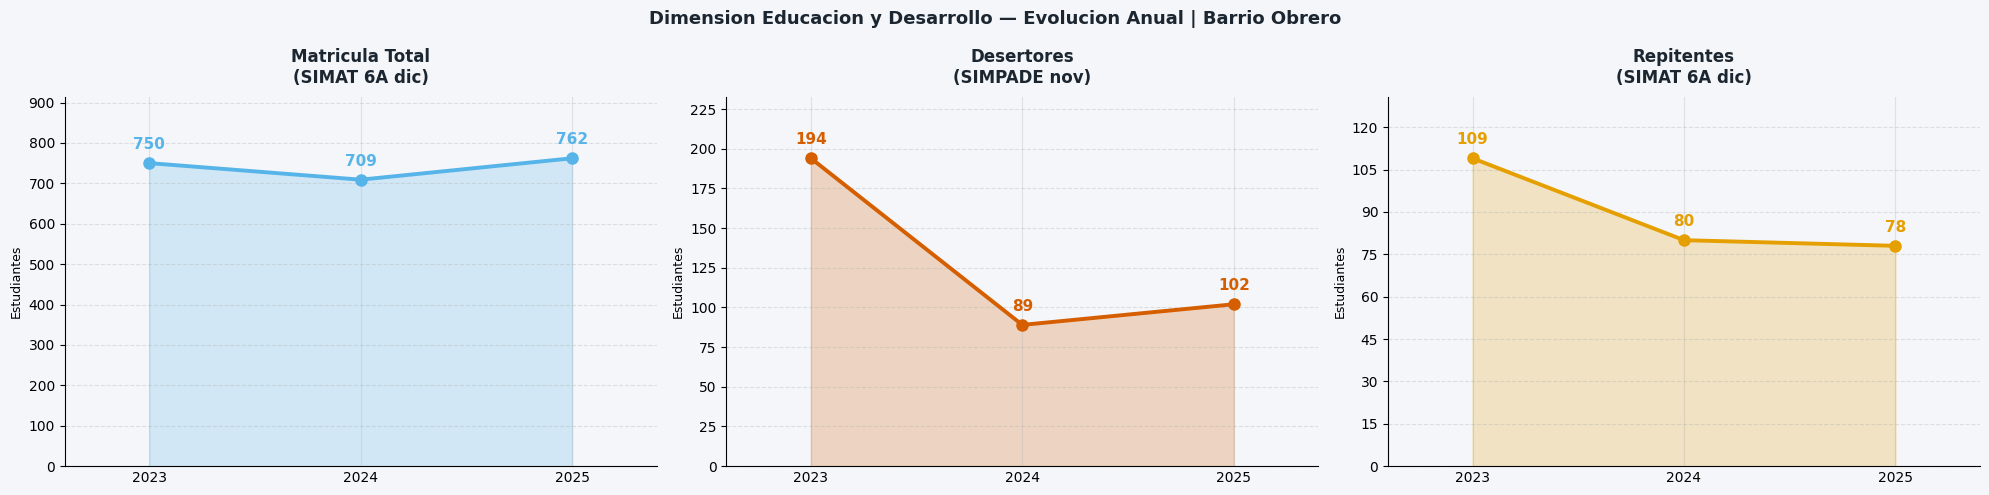

In [ ]:
# ── Celda ED-6: evolución anual Educación — línea + relleno ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimension Educacion y Desarrollo — Evolucion Anual | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

df_ep    = df_educ.set_index('año').reindex(AÑOS_EDUC)
anos_lbl = [str(a) for a in AÑOS_EDUC]
x_e      = np.arange(len(AÑOS_EDUC))

cfg_ed = [
    ('matricula',  'Matricula Total\n(SIMAT 6A dic)',   OKI_AZUL_C,  'estudiantes'),
    ('desertores', 'Desertores\n(SIMPADE nov)',          OKI_BERMELL, 'estudiantes'),
    ('repitentes', 'Repitentes\n(SIMAT 6A dic)',         OKI_NARANJA, 'estudiantes'),
]

for ax, (col, titulo, color, unidad) in zip(axes, cfg_ed):
    vals  = df_ep[col].values.astype(float)
    valid = ~np.isnan(vals)

    ax.fill_between(x_e, 0, np.where(valid, vals, np.nan),
                    alpha=0.22, color=color)
    ax.plot(x_e, np.where(valid, vals, np.nan),
            color=color, linewidth=2.8, marker='o', markersize=8, zorder=3)

    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.annotate(str(int(v)), (i, v),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(x_e)
    ax.set_xticklabels(anos_lbl, fontsize=10)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel(unidad.capitalize(), fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-0.4, len(AÑOS_EDUC) - 0.6)
    ax.set_ylim(0, np.nanmax(vals) * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_facecolor(BG)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('itt_obrero_educ_evol.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


── Desertores por trimestre (IE Rep. Argentina) ──────────────────────────
  Nota: corte noviembre — T4 cubre oct-nov (parcial).
año  2023  2024  2025
T1    NaN   NaN   NaN
T2   97.0  42.0  48.0
T3   83.0  45.0  53.0
T4   14.0   2.0   1.0



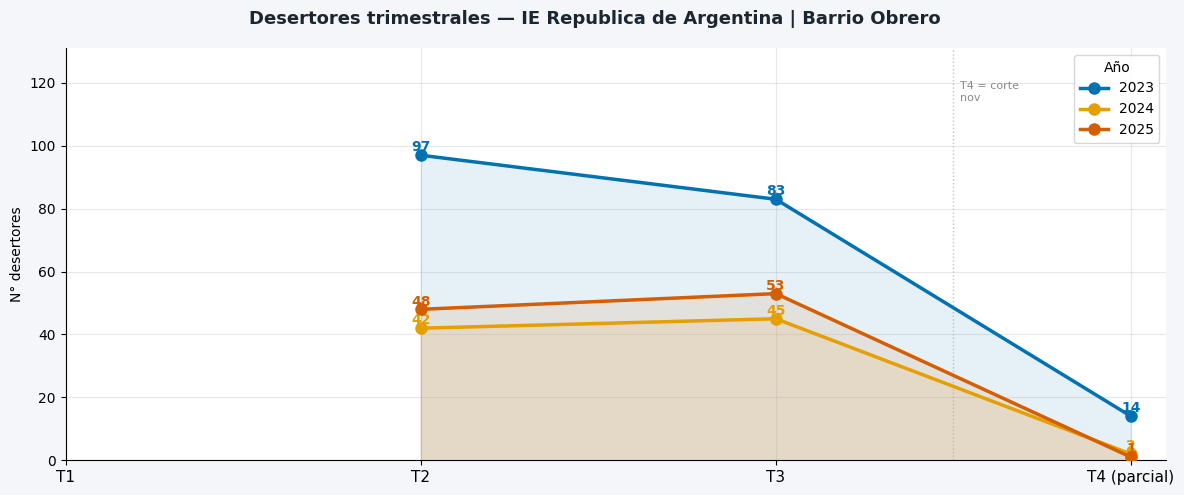

In [ ]:
# ── Celda ED-5b: evolución trimestral de desertores (SIMPADE) ─────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar SIMPADE con MES_FINAL
def cargar_simpade_trim(año, path, fmt):
    if fmt == 'xlsx':
        df = pd.read_excel(path, dtype=str)
    else:
        df = pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str)
    df.columns = [c.strip() for c in df.columns]
    mask_ie  = df['DANE_EE'].str.strip() == DANE_IE
    mask_sec = df['SECTOR'].str.strip().str.upper() == 'OFICIAL'
    df_ie    = df[mask_ie & mask_sec]
    mask_adu = df_ie['GRADO'].astype(str).str.upper().str.contains('CICLO|ADULTO', na=False)
    df_ie    = df_ie[~mask_adu].copy()
    df_ie['mes'] = pd.to_numeric(df_ie['MES_FINAL'], errors='coerce')
    df_ie['año'] = año
    return df_ie[['año', 'mes']].dropna()

frames = []
for año, (path, fmt) in SIMPADE_FILES.items():
    try:
        frames.append(cargar_simpade_trim(año, path, fmt))
    except Exception as e:
        print(f'  ERROR {año}: {e}')

df_trim_educ = pd.concat(frames, ignore_index=True)
df_trim_educ['trimestre'] = df_trim_educ['mes'].apply(
    lambda m: 1 if m <= 3 else (2 if m <= 6 else (3 if m <= 9 else 4))
)

# Tabla pivote: año × trimestre
pivot = (df_trim_educ.groupby(['año', 'trimestre'])
         .size().reset_index(name='desertores'))
tabla = pivot.pivot(index='trimestre', columns='año', values='desertores').reindex([1,2,3,4])
tabla.index = ['T1','T2','T3','T4']
print('── Desertores por trimestre (IE Rep. Argentina) ──────────────────────────')
print(f'  Nota: corte noviembre — T4 cubre oct-nov (parcial).')
print(tabla.to_string())
print()

# ── Gráfica línea + relleno ──────────────────────────────────────────────
COLS_TRIM = [OKI_AZUL, OKI_NARANJA, OKI_BERMELL]
AÑOS_EDUC_T = [2023, 2024, 2025]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor('white')
fig.suptitle(
    'Desertores trimestrales — IE Republica de Argentina | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631'
)

x = [0, 1, 2, 3]
xlabels = ['T1', 'T2', 'T3', 'T4 (parcial)']

for año, color in zip(AÑOS_EDUC_T, COLS_TRIM):
    if año not in tabla.columns:
        continue
    vals = tabla[año].values.astype(float)
    ax.plot(x, vals, color=color, linewidth=2.5, marker='o', markersize=8,
            label=str(año), zorder=3)
    ax.fill_between(x, vals, alpha=0.10, color=color)
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            ax.text(xi, v + 1.2, f'{int(v)}', ha='center', fontsize=10,
                    fontweight='bold', color=color)

ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=11)
ax.set_ylabel('N° desertores', fontsize=10)
ax.set_ylim(0, tabla.max().max() * 1.3 + 5)
ax.axvline(x=2.5, color='#AAAAAA', linewidth=1, linestyle=':', alpha=0.7)
ax.text(2.52, ax.get_ylim()[1] * 0.92, 'T4 = corte\nnov', fontsize=8,
        color='#888888', va='top')
ax.legend(title='Año', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_obrero_educacion_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [ ]:
# ── Celda ED-2026M: Educacion 2026 corte marzo (solo seguimiento, no entra al ITT anual) ──
import pandas as pd
import numpy as np
from pathlib import Path

SIMAT_2026_DRIVE_ID = '15SBQLZsxza9kPV5yAhMJJld5f_uSca_U'
SIMAT_2026_PATH = Path('/content/simat_6a_mar_2026.xlsx')

# Reutiliza la funcion procesar_simat_6a() ya definida en ED-1
if 'procesar_simat_6a' not in globals():
    raise RuntimeError("Primero ejecuta la celda ED-1 donde se define procesar_simat_6a().")

# Descargar solo en Colab si no existe
if os.path.exists('/content'):
    try:
        import gdown
        if not SIMAT_2026_PATH.exists():
            print('Descargando SIMAT marzo 2026 desde Drive...')
            gdown.download(id=SIMAT_2026_DRIVE_ID, output=str(SIMAT_2026_PATH), quiet=False)
    except Exception as e:
        print('No fue posible descargar SIMAT 2026:', e)

if not SIMAT_2026_PATH.exists():
    raise FileNotFoundError(f'No existe {SIMAT_2026_PATH}. Verifica descarga o ruta.')

mat_2026_mar, rep_2026_mar = procesar_simat_6a(SIMAT_2026_PATH, 2026)

# Referencia historica solo para contexto
hist_educ = []
for ano in [2023, 2024, 2025]:
    m = matricula_simat.get(ano, np.nan)
    r = repitentes_simat.get(ano, np.nan)
    d = desertores_educ.get(ano, np.nan)
    tasa_rep = (r / m * 100) if pd.notna(m) and pd.notna(r) and m > 0 else np.nan
    tasa_des = (d / m * 100) if pd.notna(m) and pd.notna(d) and m > 0 else np.nan
    hist_educ.append({
        'ano': ano,
        'matricula_anual': m,
        'repitentes_anual': r,
        'desertores_anual': d,
        'tasa_repitencia_anual': round(tasa_rep, 2) if pd.notna(tasa_rep) else np.nan,
        'tasa_desercion_anual': round(tasa_des, 2) if pd.notna(tasa_des) else np.nan,
    })

df_hist_educ = pd.DataFrame(hist_educ)

df_educ_2026_marzo = pd.DataFrame([{
    'ano': 2026,
    'corte': 'Marzo',
    'matricula_observada': mat_2026_mar,
    'repitentes_observados': rep_2026_mar,
    'desertores_observados': np.nan,
    'tasa_repitencia_observada': round(rep_2026_mar / mat_2026_mar * 100, 2) if mat_2026_mar and mat_2026_mar > 0 else np.nan,
    'tasa_desercion_observada': np.nan,
    'score_educ_des_anual_comparable': np.nan,
    'nota': 'Corte parcial marzo 2026. No comparable con cierre anual 2023-2025. No entra al ITT anual.'
}])

print('Historico anual comparable 2023-2025:')
display(df_hist_educ)

print('\nEducacion 2026 corte marzo (salida complementaria):')
display(df_educ_2026_marzo)


Descargando SIMAT marzo 2026 desde Drive...


Downloading...
From: https://drive.google.com/uc?id=15SBQLZsxza9kPV5yAhMJJld5f_uSca_U
To: /content/simat_6a_mar_2026.xlsx
100%|██████████| 40.3M/40.3M [00:00<00:00, 115MB/s] 


Historico anual comparable 2023-2025:


,ano,matricula_anual,repitentes_anual,desertores_anual,tasa_repitencia_anual,tasa_desercion_anual
0,2023,750,109,194,14.53,25.87
1,2024,709,80,89,11.28,12.55
2,2025,762,78,102,10.24,13.39



Educacion 2026 corte marzo (salida complementaria):


,ano,corte,matricula_observada,repitentes_observados,desertores_observados,tasa_repitencia_observada,tasa_desercion_observada,score_educ_des_anual_comparable,nota
0,2026,Marzo,867,104,NaN,12.0,NaN,NaN,Corte parcial marzo 2026. No comparable con ci...


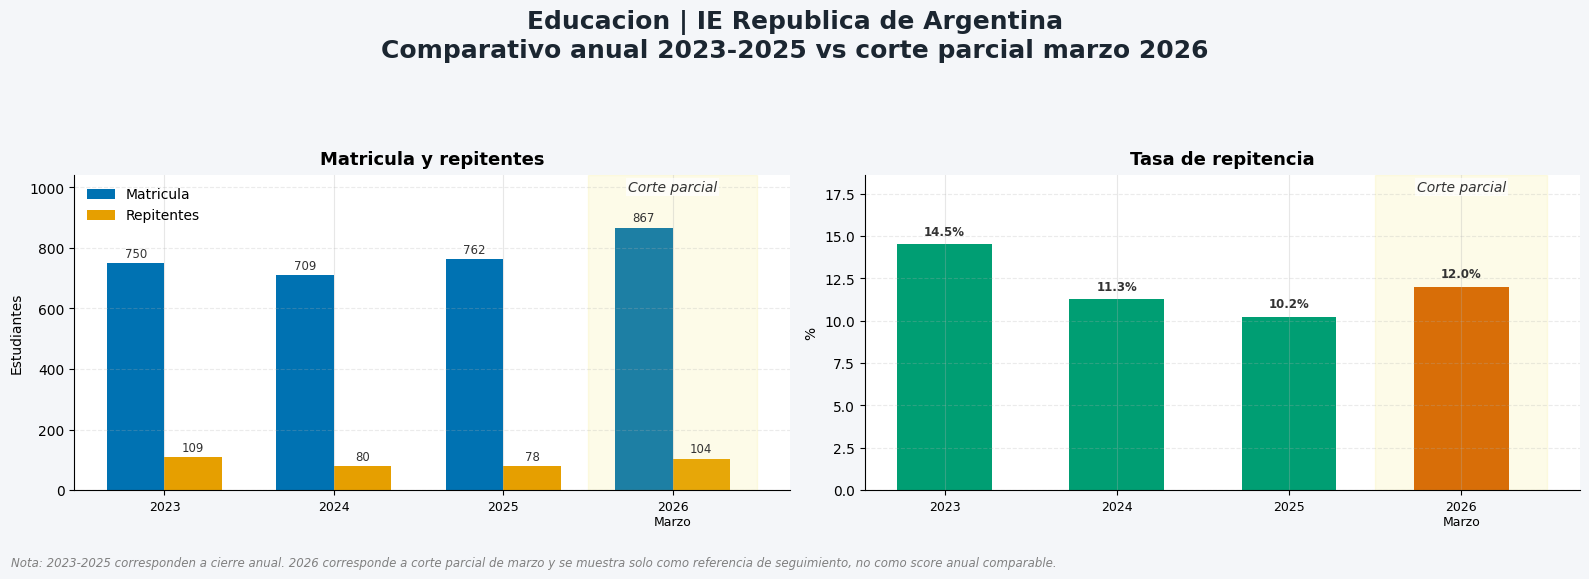

In [ ]:
# ── Celda ED-2026V: Comparativo visual Educacion 2023-2025 vs 2026 marzo ──
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if 'df_hist_educ' not in globals() or 'df_educ_2026_marzo' not in globals():
    raise RuntimeError("Primero ejecuta la celda ED-2026M para crear df_hist_educ y df_educ_2026_marzo.")

# Paleta Okabe-Ito
OKI_AZUL     = "#0072B2"
OKI_NARANJA  = "#E69F00"
OKI_VERDE    = "#009E73"
OKI_AMARILLO = "#F0E442"
OKI_BERMELL  = "#D55E00"
OKI_GRIS     = "#333333"
BG           = "#F4F6F9"

df_plot = df_hist_educ.copy()
df_plot["label"] = df_plot["ano"].astype(str)

row_2026 = df_educ_2026_marzo.iloc[0]
df_plot_2026 = pd.DataFrame([{
    "label": "2026\nMarzo",
    "matricula_anual": row_2026["matricula_observada"],
    "repitentes_anual": row_2026["repitentes_observados"],
    "tasa_repitencia_anual": row_2026["tasa_repitencia_observada"],
}])

df_all = pd.concat([
    df_plot[["label", "matricula_anual", "repitentes_anual", "tasa_repitencia_anual"]],
    df_plot_2026
], ignore_index=True)

x = np.arange(len(df_all))
w = 0.34

titulo_general = (
    "Educacion | IE Republica de Argentina\n"
    "Comparativo anual 2023-2025 vs corte parcial marzo 2026"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), facecolor=BG)
fig.suptitle(
    titulo_general,
    fontsize=18, fontweight="bold", color="#1B2631", y=0.98
)

# ── Panel 1 ────────────────────────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - w/2, df_all["matricula_anual"], width=w, color=OKI_AZUL, label="Matricula")
bars2 = ax.bar(x + w/2, df_all["repitentes_anual"], width=w, color=OKI_NARANJA, label="Repitentes")

ymax1 = float(df_all["matricula_anual"].fillna(0).max()) * 1.20
ax.set_ylim(0, ymax1)

# Banda 2026
ax.axvspan(len(df_all)-1 - 0.5, len(df_all)-1 + 0.5, color=OKI_AMARILLO, alpha=0.12)

# Etiqueta arriba de la banda, no sobre la barra
ax.text(
    len(df_all)-1,
    ymax1 * 0.985,
    "Corte parcial",
    ha="center", va="top",
    fontsize=10, color=OKI_GRIS, style="italic",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
)

for b in list(bars1) + list(bars2):
    h = b.get_height()
    if pd.notna(h):
        ax.text(
            b.get_x() + b.get_width()/2,
            h + ymax1 * 0.01,
            f"{int(h)}",
            ha="center", va="bottom",
            fontsize=8.5, color=OKI_GRIS
        )

ax.set_title("Matricula y repitentes", fontweight="bold", pad=8, fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_all["label"], fontsize=9)
ax.set_ylabel("Estudiantes")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

# ── Panel 2 ────────────────────────────────────────────────────────────────
ax2 = axes[1]
colors = [OKI_VERDE, OKI_VERDE, OKI_VERDE, OKI_BERMELL]
bars3 = ax2.bar(x, df_all["tasa_repitencia_anual"], color=colors, width=0.55)

ymax2 = float(df_all["tasa_repitencia_anual"].fillna(0).max()) * 1.28
ax2.set_ylim(0, ymax2)

ax2.axvspan(len(df_all)-1 - 0.5, len(df_all)-1 + 0.5, color=OKI_AMARILLO, alpha=0.12)

ax2.text(
    len(df_all)-1,
    ymax2 * 0.985,
    "Corte parcial",
    ha="center", va="top",
    fontsize=10, color=OKI_GRIS, style="italic",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
)

for b in bars3:
    h = b.get_height()
    if pd.notna(h):
        ax2.text(
            b.get_x() + b.get_width()/2,
            h + ymax2 * 0.02,
            f"{h:.1f}%",
            ha="center", va="bottom",
            fontsize=8.5, color=OKI_GRIS, fontweight="bold"
        )

ax2.set_title("Tasa de repitencia", fontweight="bold", pad=8, fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(df_all["label"], fontsize=9)
ax2.set_ylabel("%")
ax2.grid(axis="y", linestyle="--", alpha=0.25)

fig.text(
    0.01, 0.02,
    "Nota: 2023-2025 corresponden a cierre anual. 2026 corresponde a corte parcial de marzo y se muestra solo como referencia de seguimiento, no como score anual comparable.",
    fontsize=8.5, color="gray", style="italic"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.88])
plt.show()



## 6. Dimensión Desarrollo Económico — Peso: 15%

Indicadores: **Creación de negocios nuevos** · **Empleabilidad formal** · **Ingresos reportados**

Fuente: Registro Mercantil 2025 — 123 negocios georreferenciados en el polígono (94.1% micro).
La periodicidad se construye desde la **fecha de matrícula** del negocio (2023-2025).
Ingresos y personal son valores reportados por los negocios creados en cada año,
no ingresos o empleos generados estrictamente en ese periodo.

**Refs calibrados con serie histórica 2023-2025:**
`negocios_nuevos: [0–15]` · `personal: [0–20]` · `ingresos log1p: [0–20.4]`


In [25]:
# ── Celda DE-1: configuración + carga Registro Mercantil ─────────────────────
import re
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

ANIOS_DE = [2023, 2024, 2025]

PATH_DE = Path('data/itt_barrio_obrero/4_Desarrollo_Economico/registro_mercantil_2025_con_coordenadas_filtrado_poligono_Barrio_Obrero.geojson')
if not PATH_DE.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {PATH_DE}')

df_de = gpd.read_file(PATH_DE)

meses_es = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
    'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

def parse_fecha_es(txt):
    if pd.isna(txt):
        return pd.NaT
    s = str(txt).strip().lower()
    m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
    if not m:
        return pd.NaT
    dia = int(m.group(1))
    mes_txt = (m.group(2)
               .replace('á', 'a').replace('é', 'e')
               .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
    mes = meses_es.get(mes_txt)
    ano = int(m.group(3))
    return pd.Timestamp(year=ano, month=mes, day=dia) if mes else pd.NaT

df_de['fecha_mat'] = df_de['Mes_Dia_An'].apply(parse_fecha_es)
df_de['anio_mat'] = df_de['fecha_mat'].dt.year
df_de['trim_mat'] = df_de['fecha_mat'].dt.quarter

df_de['ingresos_limpio'] = pd.to_numeric(df_de['INGRESOS_A'], errors='coerce')
df_de.loc[df_de['ingresos_limpio'] <= 0, 'ingresos_limpio'] = np.nan

df_de['personal_limpio'] = pd.to_numeric(df_de['PERSONAL_O'], errors='coerce')
df_de.loc[df_de['personal_limpio'] < 0, 'personal_limpio'] = np.nan
df_de['personal_limpio'] = df_de['personal_limpio'].fillna(0)

print(f"Registro Mercantil cargado: {len(df_de):,} registros")
print(f"Ingresos positivos total stock: ${df_de['ingresos_limpio'].sum(skipna=True):,.0f}")
print(f"Personal total stock 2025: {df_de['personal_limpio'].sum():,.0f}")
print()
print(df_de[['Mes_Dia_An', 'fecha_mat', 'anio_mat', 'trim_mat', 'PERSONAL_O', 'INGRESOS_A']].head())

FileNotFoundError: No se encontro el archivo: data/itt_barrio_obrero/4_Desarrollo_Economico/registro_mercantil_2025_con_coordenadas_filtrado_poligono_Barrio_Obrero.geojson

In [26]:
# ── Celda DE-2: indicadores trimestrales y anuales 2023-2025 ─────────────────
REF_NEG_MIN,  REF_NEG_MAX  = 0, 15
REF_PERS_MIN, REF_PERS_MAX = 0, 20
REF_ING_MIN,  REF_ING_MAX  = 0, 20.4   # log1p(ingresos_nuevos)

rows_de_trim = []
for ano in ANIOS_DE:
    for trim in [1, 2, 3, 4]:
        sub = df_de[(df_de['anio_mat'] == ano) & (df_de['trim_mat'] == trim)].copy()
        rows_de_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_nuevos': float(len(sub)),
            'personal_nuevos': float(sub['personal_limpio'].sum()),
            'ingresos_nuevos': float(sub['ingresos_limpio'].sum(skipna=True))
        })

df_de_trim = pd.DataFrame(rows_de_trim)

rows_de_anual = []
for ano in ANIOS_DE:
    sub = df_de[df_de['anio_mat'] == ano].copy()
    rows_de_anual.append({
        'año': ano,
        'negocios_nuevos': float(len(sub)),
        'personal_nuevos': float(sub['personal_limpio'].sum()),
        'ingresos_nuevos': float(sub['ingresos_limpio'].sum(skipna=True))
    })

df_de_anual = pd.DataFrame(rows_de_anual)

print("Indicadores anuales:")
print(df_de_anual.round(2).to_string(index=False))
print()
print("Indicadores trimestrales:")
print(df_de_trim.round(2).to_string(index=False))

Indicadores anuales:
 año  negocios_nuevos  personal_nuevos  ingresos_nuevos
2023              5.0             18.0      640287000.0
2024             11.0              4.0      130355438.0
2025             10.0              8.0        2000000.0

Indicadores trimestrales:
periodo  año  trimestre  negocios_nuevos  personal_nuevos  ingresos_nuevos
2023-Q1 2023          1              1.0              0.0              0.0
2023-Q2 2023          2              0.0              0.0              0.0
2023-Q3 2023          3              2.0              9.0      554791000.0
2023-Q4 2023          4              2.0              9.0       85496000.0
2024-Q1 2024          1              3.0              1.0              0.0
2024-Q2 2024          2              5.0              2.0       61800000.0
2024-Q3 2024          3              2.0              1.0       68555438.0
2024-Q4 2024          4              1.0              0.0              0.0
2025-Q1 2025          1              3.0             

In [27]:
# ── Celda DE-3: scores → actualizar base + recalcular ITT ────────────────────
rows_de_sc = []

for ano in ANIOS:
    if ano in ANIOS_DE:
        sub = df_de[df_de['anio_mat'] == ano].copy()
        neg = float(len(sub))
        pers = float(sub['personal_limpio'].sum())
        ing = float(sub['ingresos_limpio'].sum(skipna=True))
        ing_log = float(np.log1p(ing)) if pd.notna(ing) and ing > 0 else 0.0
    else:
        neg = pers = ing = ing_log = np.nan

    sc_neg  = score_ref(neg,     REF_NEG_MIN,  REF_NEG_MAX,  False) if not pd.isna(neg)  else np.nan
    sc_pers = score_ref(pers,    REF_PERS_MIN, REF_PERS_MAX, False) if not pd.isna(pers) else np.nan
    sc_ing  = score_ref(ing_log, REF_ING_MIN,  REF_ING_MAX,  False) if not pd.isna(ing)  else np.nan

    vals = [x for x in [sc_neg, sc_pers, sc_ing] if not pd.isna(x)]
    sc_de = float(np.mean(vals)) if len(vals) > 0 else np.nan

    rows_de_sc.append({
        'año': ano,
        'negocios_nuevos': neg,
        'personal_nuevos': pers,
        'ingresos_nuevos': ing,
        'score_negocios': sc_neg,
        'score_personal': sc_pers,
        'score_ingresos': sc_ing,
        'score_des_eco': sc_de,
    })

df_de_scores = pd.DataFrame(rows_de_sc)

for _, r in df_de_scores.iterrows():
    if not pd.isna(r['score_des_eco']):
        base.loc[base['año'] == int(r['año']), 'score_des_eco'] = r['score_des_eco']

_sc_de_last = df_de_scores[df_de_scores['año'].isin(ANIOS_DE)].dropna(subset=['score_des_eco'])
if len(_sc_de_last) > 0:
    _sc_2025 = float(_sc_de_last.iloc[-1]['score_des_eco'])
    base.loc[base['año'] == 2026, 'score_des_eco'] = _sc_2025

base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des'] +
    PESOS['Cohesion']  * base['score_cohesion'] +
    PESOS['DesEco']    * base['score_des_eco']
)
base['nivel'] = base['ITT'].apply(clasificar)

print("Scores Desarrollo Economico por año:")
cols_sc = [
    'año', 'negocios_nuevos', 'personal_nuevos', 'ingresos_nuevos',
    'score_negocios', 'score_personal', 'score_ingresos', 'score_des_eco'
]
print(df_de_scores[cols_sc].round(1).to_string(index=False))
print()
print("ITT actualizado — 6 dimensiones:")
cols_b = [
    'año', 'score_seguridad', 'score_movilidad', 'score_cohesion',
    'score_entorno_u', 'score_educ_des', 'score_des_eco', 'ITT', 'nivel'
]
print(base[cols_b].round(1).to_string(index=False))

Scores Desarrollo Economico por año:
 año  negocios_nuevos  personal_nuevos  ingresos_nuevos  score_negocios  score_personal  score_ingresos  score_des_eco
2023              5.0             18.0      640287000.0            33.3            90.0            99.4           74.2
2024             11.0              4.0      130355438.0            73.3            20.0            91.6           61.6
2025             10.0              8.0        2000000.0            66.7            40.0            71.1           59.3
2026              NaN              NaN              NaN             NaN             NaN             NaN            NaN

ITT actualizado — 6 dimensiones:
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  score_des_eco  ITT          nivel
2023             79.0             57.1            37.6             39.2            54.9           74.2 60.6 Transformacion
2024             43.0             86.8            82.9             39.2            54.9 

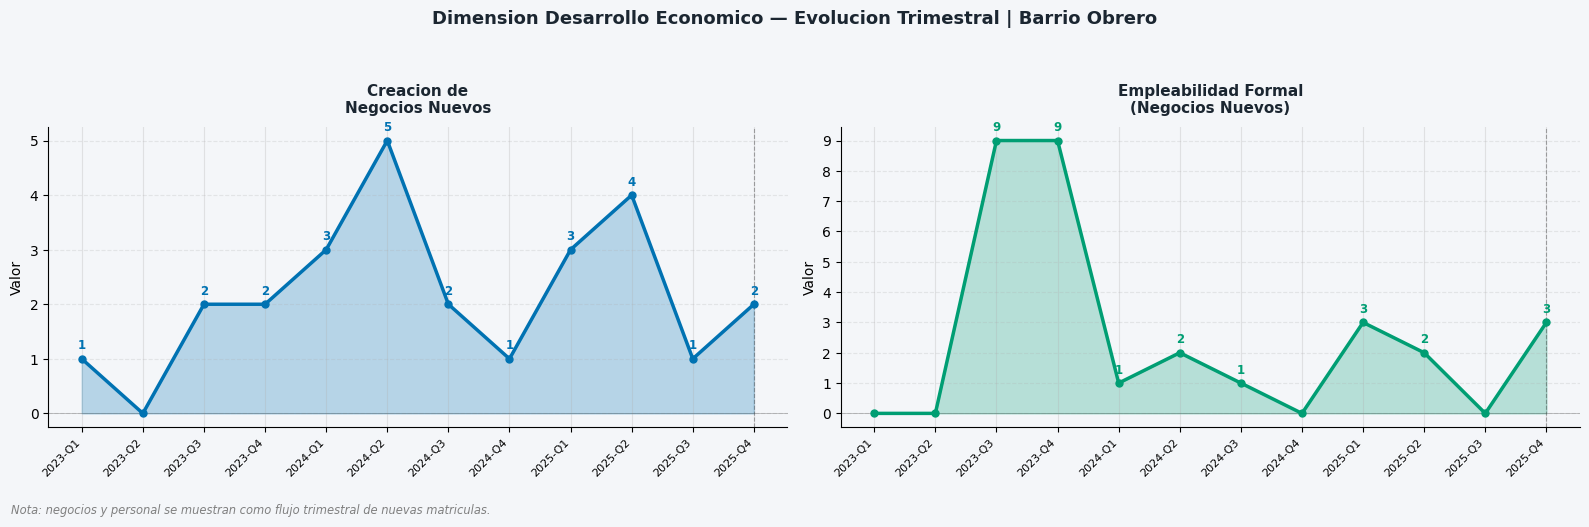

In [28]:
# ── Celda DE-4: evolucion trimestral principal | negocios + personal ─────────
_de_trim = df_de_trim.copy().sort_values(['año', 'trimestre']).reset_index(drop=True)
_periodos = _de_trim['periodo'].tolist()
_x = np.arange(len(_periodos))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), facecolor=BG)
fig.suptitle(
    'Dimension Desarrollo Economico — Evolucion Trimestral | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631'
)

cfg_de = [
    (axes[0], 'negocios_nuevos', 'Creacion de\nNegocios Nuevos', OKI_AZUL, lambda v: f'{int(v)}'),
    (axes[1], 'personal_nuevos', 'Empleabilidad Formal\n(Negocios Nuevos)', OKI_VERDE, lambda v: f'{int(v)}'),
]

for ax, col, titulo, color, fmt_fn in cfg_de:
    vals = _de_trim[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.5, marker='o', markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(
                fmt_fn(v), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8.5, fontweight='bold', color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=11, pad=10, fontweight='bold', color='#1B2631')
    ax.set_ylabel('Valor')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: negocios y personal se muestran como flujo trimestral de nuevas matriculas.',
    fontsize=8.3, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_obrero_de_trim_principal.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


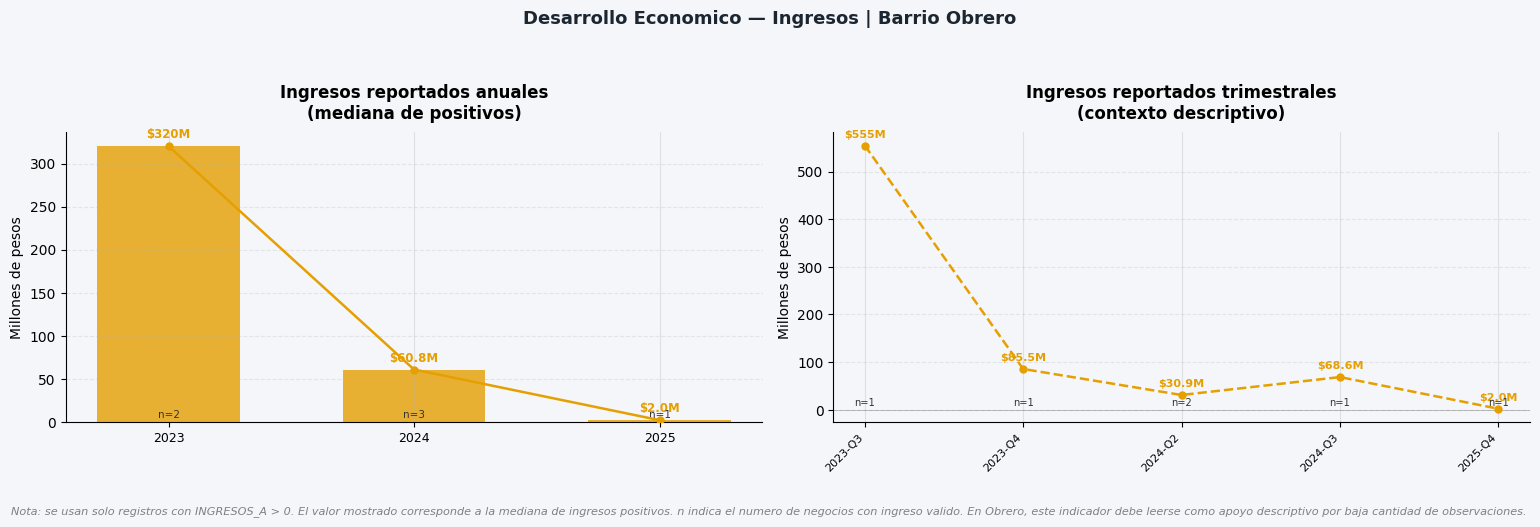

Resumen anual:


,año,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023,2,320143500.0,320.1435
1,2024,3,60800000.0,60.8000
2,2025,1,2000000.0,2.0000


Resumen trimestral con dato positivo:


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023-Q3,1,554791000.0,554.791000
1,2023-Q4,1,85496000.0,85.496000
2,2024-Q2,2,30900000.0,30.900000
3,2024-Q3,1,68555438.0,68.555438
4,2025-Q4,1,2000000.0,2.000000


In [29]:
# ── Celda DE-5: Ingresos | visual contextual honesto | Barrio Obrero ─────────
# Enfoque:
# - Ingresos calculados solo con INGRESOS_A > 0
# - Resumen con mediana de positivos
# - Anual como panel principal
# - Trimestral como panel secundario/contextual
# - n visible en cada punto

_df = df_de.copy()

_df['ingresos_pos'] = pd.to_numeric(_df['INGRESOS_A'], errors='coerce')
_df.loc[_df['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

rows_anual = []
for ano in ANIOS_DE:
    sub = _df[_df['anio_mat'] == ano].copy()
    med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
    n_pos = int(sub['ingresos_pos'].notna().sum())
    rows_anual.append({
        'año': ano,
        'negocios_con_ingreso': n_pos,
        'ingreso_mediano': med,
        'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
    })

df_ing_anual = pd.DataFrame(rows_anual)

rows_trim = []
for ano in ANIOS_DE:
    for trim in [1, 2, 3, 4]:
        sub = _df[(_df['anio_mat'] == ano) & (_df['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim = pd.DataFrame(rows_trim)
df_ing_trim_pos = df_ing_trim[df_ing_trim['negocios_con_ingreso'] > 0].copy().reset_index(drop=True)

def fmt_compacto_m(v):
    if not pd.notna(v):
        return '—'
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Ingresos | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631'
)

ax = axes[0]
x1 = np.arange(len(df_ing_anual))
vals1 = df_ing_anual['ingreso_mediano_m'].to_numpy(dtype=float)

ax.bar(x1, np.nan_to_num(vals1, nan=0.0), color=OKI_NARANJA, alpha=0.80, width=0.58)

for i, row in df_ing_anual.iterrows():
    v = row['ingreso_mediano_m']
    n = int(row['negocios_con_ingreso'])
    if pd.notna(v) and v > 0:
        ax.annotate(
            fmt_compacto_m(v),
            (i, v),
            textcoords='offset points', xytext=(0, 6),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_NARANJA
        )
    ax.annotate(
        f'n={n}',
        (i, 0),
        textcoords='offset points', xytext=(0, 3),
        ha='center', fontsize=7.5, color=OKI_GRIS
    )

ax.plot(x1, vals1, color=OKI_NARANJA, linewidth=1.8, marker='o', markersize=5, zorder=3)
ax.set_xticks(x1)
ax.set_xticklabels(df_ing_anual['año'].astype(str), fontsize=9)
ax.set_title('Ingresos reportados anuales\n(mediana de positivos)', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

ax2 = axes[1]
if len(df_ing_trim_pos) > 0:
    x2 = np.arange(len(df_ing_trim_pos))
    vals2 = df_ing_trim_pos['ingreso_mediano_m'].to_numpy(dtype=float)

    ax2.plot(
        x2, vals2,
        color=OKI_NARANJA, linewidth=1.8, marker='o', markersize=5,
        linestyle='--', zorder=3
    )

    for i, row in df_ing_trim_pos.iterrows():
        v = row['ingreso_mediano_m']
        n = int(row['negocios_con_ingreso'])
        ax2.annotate(
            fmt_compacto_m(v),
            (i, v),
            textcoords='offset points', xytext=(0, 6),
            ha='center', fontsize=8.0, fontweight='bold', color=OKI_NARANJA
        )
        ax2.annotate(
            f'n={n}',
            (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.1, color=OKI_GRIS
        )

    ax2.set_xticks(x2)
    ax2.set_xticklabels(df_ing_trim_pos['periodo'], rotation=45, ha='right', fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Sin trimestres con ingresos positivos', ha='center', va='center',
             fontsize=10, color=OKI_GRIS, transform=ax2.transAxes)
    ax2.set_xticks([])

ax2.set_title('Ingresos reportados trimestrales\n(contexto descriptivo)', pad=10, fontweight='bold')
ax2.set_ylabel('Millones de pesos')
ax2.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.25)
ax2.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: se usan solo registros con INGRESOS_A > 0. El valor mostrado corresponde a la mediana de ingresos positivos. n indica el numero de negocios con ingreso valido. En Obrero, este indicador debe leerse como apoyo descriptivo por baja cantidad de observaciones.',
    fontsize=8.1, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_obrero_ingresos_contextual_mediana.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen anual:')
display(df_ing_anual)

print('Resumen trimestral con dato positivo:')
display(df_ing_trim_pos[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m']])

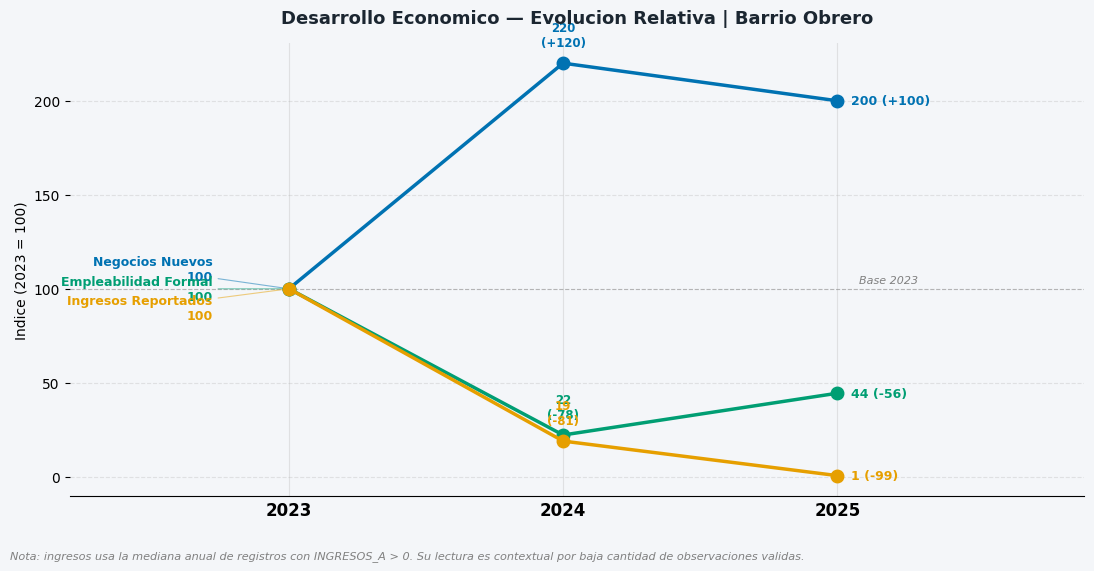

In [30]:
# ── Celda DE-6: slope chart DE — indice base 2023=100 | Barrio Obrero ───────
if 'df_ing_anual' not in globals():
    raise RuntimeError("Primero ejecuta la celda DE-5 para crear df_ing_anual.")

df_de_plot = df_de_anual.set_index('año').reindex(ANIOS_DE).copy()
df_ing_plot = df_ing_anual.set_index('año').reindex(ANIOS_DE).copy()

df_slope = pd.DataFrame({
    'año': ANIOS_DE,
    'negocios_nuevos': df_de_plot['negocios_nuevos'].values,
    'personal_nuevos': df_de_plot['personal_nuevos'].values,
    'ingresos_medianos': df_ing_plot['ingreso_mediano_m'].values,
}).set_index('año')

indicadores = {
    'negocios_nuevos':   ('Negocios Nuevos',      OKI_AZUL),
    'personal_nuevos':   ('Empleabilidad Formal', OKI_VERDE),
    'ingresos_medianos': ('Ingresos Reportados',  OKI_NARANJA),
}

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)

x_pos = [0, 1, 2]
offsets = [14, 0, -14]

for (col, (label, color)), off in zip(indicadores.items(), offsets):
    vals = df_slope[col].values.astype(float)

    if np.isnan(vals[0]) or vals[0] == 0:
        continue

    idx = (vals / vals[0]) * 100

    ax.plot(
        x_pos, idx,
        color=color, linewidth=2.5,
        marker='o', markersize=9, zorder=3, label=label
    )

    ax.annotate(
        f'{label}\n100',
        xy=(0, idx[0]),
        xytext=(-55, off),
        textcoords='offset points',
        ha='right', va='center',
        fontsize=9, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5)
    )

    if not np.isnan(idx[1]):
        d24 = idx[1] - 100
        ax.annotate(
            f'{idx[1]:.0f}\n({"+"+str(int(round(d24))) if d24 >= 0 else str(int(round(d24)))})',
            xy=(1, idx[1]), xytext=(0, 12),
            textcoords='offset points',
            ha='center', fontsize=8.5,
            color=color, fontweight='bold'
        )

    if not np.isnan(idx[2]):
        d25 = idx[2] - 100
        ax.annotate(
            f'{idx[2]:.0f} ({"+"+str(int(round(d25))) if d25 >= 0 else str(int(round(d25)))})',
            xy=(2, idx[2]), xytext=(10, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=9, color=color, fontweight='bold'
        )

ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', alpha=0.45)
ax.text(2.08, 102, 'Base 2023', ha='left', va='bottom',
        fontsize=8, color='gray', style='italic')

ax.set_xticks(x_pos)
ax.set_xticklabels(['2023', '2024', '2025'], fontsize=12, fontweight='bold')
ax.set_xlim(-0.8, 2.9)
ax.set_ylabel('Indice (2023 = 100)', fontsize=10)
ax.set_title(
    'Desarrollo Economico — Evolucion Relativa | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631', pad=14
)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)

fig.text(
    0.01, 0.01,
    'Nota: ingresos usa la mediana anual de registros con INGRESOS_A > 0. Su lectura es contextual por baja cantidad de observaciones validas.',
    fontsize=8.1, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('itt_obrero_de_slope.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

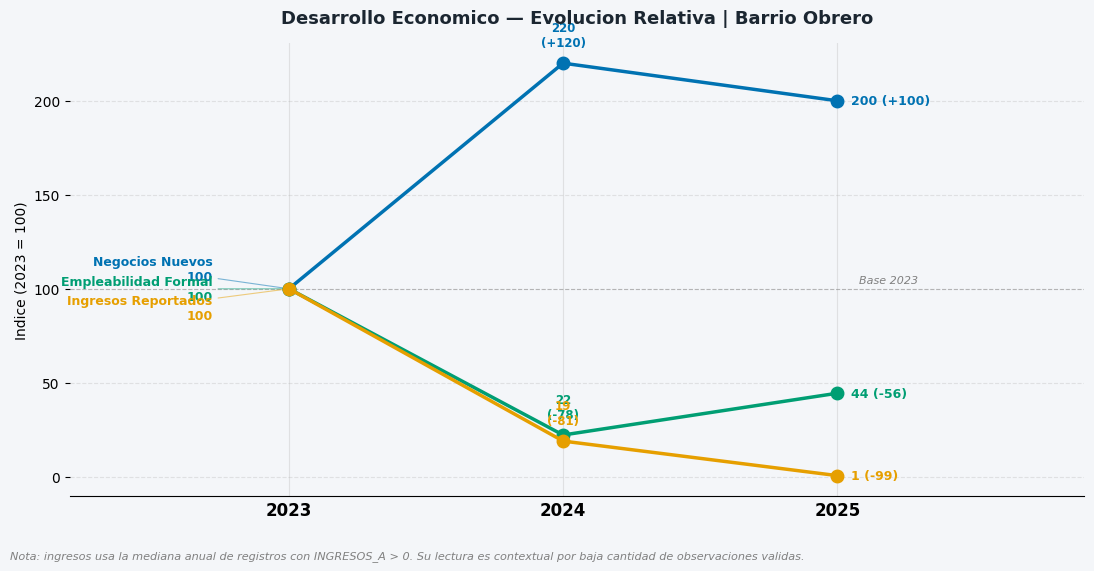

In [31]:
# ── Celda DE-6: slope chart DE — indice base 2023=100 | Barrio Obrero ───────
# Requiere:
# - df_de_anual ya creado
# - df_ing_anual ya creado en la celda de ingresos (mediana de positivos)
# - ANIOS_DE, BG, OKI_AZUL, OKI_VERDE, OKI_NARANJA ya definidos

if 'ANIOS_DE' not in globals():
    ANIOS_DE = [2023, 2024, 2025]

# Base para negocios y personal
df_de_plot = df_de_anual.set_index('año').reindex(ANIOS_DE).copy()

# Ingresos mediana positiva desde la celda contextual
if 'df_ing_anual' not in globals():
    raise RuntimeError("Primero ejecuta la celda DE-ING-VIS para crear df_ing_anual.")

df_ing_plot = df_ing_anual.set_index('año').reindex(ANIOS_DE).copy()

# Unificar en una sola tabla
df_slope = pd.DataFrame({
    'año': ANIOS_DE,
    'negocios_nuevos': df_de_plot['negocios_nuevos'].values,
    'personal_nuevos': df_de_plot['personal_nuevos'].values,
    'ingresos_medianos': df_ing_plot['ingreso_mediano_m'].values,
}).set_index('año')

indicadores = {
    'negocios_nuevos':  ('Negocios Nuevos',      OKI_AZUL),
    'personal_nuevos':  ('Empleabilidad Formal', OKI_VERDE),
    'ingresos_medianos':('Ingresos Reportados',  OKI_NARANJA),
}

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)

x_pos = [0, 1, 2]
offsets = [14, 0, -14]   # separa etiquetas 2023

for (col, (label, color)), off in zip(indicadores.items(), offsets):
    vals = df_slope[col].values.astype(float)

    # base 2023
    if np.isnan(vals[0]) or vals[0] == 0:
        continue

    idx = (vals / vals[0]) * 100

    ax.plot(
        x_pos, idx,
        color=color, linewidth=2.5,
        marker='o', markersize=9, zorder=3, label=label
    )

    # 2023
    ax.annotate(
        f'{label}\n100',
        xy=(0, idx[0]),
        xytext=(-55, off),
        textcoords='offset points',
        ha='right', va='center',
        fontsize=9, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5)
    )

    # 2024
    if not np.isnan(idx[1]):
        d24 = idx[1] - 100
        txt24 = f'{idx[1]:.0f}\n({"+"+str(int(round(d24))) if d24 >= 0 else str(int(round(d24)))})'
        ax.annotate(
            txt24,
            xy=(1, idx[1]), xytext=(0, 12),
            textcoords='offset points',
            ha='center', fontsize=8.5,
            color=color, fontweight='bold'
        )

    # 2025
    if not np.isnan(idx[2]):
        d25 = idx[2] - 100
        txt25 = f'{idx[2]:.0f} ({"+"+str(int(round(d25))) if d25 >= 0 else str(int(round(d25)))})'
        ax.annotate(
            txt25,
            xy=(2, idx[2]), xytext=(10, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=9, color=color, fontweight='bold'
        )

# Línea base
ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', alpha=0.45)
ax.text(2.08, 102, 'Base 2023', ha='left', va='bottom',
        fontsize=8, color='gray', style='italic')

ax.set_xticks(x_pos)
ax.set_xticklabels(['2023', '2024', '2025'], fontsize=12, fontweight='bold')
ax.set_xlim(-0.8, 2.9)
ax.set_ylabel('Indice (2023 = 100)', fontsize=10)
ax.set_title(
    'Desarrollo Economico — Evolucion Relativa | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631', pad=14
)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', length=0)
ax.spines[['top', 'right', 'left']].set_visible(False)

fig.text(
    0.01, 0.01,
    'Nota: ingresos usa la mediana anual de registros con INGRESOS_A > 0. Su lectura es contextual por baja cantidad de observaciones validas.',
    fontsize=8.1, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('itt_obrero_de_slope.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

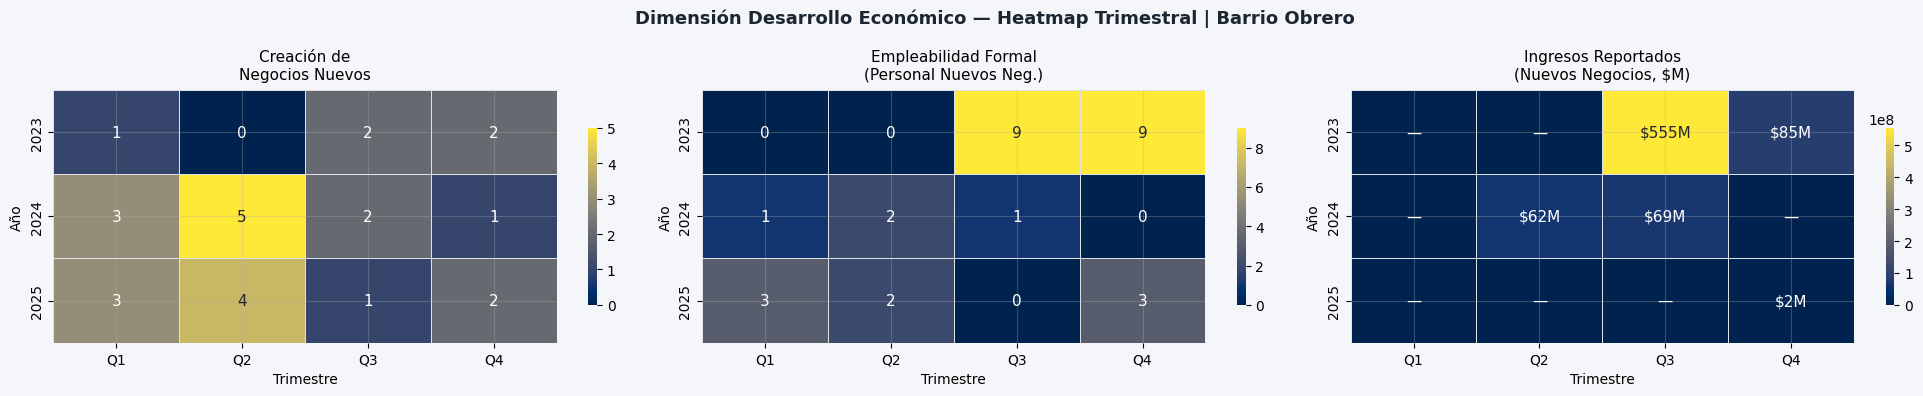

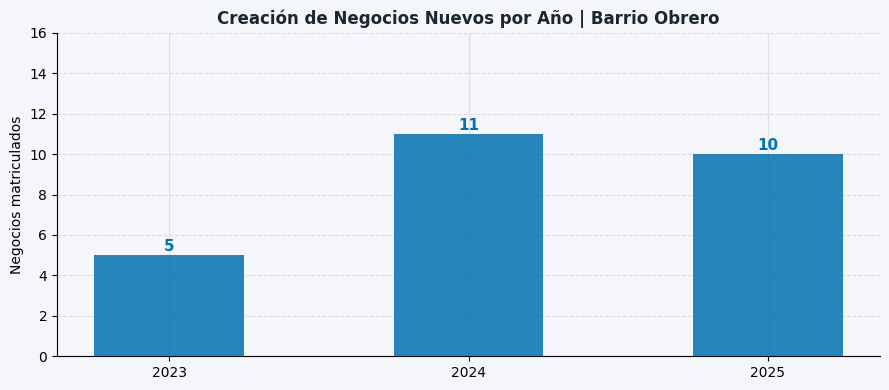

In [32]:
# ── Celda DE-4: heatmap trimestral + evolución anual Desarrollo Económico ─────
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle("Dimensión Desarrollo Económico — Heatmap Trimestral | Barrio Obrero",
             fontsize=13, fontweight="bold", color="#1B2631")

for ax, col, titulo, fmt_fn in [
    (axes[0], "negocios_nuevos", "Creación de\nNegocios Nuevos",
     lambda x: f"{int(x)}"),
    (axes[1], "personal_nuevos", "Empleabilidad Formal\n(Personal Nuevos Neg.)",
     lambda x: f"{int(x)}"),
    (axes[2], "ingresos_nuevos", "Ingresos Reportados\n(Nuevos Negocios, $M)",
    lambda x: f"${x/1e6:.0f}M" if x >= 1e6 else ("—" if x == 0 else f"${x:,.0f}")),
]:
    pivot = df_de_trim.pivot(index="año", columns="trimestre", values=col).fillna(0)
    pivot.columns = ["Q1","Q2","Q3","Q4"]
    annot = pivot.applymap(fmt_fn)
    sns.heatmap(pivot, annot=annot, fmt="", cmap="cividis",
                linewidths=0.5, linecolor="#DEE2E6", ax=ax,
                annot_kws={"size": 11}, cbar_kws={"shrink": 0.7})
    ax.set_title(titulo, fontsize=11, pad=8)
    ax.set_xlabel("Trimestre"); ax.set_ylabel("Año")

plt.tight_layout()
plt.savefig("itt_obrero_de_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# ── Evolución anual — negocios nuevos ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4), facecolor=BG)
ax2.set_facecolor(BG)
x_pos = range(len(ANIOS_DE))
bars  = ax2.bar(x_pos, df_de_anual["negocios_nuevos"], color=OKI_AZUL,
                alpha=0.85, width=0.5, zorder=3)
for bar, v in zip(bars, df_de_anual["negocios_nuevos"]):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.2, str(int(v)),
             ha="center", fontsize=11, fontweight="bold", color=OKI_AZUL)
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels([str(a) for a in ANIOS_DE])
ax2.set_title("Creación de Negocios Nuevos por Año | Barrio Obrero",
              fontsize=12, fontweight="bold", color="#1B2631")
ax2.set_ylabel("Negocios matriculados"); ax2.set_ylim(0, 16)
ax2.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("itt_obrero_de_evolucion.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


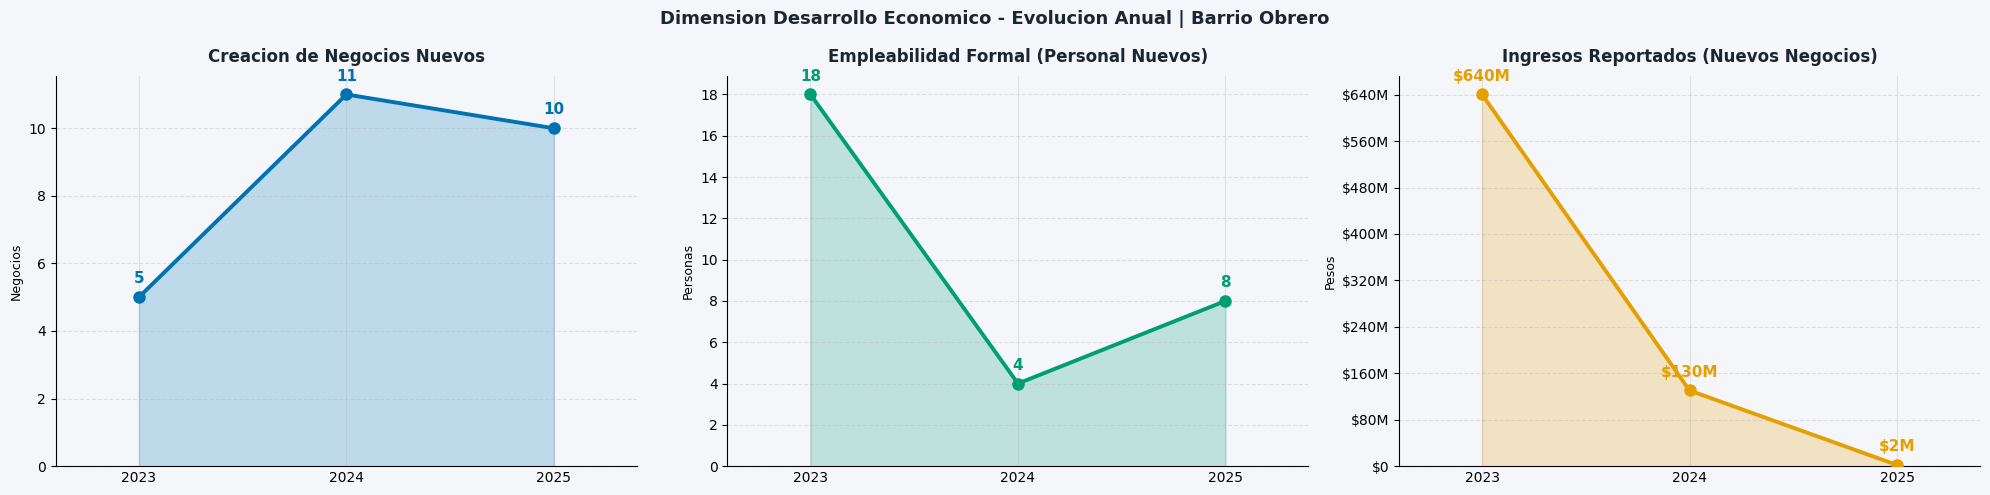

In [33]:
# -- Celda DE-5: evolucion anual Desarrollo Economico
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimension Desarrollo Economico - Evolucion Anual | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

anos_lbl = [str(a) for a in ANIOS_DE]
x_de     = np.arange(len(ANIOS_DE))

cfg_de = [
    ('negocios_nuevos', 'Creacion de Negocios Nuevos',           OKI_AZUL,    'negocios'),
    ('personal_nuevos', 'Empleabilidad Formal (Personal Nuevos)', OKI_VERDE,   'personas'),
    ('ingresos_nuevos', 'Ingresos Reportados (Nuevos Negocios)',  OKI_NARANJA, 'pesos'),
]

df_de_plot = df_de_anual.set_index('año').reindex(ANIOS_DE)

for ax, (col, titulo, color, unidad) in zip(axes, cfg_de):
    vals  = df_de_plot[col].values.astype(float)
    valid = ~np.isnan(vals)

    ax.fill_between(x_de, np.where(valid, vals, np.nan), alpha=0.22, color=color)
    ax.plot(x_de, np.where(valid, vals, np.nan),
            color=color, linewidth=2.8, marker='o', markersize=8, zorder=3)

    for i, v in enumerate(vals):
        if not np.isnan(v):
            if col == 'ingresos_nuevos':
                lbl = f'${v/1e6:.0f}M' if v >= 1e6 else f'${v:,.0f}'
            else:
                lbl = str(int(v))
            ax.annotate(lbl, (i, v),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(x_de)
    ax.set_xticklabels(anos_lbl, fontsize=10)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel(unidad.capitalize(), fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=(col != 'ingresos_nuevos')))
    if col == 'ingresos_nuevos':
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'${v/1e6:.0f}M' if v >= 1e6 else f'${v:,.0f}'))
    ax.set_xlim(-0.4, len(ANIOS_DE) - 0.6)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_facecolor(BG)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('itt_obrero_de_evol.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


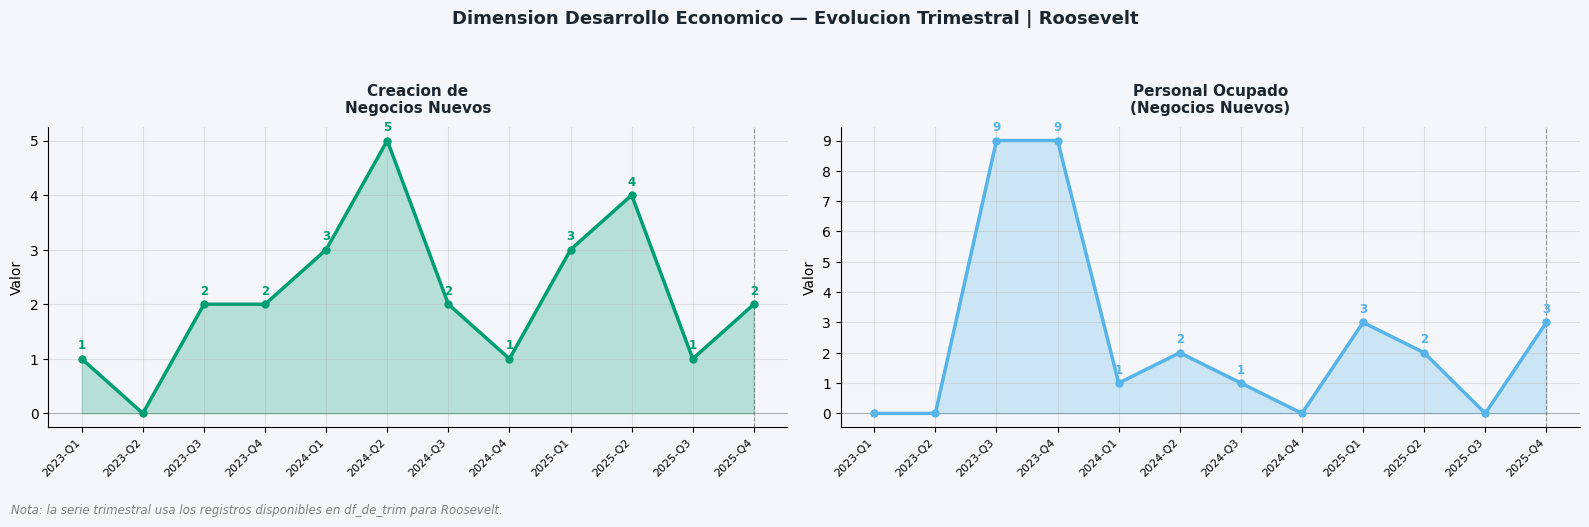

In [35]:
_de_trim = df_de_trim.copy()
_de_trim = _de_trim.sort_values(['año', 'trimestre']).reset_index(drop=True)
_periodos = _de_trim['periodo'].tolist()
_x = np.arange(len(_periodos))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), facecolor=BG)
fig.suptitle(
    'Dimension Desarrollo Economico — Evolucion Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

cfg_de = [
    (axes[0], 'negocios_nuevos', 'Creacion de\nNegocios Nuevos', OKI_VERDE,  lambda v: f'{int(v)}'),
    (axes[1], 'personal_nuevos', 'Personal Ocupado\n(Negocios Nuevos)', OKI_AZUL_C, lambda v: f'{int(v)}'),
]

for ax, col, titulo, color, fmt_fn in cfg_de:
    vals = _de_trim[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.5, marker='o', markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(
                fmt_fn(v), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8.5, fontweight='bold', color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=11, pad=10, fontweight='bold', color='#1B2631')
    ax.set_ylabel('Valor')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: la serie trimestral usa los registros disponibles en df_de_trim para Roosevelt.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_roosevelt_de_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


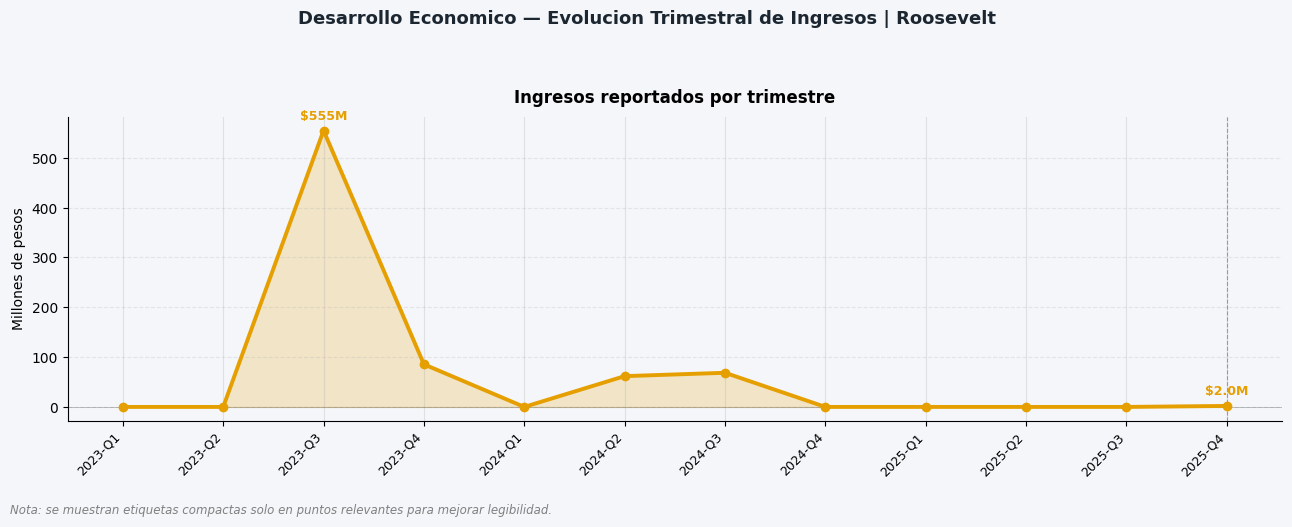

In [36]:
_ing = df_de_trim.copy()
_ing = _ing.sort_values(['año', 'trimestre']).reset_index(drop=True)
_ing['ingresos_m'] = _ing['ingresos_nuevos'] / 1e6

_periodos = _ing['periodo'].tolist()
_x = np.arange(len(_periodos))
_vals = _ing['ingresos_m'].values.astype(float)
_valid = ~pd.isna(_vals)

def fmt_compacto(v):
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    if v >= 1:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, ax = plt.subplots(figsize=(13, 5.2), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Evolucion Trimestral de Ingresos | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

ax.fill_between(_x, np.where(_valid, _vals, np.nan), alpha=0.20, color=OKI_NARANJA)
ax.plot(
    _x, np.where(_valid, _vals, np.nan),
    color=OKI_NARANJA, linewidth=2.8, marker='o', markersize=6, zorder=3
)

for i, v in enumerate(_vals):
    if not pd.notna(v) or v <= 0:
        continue

    es_max = v == np.nanmax(_vals)
    es_relevante = v >= 100
    es_ultimo = i == len(_vals) - 1

    if es_max or es_relevante or es_ultimo:
        ax.annotate(
            fmt_compacto(v), (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=9, fontweight='bold', color=OKI_NARANJA
        )

ultimo = max(i for i, v in enumerate(_vals) if pd.notna(v))
ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_xticks(_x)
ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=9)
ax.set_title('Ingresos reportados por trimestre', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: se muestran etiquetas compactas solo en puntos relevantes para mejorar legibilidad.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('itt_roosevelt_ingresos_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [37]:
# ── Celda DE-3: Score Desarrollo Economico (flujo + stock activo proxy) ─────
# Requiere:
# - df_de cargado en la celda anterior
# - base, ANIOS, score_ref, clasificar, PESOS ya definidos

# Negocios nuevos = flujo anual
# Personal e ingresos = stock acumulado formal observado hasta el año
# Nota: en gráficos se puede mostrar "Ingresos reportados" sin aclaración larga.

REF_NEG_MIN,  REF_NEG_MAX  = 0, 15     # negocios nuevos por año
REF_PERS_MIN, REF_PERS_MAX = 0, 120    # personal stock acumulado
REF_ING_MIN,  REF_ING_MAX  = 0, 24.5   # log1p(ingresos stock acumulado), ajustar si Fernando lo pide

rows_de_sc = []

for ano in ANIOS:
    sub_new   = df_de[df_de['anio_mat'] == ano].copy()
    sub_stock = df_de[df_de['anio_mat'] <= ano].copy()

    if len(sub_new) > 0:
        neg = float(len(sub_new))
    else:
        neg = np.nan

    if len(sub_stock) > 0:
        pers = float(sub_stock['personal_limpio'].sum())
        ing  = float(sub_stock['ingresos_limpio'].sum(skipna=True))
        ing_log = float(np.log1p(ing)) if pd.notna(ing) and ing > 0 else 0.0
    else:
        pers = ing = ing_log = np.nan

    sc_neg  = score_ref(neg,     REF_NEG_MIN,  REF_NEG_MAX,  False) if not pd.isna(neg)  else np.nan
    sc_pers = score_ref(pers,    REF_PERS_MIN, REF_PERS_MAX, False) if not pd.isna(pers) else np.nan
    sc_ing  = score_ref(ing_log, REF_ING_MIN,  REF_ING_MAX,  False) if not pd.isna(ing)  else np.nan

    vals = [x for x in [sc_neg, sc_pers, sc_ing] if not pd.isna(x)]
    sc_de = float(np.mean(vals)) if len(vals) > 0 else np.nan

    rows_de_sc.append({
        'año': ano,
        'negocios_nuevos': neg,
        'personal_stock': pers,
        'ingresos_stock': ing,
        'ingresos_log1p': ing_log,
        'score_negocios': sc_neg,
        'score_personal': sc_pers,
        'score_ingresos': sc_ing,
        'score_des_eco': sc_de,
    })

df_de_scores = pd.DataFrame(rows_de_sc)

# Actualizar base solo donde haya score real calculado
for _, r in df_de_scores.iterrows():
    if not pd.isna(r['score_des_eco']):
        base.loc[base['año'] == int(r['año']), 'score_des_eco'] = r['score_des_eco']

# Recalcular ITT con los 6 scores
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['EducDes']   * base['score_educ_des'] +
    PESOS['Cohesion']  * base['score_cohesion'] +
    PESOS['DesEco']    * base['score_des_eco']
)
base['nivel'] = base['ITT'].apply(clasificar)

print("Scores Desarrollo Economico por año (flujo + stock activo proxy):")
cols_sc = [
    'año', 'negocios_nuevos', 'personal_stock', 'ingresos_stock',
    'ingresos_log1p', 'score_negocios', 'score_personal',
    'score_ingresos', 'score_des_eco'
]
print(df_de_scores[cols_sc].round(2).to_string(index=False))
print()
print("ITT actualizado — 6 dimensiones:")
cols_b = [
    'año', 'score_seguridad', 'score_movilidad', 'score_cohesion',
    'score_entorno_u', 'score_educ_des', 'score_des_eco', 'ITT', 'nivel'
]
print(base[cols_b].round(1).to_string(index=False))


Scores Desarrollo Economico por año (flujo + stock activo proxy):
 año  negocios_nuevos  personal_stock  ingresos_stock  ingresos_log1p  score_negocios  score_personal  score_ingresos  score_des_eco
2023              5.0           385.0    1.039090e+11           25.37           33.33           100.0           100.0          77.78
2024             11.0           389.0    1.040394e+11           25.37           73.33           100.0           100.0          91.11
2025             10.0           397.0    1.040414e+11           25.37           66.67           100.0           100.0          88.89
2026              NaN           397.0    1.040414e+11           25.37             NaN           100.0           100.0         100.00

ITT actualizado — 6 dimensiones:
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  score_des_eco  ITT          nivel
2023             79.0             57.1            37.6             39.2            54.9           77.8 61.1 Tran

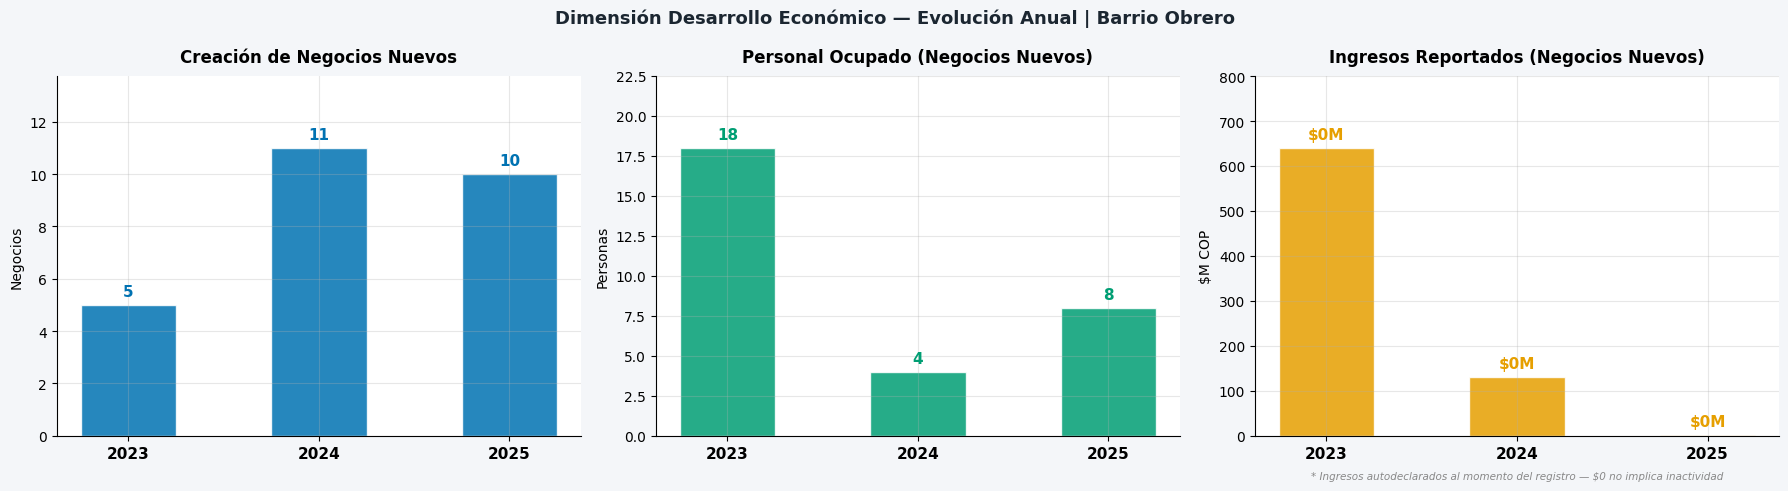

✓ DE evolución anual generada


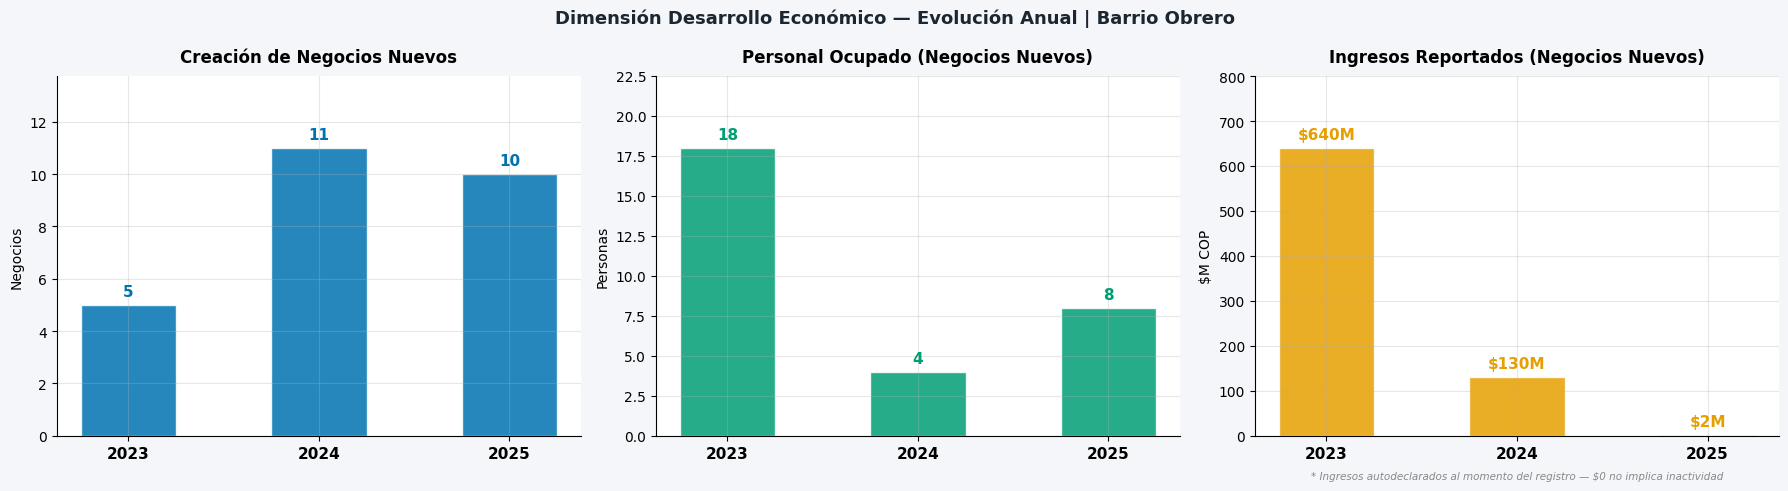

✓ DE evolución anual generada


In [ ]:
# ── DE: Evolución Anual — barras ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimensión Desarrollo Económico — Evolución Anual | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_de_scores.set_index('año').reindex([2023, 2024, 2025])
años  = [2023, 2024, 2025]
x     = np.arange(len(años))
W     = 0.5

cfg = [
    ('negocios_nuevos', 'Creación de Negocios Nuevos',     OKI_AZUL,    'Negocios',  '{:.0f}',   None),
    ('personal_nuevos', 'Personal Ocupado (Negocios Nuevos)', OKI_VERDE, 'Personas',  '{:.0f}',   None),
    ('ingresos_nuevos', 'Ingresos Reportados (Negocios Nuevos)', OKI_NARANJA,'Pesos', '{:.0f}',  1e6),
]

for ax, (col, titulo, color, ylabel, fmt, divisor) in zip(axes, cfg):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float) if col in df_e.columns else np.zeros(len(años))

    display_vals = vals / divisor if divisor else vals
    bars = ax.bar(x, display_vals, color=color, alpha=0.85,
                  edgecolor='white', width=W)

    for bar, v in zip(bars, display_vals):
        if not np.isnan(v) and v > 0:
            label = f'${v/1e6:.0f}M' if divisor else fmt.format(v)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(display_vals)*0.02,
                    label, ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(['2023', '2024', '2025'], fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_ylabel('$M COP' if divisor else ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(display_vals) * 1.25 if max(display_vals) > 0 else 1)

    # nota ingresos
    if col == 'ingresos_nuevos':
        ax.text(0.5, -0.12,
                '* Ingresos autodeclarados al momento del registro — $0 no implica inactividad',
                transform=ax.transAxes, ha='center', fontsize=7.5,
                color='#888888', style='italic')

plt.tight_layout()
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_obrero_de_evolucion_anual.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ DE evolución anual generada')
# ── DE: Evolución Anual — barras ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimensión Desarrollo Económico — Evolución Anual | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_de_scores.set_index('año').reindex([2023, 2024, 2025])
años  = [2023, 2024, 2025]
x     = np.arange(len(años))
W     = 0.5

cfg = [
    ('negocios_nuevos', 'Creación de Negocios Nuevos',     OKI_AZUL,    'Negocios',  '{:.0f}',   None),
    ('personal_nuevos', 'Personal Ocupado (Negocios Nuevos)', OKI_VERDE, 'Personas',  '{:.0f}',   None),
    ('ingresos_nuevos', 'Ingresos Reportados (Negocios Nuevos)', OKI_NARANJA,'Pesos', '{:.0f}',  1e6),
]

for ax, (col, titulo, color, ylabel, fmt, divisor) in zip(axes, cfg):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float) if col in df_e.columns else np.zeros(len(años))

    display_vals = vals / divisor if divisor else vals
    bars = ax.bar(x, display_vals, color=color, alpha=0.85,
                  edgecolor='white', width=W)

    for bar, v in zip(bars, display_vals):
        if not np.isnan(v) and v > 0:
            label = f'${v:.0f}M' if divisor else fmt.format(v)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(display_vals)*0.02,
                    label, ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(['2023', '2024', '2025'], fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_ylabel('$M COP' if divisor else ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, max(display_vals) * 1.25 if max(display_vals) > 0 else 1)

    # nota ingresos
    if col == 'ingresos_nuevos':
        ax.text(0.5, -0.12,
                '* Ingresos autodeclarados al momento del registro — $0 no implica inactividad',
                transform=ax.transAxes, ha='center', fontsize=7.5,
                color='#888888', style='italic')

plt.tight_layout()
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_obrero_de_evolucion_anual.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ DE evolución anual generada')


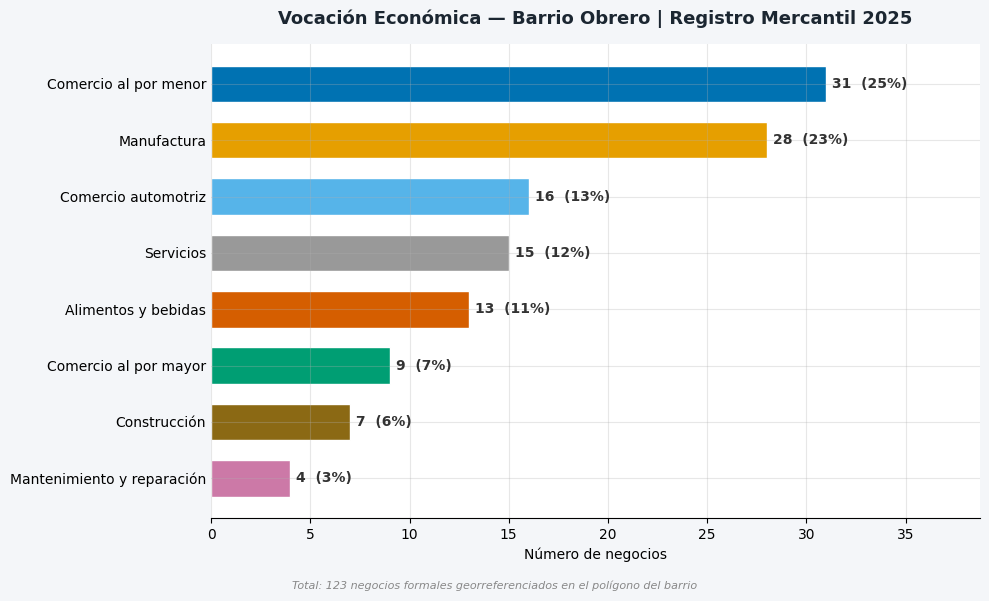

✓ Vocación económica CIIU generada


In [ ]:
# ── CIIU — Vocación económica | Barrio Obrero ─────────────────────────────────
import json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Leer GeoJSON ──────────────────────────────────────────────────────────────
with open(PATHS['registro_mercantil'], encoding='utf-8') as f:
    _gj = json.load(f)

# ── Mapeo CIIU 2 dígitos → macro-sector ──────────────────────────────────────
SECTOR_MAP = {
    '45': 'Comercio automotriz',
    '46': 'Comercio al por mayor',
    '47': 'Comercio al por menor',
    '56': 'Alimentos y bebidas',
    '55': 'Alimentos y bebidas',
    '10': 'Manufactura',
    '13': 'Manufactura',
    '15': 'Manufactura',
    '16': 'Manufactura',
    '22': 'Manufactura',
    '24': 'Manufactura',
    '25': 'Manufactura',
    '31': 'Manufactura',
    '29': 'Mantenimiento y reparación',
    '33': 'Mantenimiento y reparación',
    '42': 'Construcción',
    '43': 'Construcción',
    '38': 'Servicios',
    '68': 'Servicios',
    '70': 'Servicios',
    '73': 'Servicios',
    '74': 'Servicios',
    '85': 'Servicios',
    '86': 'Servicios',
    '90': 'Servicios',
    '91': 'Servicios',
    '94': 'Servicios',
    '96': 'Servicios',
}
SECTOR_COLORS = {
    'Comercio al por menor':      '#0072B2',
    'Comercio automotriz':        '#56B4E9',
    'Comercio al por mayor':      '#009E73',
    'Manufactura':                '#E69F00',
    'Alimentos y bebidas':        '#D55E00',
    'Mantenimiento y reparación': '#CC79A7',
    'Construcción':               '#8B6914',
    'Servicios':                  '#999999',
    'Otro':                       '#DDDDDD',
}

# ── Construir DataFrame ───────────────────────────────────────────────────────
rows = []
for feat in _gj['features']:
    p   = feat['properties']
    cod = str(p.get('CODIGO_CII', '')).strip()
    sec2 = cod[:2] if len(cod) >= 2 else ''
    rows.append({'sector': SECTOR_MAP.get(sec2, 'Otro')})

df_ciiu   = pd.DataFrame(rows)
dist_total = df_ciiu['sector'].value_counts().sort_values()

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor('white')

colors_h = [SECTOR_COLORS.get(s, '#CCC') for s in dist_total.index]
bars = ax.barh(dist_total.index, dist_total.values,
               color=colors_h, edgecolor='white', height=0.65)

for bar, val in zip(bars, dist_total.values):
    pct = val / len(df_ciiu) * 100
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.0f}%)',
            va='center', fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Vocación Económica — Barrio Obrero | Registro Mercantil 2025',
             fontsize=13, fontweight='bold', color='#1B2631', pad=14)
ax.set_xlabel('Número de negocios')
ax.set_xlim(0, dist_total.max() * 1.25)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

fig.text(0.5, 0.01,
         f'Total: {len(df_ciiu)} negocios formales georreferenciados en el polígono del barrio',
         ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 1])
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_obrero_ciiu_vocacion.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Vocación económica CIIU generada')


In [ ]:
print(type(base))
print(base.dtypes)
print(base[['año','score_educ_des','score_des_eco','ITT']].to_string())

<class 'pandas.core.frame.DataFrame'>
año                       int64
homicidios                int64
hurtos                    int64
siniestralidad            int64
lesionados                int64
mortales                  int64
vif                       int64
rinas                     int64
score_homicidios        float64
score_hurtos            float64
score_siniestralidad    float64
score_lesionados        float64
score_mortales          float64
score_vif               float64
score_rinas             float64
spa                       int64
score_spa               float64
score_seguridad         float64
score_movilidad         float64
score_cohesion          float64
score_entorno_u         float64
score_educ_des          float64
score_des_eco           float64
ITT                     float64
nivel                    object
dtype: object
    año  score_educ_des  score_des_eco        ITT
0  2023            13.7      74.244162  54.792894
1  2024            30.0      61.643424  56.03589

## Celda 15 — ITT Global y composicion por dimension


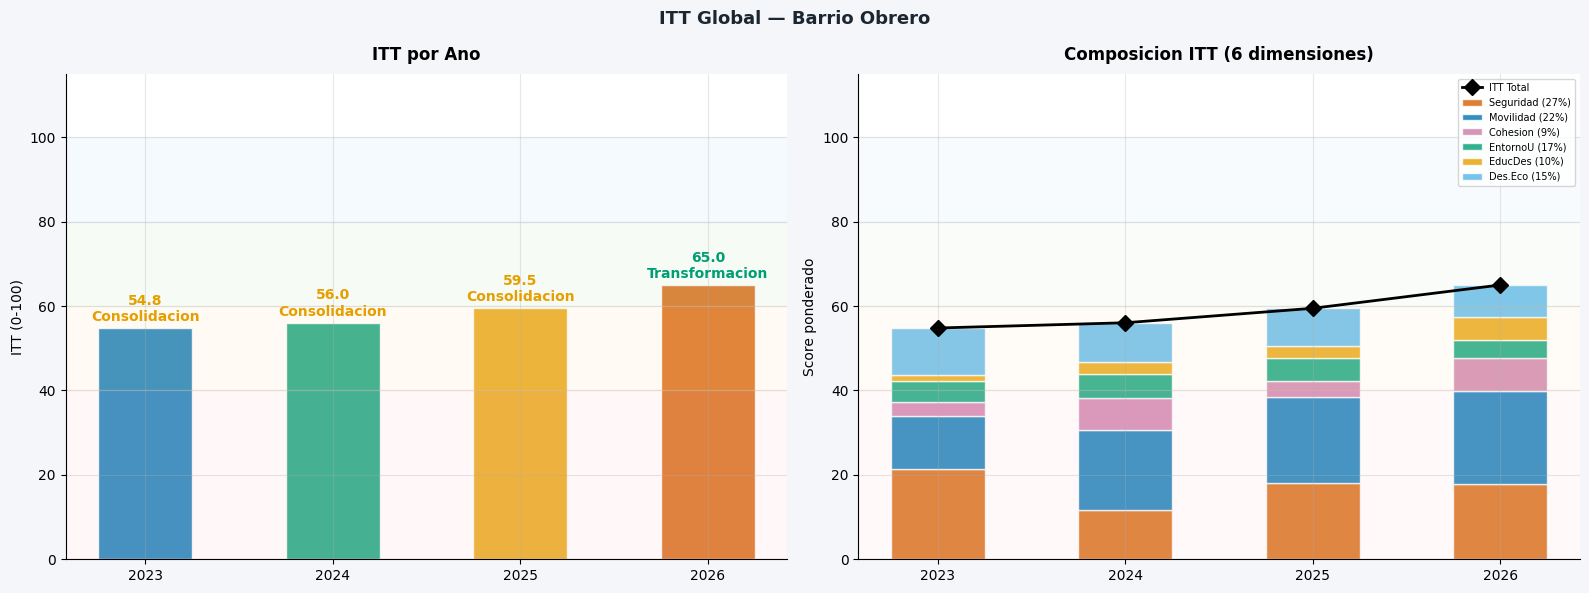

In [ ]:
# ── ITT Global — Barrio Obrero ────────────────────────────────────────────────
if not isinstance(base, pd.DataFrame):
    raise RuntimeError(
        f"'base' es {type(base).__name__}. "
        "Alguna celda entre Normalizacion y esta sobreescribio la variable. "
        "Re-ejecuta SOLO la celda de Normalizacion+ITT y luego EU-2, ED-3 y DE-3."
    )

COLORES_ITT  = [OKI_AZUL, OKI_VERDE, OKI_NARANJA, OKI_BERMELL][:len(ANIOS)]
band_configs = [(0,40,'#FFCDD2','Activacion'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Transformacion'),(80,100,'#BBDEFB','Escala')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('ITT Global — Barrio Obrero', fontsize=13, fontweight='bold', color='#1B2631')

# Panel 1: barras ITT por año
ax1 = axes[0]
bars = ax1.bar(ANIOS, base['ITT'], color=COLORES_ITT, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, val, nivel in zip(bars, base['ITT'], base['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1,
             f'{val:.1f}\n{nivel}', ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs:
    ax1.axhspan(y0, y1, alpha=0.15, color=c)
ax1.set_title('ITT por Ano', fontweight='bold', pad=10)
ax1.set_ylim(0, 115); ax1.set_ylabel('ITT (0-100)'); ax1.set_xticks(ANIOS)

# Panel 2: composicion 6 dimensiones
ax2 = axes[1]
dims   = ['score_seguridad','score_movilidad','score_cohesion',
          'score_entorno_u','score_educ_des','score_des_eco']
lbls   = ['Seguridad','Movilidad','Cohesion','EntornoU','EducDes','Des.Eco']
pesos  = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['Cohesion'],
          PESOS['EntornoU'],PESOS['EducDes'],PESOS['DesEco']]
cols   = [OKI_BERMELL, OKI_AZUL, OKI_MORADO, OKI_VERDE, OKI_NARANJA, OKI_AZUL_C]

bottom = np.zeros(len(ANIOS))
for dim, lbl, peso, col in zip(dims, lbls, pesos, cols):
    if dim in base.columns:
        vals = base[dim].fillna(0).values * peso
        ax2.bar(ANIOS, vals, bottom=bottom,
                label=f'{lbl} ({peso:.0%})', color=col, alpha=0.8,
                edgecolor='white', width=0.5)
        bottom += vals

ax2.plot(ANIOS, base['ITT'], 'D-', color='black', linewidth=2,
         markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs:
    ax2.axhspan(y0, y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT (6 dimensiones)', fontweight='bold', pad=10)
ax2.set_ylim(0, 115); ax2.set_ylabel('Score ponderado'); ax2.set_xticks(ANIOS)
ax2.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('itt_obrero_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 16 — Radar ITT: 5 dimensiones


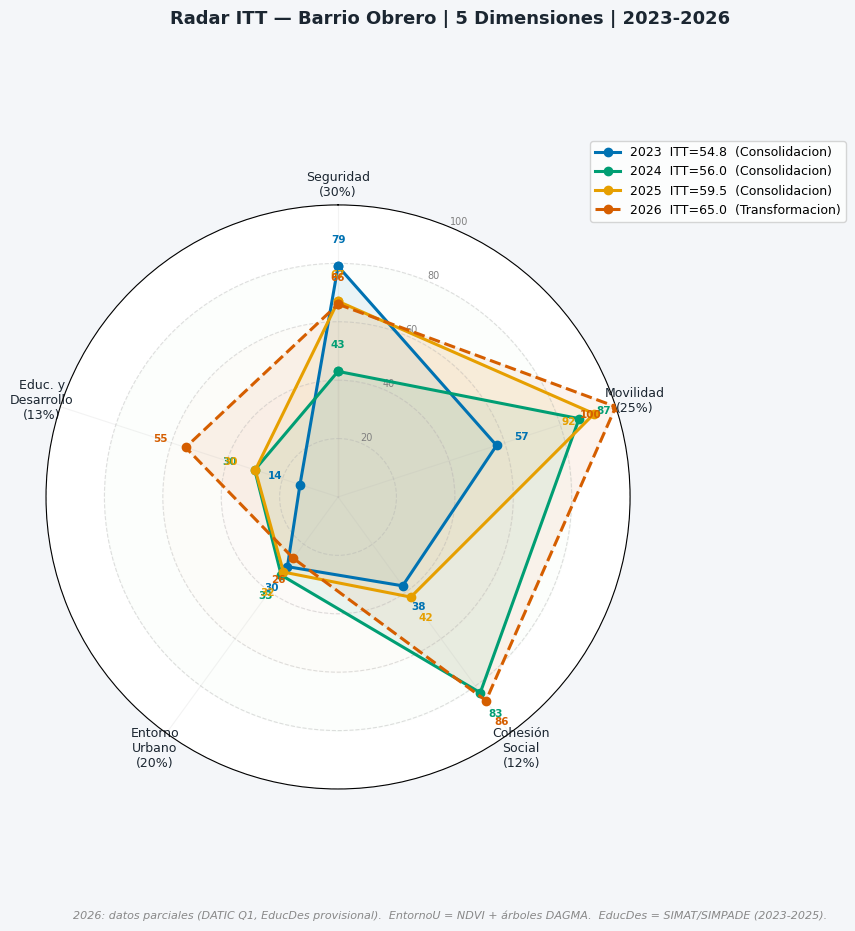

In [ ]:
# ── Celda 16 — Radar ITT actualizado: 5 dimensiones | 2023-2026 ──────────────
DIMS_LBL = [
    'Seguridad\n(30%)', 'Movilidad\n(25%)', 'Cohesión\nSocial\n(12%)',
    'Entorno\nUrbano\n(20%)', 'Educ. y\nDesarrollo\n(13%)'
]
DIMS_COL = ['score_seguridad','score_movilidad','score_cohesion',
            'score_entorno_u','score_educ_des']
N_DIMS = len(DIMS_LBL)
angles = [i / N_DIMS * 2 * np.pi for i in range(N_DIMS)]
angles += angles[:1]   # cerrar polígono

# Okabe-Ito: 4 colores para 4 años
COLORES_R = {2023: OKI_AZUL, 2024: OKI_VERDE, 2025: OKI_NARANJA, 2026: OKI_BERMELL}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), facecolor=BG)
ax.set_facecolor('white')
fig.suptitle('Radar ITT — Barrio Obrero | 5 Dimensiones | 2023-2026',
             fontsize=13, fontweight='bold', color='#1B2631')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIMS_LBL, fontsize=9, color='#1B2631')
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='-', alpha=0.15)

# Bandas de nivel (fondo)
for y, c in [(40,'#FFCDD2'), (60,'#FFE0B2'), (80,'#C8E6C9')]:
    ax.fill_between(np.linspace(0, 2*np.pi, 200), 0, y, alpha=0.04, color=c)

for año in ANIOS:
    row   = base[base['año'] == año].iloc[0]
    vals  = [row[c] for c in DIMS_COL]
    vals_c = vals + [vals[0]]
    color = COLORES_R[año]
    ls    = '--' if año == 2026 else '-'   # 2026 punteado = datos parciales

    ax.plot(angles, vals_c, linestyle=ls, marker='o', color=color,
            linewidth=2.2, markersize=6, zorder=3,
            label=f'{año}  ITT={row["ITT"]:.1f}  ({row["nivel"]})')
    ax.fill(angles, vals_c, alpha=0.07, color=color)

    # Valor en cada vértice
    for ang, val in zip(angles[:-1], vals):
        offset = 9 if val < 90 else -9
        ax.text(ang, val + offset, f'{val:.0f}',
                ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')

ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=9, frameon=True)

fig.text(0.5, -0.03,
    '2026: datos parciales (DATIC Q1, EducDes provisional).  '
    'EntornoU = NDVI + árboles DAGMA.  EducDes = SIMAT/SIMPADE (2023-2025).',
    ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('itt_obrero_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()



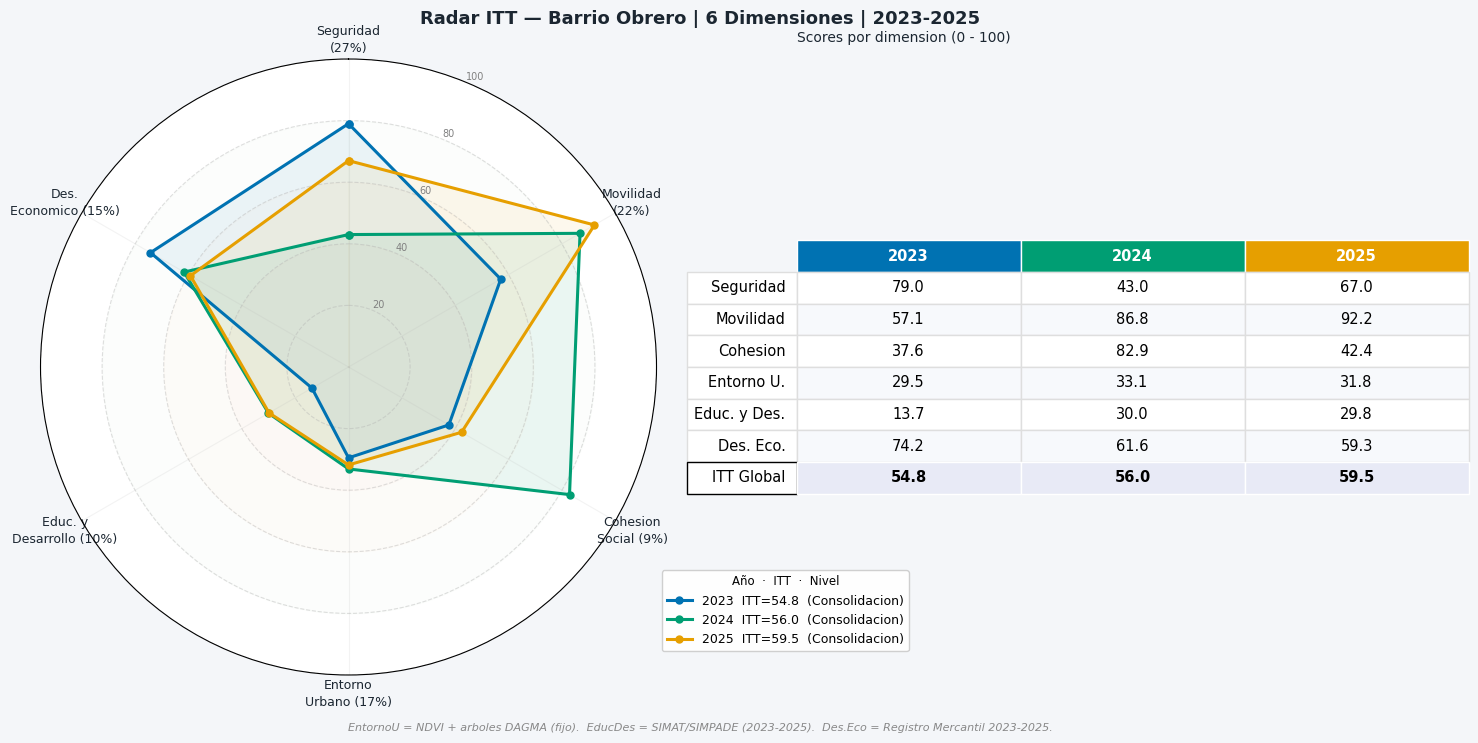

In [ ]:
# ── Celda 16 — Radar ITT: 6 dimensiones | 2023-2025 ─────────────────────────
DIMS_LBL = [
    'Seguridad\n(27%)', 'Movilidad\n(22%)', 'Cohesion\nSocial (9%)',
    'Entorno\nUrbano (17%)', 'Educ. y\nDesarrollo (10%)', 'Des.\nEconomico (15%)',
]
DIMS_COL   = ['score_seguridad','score_movilidad','score_cohesion',
              'score_entorno_u','score_educ_des','score_des_eco']
DIMS_ABREV = ['Seguridad','Movilidad','Cohesion','Entorno U.','Educ. y Des.','Des. Eco.']
N_DIMS     = len(DIMS_LBL)
angles     = [i / N_DIMS * 2 * np.pi for i in range(N_DIMS)]
angles    += angles[:1]

ANIOS_R   = [2023, 2024, 2025]
COLORES_R = {2023: OKI_AZUL, 2024: OKI_VERDE, 2025: OKI_NARANJA}

# ── Layout 2 paneles ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7), facecolor=BG)
ax_r = fig.add_axes([0.02, 0.06, 0.52, 0.88], polar=True)
ax_t = fig.add_axes([0.56, 0.06, 0.42, 0.88])
fig.suptitle('Radar ITT — Barrio Obrero | 6 Dimensiones | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631', y=1.01)

# ── Panel izquierdo: Radar ────────────────────────────────────────────────────
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(DIMS_LBL, fontsize=9, color='#1B2631', linespacing=1.4)
ax_r.set_ylim(0, 100)
ax_r.set_yticks([20, 40, 60, 80, 100])
ax_r.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax_r.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_r.xaxis.grid(True, linestyle='-', alpha=0.15)

for y, c in [(40,'#FFCDD2'),(60,'#FFE0B2'),(80,'#C8E6C9')]:
    ax_r.fill_between(np.linspace(0, 2*np.pi, 200), 0, y, alpha=0.05, color=c)

for año in ANIOS_R:
    row    = base[base['año'] == año].iloc[0]
    vals   = [row[c] if not pd.isna(row[c]) else 0 for c in DIMS_COL]
    vals_c = vals + [vals[0]]
    color  = COLORES_R[año]
    ax_r.plot(angles, vals_c, linewidth=2.2, color=color,
              marker='o', markersize=5,
              label=f"{año}  ITT={row['ITT']:.1f}  ({row['nivel']})")
    ax_r.fill(angles, vals_c, alpha=0.07, color=color)

ax_r.legend(loc='upper right', bbox_to_anchor=(1.42, 0.18),
            fontsize=9, framealpha=0.92,
            title='Año  ·  ITT  ·  Nivel', title_fontsize=8.5)

# ── Panel derecho: Tabla de scores ───────────────────────────────────────────
ax_t.axis('off')

col_labels = [str(a) for a in ANIOS_R]
row_labels  = DIMS_ABREV + ['ITT Global']

table_data = []
for dim in DIMS_COL:
    table_data.append([
        f"{base[base['año']==a].iloc[0][dim]:.1f}"
        if not pd.isna(base[base['año']==a].iloc[0][dim]) else '—'
        for a in ANIOS_R
    ])
table_data.append([f"{base[base['año']==a].iloc[0]['ITT']:.1f}" for a in ANIOS_R])

tbl = ax_t.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center', rowLoc='right',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1.0, 1.9)

for j, año in enumerate(ANIOS_R):
    cell = tbl[0, j]
    cell.set_facecolor(COLORES_R[año])
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

n = len(table_data)
for j in range(len(ANIOS_R)):
    cell = tbl[n, j]
    cell.set_facecolor('#E8EAF6')
    cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('white')

for i in range(1, n):
    for j in range(len(ANIOS_R)):
        tbl[i, j].set_facecolor('#F7F9FC' if i % 2 == 0 else 'white')
        tbl[i, j].set_edgecolor('#DEDEDE')
    tbl[i, -1].set_edgecolor('#DEDEDE')

ax_t.set_title('Scores por dimension (0 - 100)', fontsize=10,
               color='#1B2631', pad=12, loc='left')

fig.text(0.5, -0.02,
    'EntornoU = NDVI + arboles DAGMA (fijo).  '
    'EducDes = SIMAT/SIMPADE (2023-2025).  '
    'Des.Eco = Registro Mercantil 2023-2025.',
    ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('itt_obrero_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


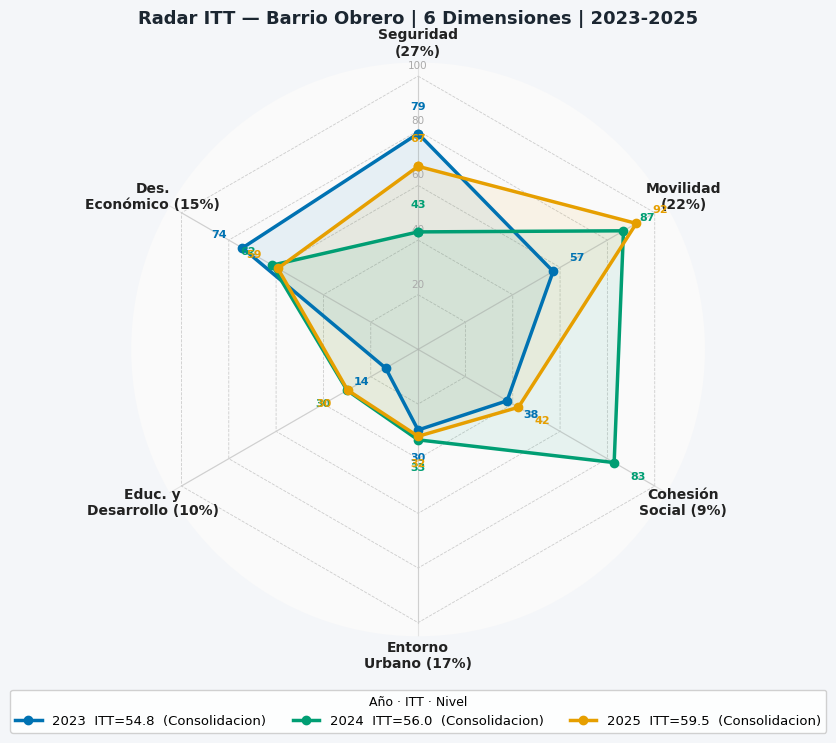

✓ Radar ITT generado


In [ ]:
# ── Radar ITT — 6 dimensiones | 2023-2025 ────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DIMS_LBL = [
    'Seguridad\n(27%)',
    'Movilidad\n(22%)',
    'Cohesión\nSocial (9%)',
    'Entorno\nUrbano (17%)',
    'Educ. y\nDesarrollo (10%)',
    'Des.\nEconómico (15%)',
]
DIMS_COL = ['score_seguridad','score_movilidad','score_cohesion',
            'score_entorno_u','score_educ_des','score_des_eco']
ANIOS_R  = [2023, 2024, 2025]
COLORES_R = {2023: OKI_AZUL, 2024: OKI_VERDE, 2025: OKI_NARANJA}

N      = len(DIMS_LBL)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True),
                       facecolor=BG)
ax.set_facecolor('#FAFAFA')

# Anillos de referencia
for r in [20, 40, 60, 80, 100]:
    ax.plot(angles, [r]*(N+1), color='#CCCCCC', linewidth=0.6, linestyle='--', zorder=1)
    ax.text(angles[0], r + 2, str(r), ha='center', va='bottom',
            fontsize=7.5, color='#AAAAAA')

# Líneas de eje
for ang in angles[:-1]:
    ax.plot([ang, ang], [0, 100], color='#DDDDDD', linewidth=0.8, zorder=1)

# Series por año
for año in ANIOS_R:
    row = base[base['año'] == año]
    if row.empty:
        continue
    vals = [float(row[c].iloc[0]) if c in row.columns else 0 for c in DIMS_COL]
    vals += vals[:1]
    color = COLORES_R[año]
    itt   = float(row['ITT'].iloc[0])
    nivel = str(row['nivel'].iloc[0])

    ax.plot(angles, vals, color=color, linewidth=2.5,
            marker='o', markersize=6, zorder=3, label=f'{año}  ITT={itt:.1f}  ({nivel})')
    ax.fill(angles, vals, color=color, alpha=0.08)

    # Etiquetas de valor en cada vértice
    for ang, v in zip(angles[:-1], vals[:-1]):
        offset = 10
        ax.annotate(f'{v:.0f}',
                    xy=(ang, v),
                    xytext=(ang, v + offset),
                    ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold',
                    textcoords='data')

# Etiquetas dimensiones
ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIMS_LBL, fontsize=10, fontweight='bold', color='#222222')
ax.set_yticks([])
ax.spines['polar'].set_visible(False)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Leyenda
leg = ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18),
                ncol=3, fontsize=9.5, frameon=True,
                framealpha=0.9, edgecolor='#CCCCCC',
                title='Año · ITT · Nivel', title_fontsize=9)

ax.set_title('Radar ITT — Barrio Obrero | 6 Dimensiones | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631',
             pad=28)

plt.tight_layout()
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_obrero_radar.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✓ Radar ITT generado')


## Evolución Temporal ITT Global

Serie trimestral construida desde `corr_trim` con refs ajustados a trimestre (annual / 4).
Entorno Urbano y Educación son anuales → línea plana dentro de cada año por diseño.


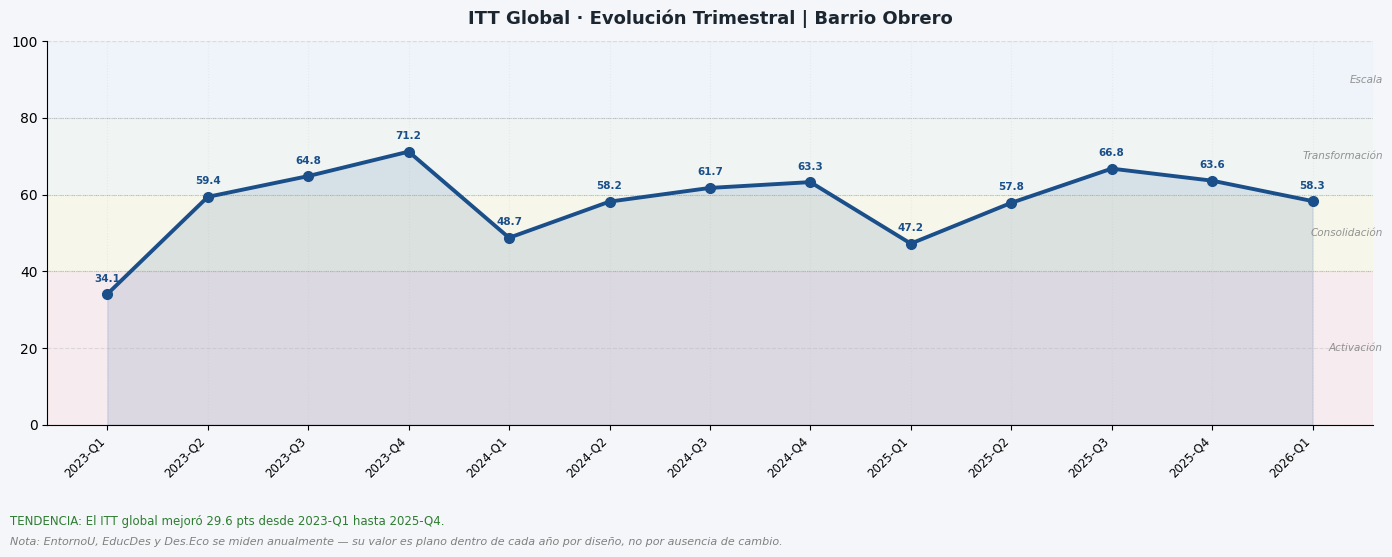

In [ ]:
# ── Evolución Trimestral ITT Global — Barrio Obrero (6 dimensiones) ───────────
REFS_Q = {
    'homicidios':     (0,     1.25,  True),
    'hurtos':         (2.5,  15.0,   True),
    'siniestralidad': (0.25,  3.75,  True),
    'lesionados':     (0.25,  3.0,   True),
    'mortales':       (0,     0.75,  True),
    'vif':            (0.25,  3.75,  True),
    'rinas':          (0,     2.5,   True),
}

rows_q = []
for _, r in corr_trim.iterrows():
    anio = int(r['año'])
    trim = int(r['trimestre'])
    if anio == 2026 and trim > 1:
        continue

    def qs(col):
        v = r[col]
        if pd.isna(v): return np.nan
        rmin, rmax, inv = REFS_Q[col]
        return score_ref(v, rmin, rmax, inv)

    seg_vals = [x for x in [qs('homicidios'), qs('hurtos')] if not pd.isna(x)]
    mov_vals = [x for x in [qs('siniestralidad'), qs('lesionados'), qs('mortales')] if not pd.isna(x)]
    coh_vals = [x for x in [qs('vif'), qs('rinas')] if not pd.isna(x)]

    sc_seg = np.mean(seg_vals) if seg_vals else np.nan
    sc_mov = np.mean(mov_vals) if mov_vals else np.nan

    # Cohesion: vif + rinas (trimestrales) + spa (anual desde base)
    brow   = base[base['año'] == anio]
    sc_spa = float(brow['score_spa'].iloc[0]) if not brow.empty and 'score_spa' in brow.columns else np.nan
    sc_coh = np.mean(coh_vals + ([sc_spa] if not pd.isna(sc_spa) else [])) if coh_vals else np.nan

    # Dimensiones anuales (planas dentro del año)
    sc_ent = float(brow['score_entorno_u'].iloc[0]) if not brow.empty else np.nan
    sc_edu = float(brow['score_educ_des'].iloc[0])  if not brow.empty else np.nan
    sc_de  = float(brow['score_des_eco'].iloc[0])   if not brow.empty else np.nan

    itt_q = (
        PESOS['Seguridad'] * (sc_seg if not pd.isna(sc_seg) else 0) +
        PESOS['Movilidad'] * (sc_mov if not pd.isna(sc_mov) else 0) +
        PESOS['EntornoU']  * (sc_ent if not pd.isna(sc_ent) else 0) +
        PESOS['EducDes']   * (sc_edu if not pd.isna(sc_edu) else 0) +
        PESOS['Cohesion']  * (sc_coh if not pd.isna(sc_coh) else 0) +
        PESOS['DesEco']    * (sc_de  if not pd.isna(sc_de)  else 0)
    )
    rows_q.append({'periodo': r['periodo'], 'año': anio, 'trimestre': trim, 'ITT': itt_q})

df_evol = pd.DataFrame(rows_q)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)

x_idx    = range(len(df_evol))
n_per    = len(df_evol)
itt_vals = df_evol['ITT'].values

BANDAS = [
    (0,  40,  '#FFCDD2', 'Activación'),
    (40, 60,  '#FFF9C4', 'Consolidación'),
    (60, 80,  '#E8F5E9', 'Transformación'),
    (80, 100, '#E3F2FD', 'Escala'),
]
for y0, y1, color, lbl in BANDAS:
    ax.axhspan(y0, y1, alpha=0.25, color=color, zorder=0)
    ax.text(n_per - 0.3, (y0 + y1) / 2, lbl,
            fontsize=7.5, color='gray', ha='right', va='center',
            style='italic', alpha=0.85)

for y in [40, 60, 80]:
    ax.axhline(y, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

ax.plot(x_idx, itt_vals, '-o', linewidth=2.8, color='#1B4F8A',
        markersize=7, zorder=5)
ax.fill_between(x_idx, 0, itt_vals, alpha=0.12, color='#1B4F8A')

for xi, val in zip(x_idx, itt_vals):
    ax.annotate(f'{val:.1f}', xy=(xi, val), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=7.5,
                color='#1B4F8A', fontweight='bold')

ax.set_xticks(list(x_idx))
ax.set_xticklabels(df_evol['periodo'].tolist(), rotation=45, ha='right', fontsize=8.5)
ax.set_ylim(0, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', linestyle=':', alpha=0.15)
ax.set_title('ITT Global · Evolución Trimestral | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631', pad=12)

val_ini = df_evol[df_evol['año'] == 2023].iloc[0]['ITT']
row_ult = df_evol[(df_evol['año'] == 2025) & (df_evol['trimestre'] == 4)]
val_fin = row_ult.iloc[0]['ITT'] if not row_ult.empty else itt_vals[-1]
delta   = val_fin - val_ini
dir_txt = 'mejoró' if delta > 0 else 'retrocedió'
delta_c = '#2E7D32' if delta > 0 else '#C62828'

fig.text(0.01, -0.06,
         f'TENDENCIA: El ITT global {dir_txt} {abs(delta):.1f} pts desde 2023-Q1 hasta 2025-Q4.',
         fontsize=8.5, color=delta_c, transform=fig.transFigure)
fig.text(0.01, -0.10,
         'Nota: EntornoU, EducDes y Des.Eco se miden anualmente — '
         'su valor es plano dentro de cada año por diseño, no por ausencia de cambio.',
         fontsize=8, color='gray', style='italic', transform=fig.transFigure)

plt.tight_layout()
plt.savefig('itt_obrero_evolucion_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


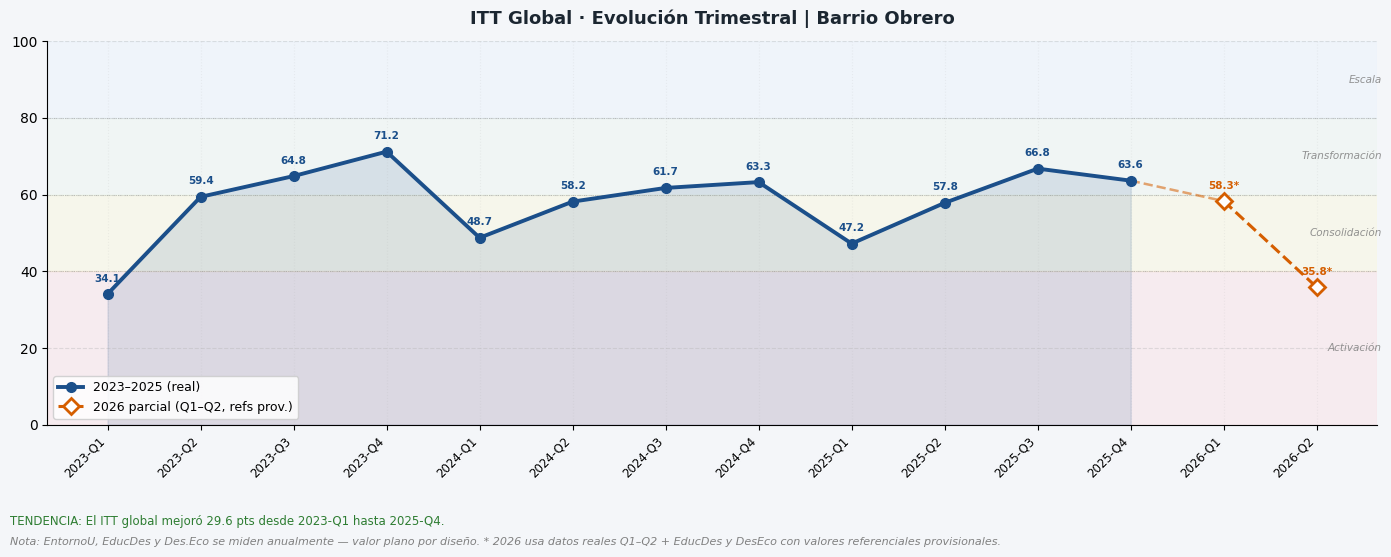

In [ ]:
# ── Evolución Trimestral ITT Global — Barrio Obrero (6 dimensiones) ───────────
REFS_Q = {
    'homicidios':     (0,     1.25,  True),
    'hurtos':         (2.5,  15.0,   True),
    'siniestralidad': (0.25,  3.75,  True),
    'lesionados':     (0.25,  3.0,   True),
    'mortales':       (0,     0.75,  True),
    'vif':            (0.25,  3.75,  True),
    'rinas':          (0,     2.5,   True),
}

rows_q = []
for _, r in corr_trim.iterrows():
    anio = int(r['año'])
    trim = int(r['trimestre'])
    if anio == 2026 and trim > 2:   # ← antes era > 1, ahora incluye Q1 y Q2
        continue

    def qs(col):
        v = r[col]
        if pd.isna(v): return np.nan
        rmin, rmax, inv = REFS_Q[col]
        return score_ref(v, rmin, rmax, inv)

    seg_vals = [x for x in [qs('homicidios'), qs('hurtos')] if not pd.isna(x)]
    mov_vals = [x for x in [qs('siniestralidad'), qs('lesionados'), qs('mortales')] if not pd.isna(x)]
    coh_vals = [x for x in [qs('vif'), qs('rinas')] if not pd.isna(x)]

    sc_seg = np.mean(seg_vals) if seg_vals else np.nan
    sc_mov = np.mean(mov_vals) if mov_vals else np.nan

    brow   = base[base['año'] == anio]
    sc_spa = float(brow['score_spa'].iloc[0]) if not brow.empty and 'score_spa' in brow.columns else np.nan
    sc_coh = np.mean(coh_vals + ([sc_spa] if not pd.isna(sc_spa) else [])) if coh_vals else np.nan

    sc_ent = float(brow['score_entorno_u'].iloc[0]) if not brow.empty else np.nan
    sc_edu = float(brow['score_educ_des'].iloc[0])  if not brow.empty else np.nan
    sc_de  = float(brow['score_des_eco'].iloc[0])   if not brow.empty else np.nan

    itt_q = (
        PESOS['Seguridad'] * (sc_seg if not pd.isna(sc_seg) else 0) +
        PESOS['Movilidad'] * (sc_mov if not pd.isna(sc_mov) else 0) +
        PESOS['EntornoU']  * (sc_ent if not pd.isna(sc_ent) else 0) +
        PESOS['EducDes']   * (sc_edu if not pd.isna(sc_edu) else 0) +
        PESOS['Cohesion']  * (sc_coh if not pd.isna(sc_coh) else 0) +
        PESOS['DesEco']    * (sc_de  if not pd.isna(sc_de)  else 0)
    )
    rows_q.append({
        'periodo': r['periodo'], 'año': anio, 'trimestre': trim,
        'ITT': itt_q, 'parcial': anio == 2026   # ← bandera nueva
    })

df_evol = pd.DataFrame(rows_q)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)

x_idx    = list(range(len(df_evol)))
n_per    = len(df_evol)
itt_vals = df_evol['ITT'].values

BANDAS = [
    (0,  40,  '#FFCDD2', 'Activación'),
    (40, 60,  '#FFF9C4', 'Consolidación'),
    (60, 80,  '#E8F5E9', 'Transformación'),
    (80, 100, '#E3F2FD', 'Escala'),
]
for y0, y1, color, lbl in BANDAS:
    ax.axhspan(y0, y1, alpha=0.25, color=color, zorder=0)
    ax.text(n_per - 0.3, (y0 + y1) / 2, lbl,
            fontsize=7.5, color='gray', ha='right', va='center',
            style='italic', alpha=0.85)

for y in [40, 60, 80]:
    ax.axhline(y, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# ── Serie histórica 2023-2025 ─────────────────────────────────────────────────
mask_hist = df_evol['parcial'] == False
mask_2026 = df_evol['parcial'] == True
x_hist    = [i for i, m in enumerate(mask_hist) if m]
x_2026    = [i for i, m in enumerate(mask_2026) if m]
v_hist    = df_evol.loc[mask_hist, 'ITT'].values
v_2026    = df_evol.loc[mask_2026, 'ITT'].values

ax.plot(x_hist, v_hist, '-o', linewidth=2.8, color='#1B4F8A',
        markersize=7, zorder=5, label='2023–2025 (real)')
ax.fill_between(x_hist, 0, v_hist, alpha=0.12, color='#1B4F8A')

# ── Serie 2026 parcial ────────────────────────────────────────────────────────
if len(x_2026) > 0:
    ax.plot([x_hist[-1], x_2026[0]], [v_hist[-1], v_2026[0]],
            color='#D55E00', linewidth=1.8, linestyle='--', alpha=0.55, zorder=4)
    ax.plot(x_2026, v_2026, '--D', linewidth=2.2, color='#D55E00',
            markersize=8, markerfacecolor='white', markeredgewidth=2,
            zorder=5, label='2026 parcial (Q1–Q2, refs prov.)')

# ── Anotaciones de valor ──────────────────────────────────────────────────────
for xi, val, es_parc in zip(x_idx, itt_vals, df_evol['parcial']):
    c_ann  = '#D55E00' if es_parc else '#1B4F8A'
    sufijo = '*' if es_parc else ''
    ax.annotate(f'{val:.1f}{sufijo}', xy=(xi, val), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=7.5,
                color=c_ann, fontweight='bold')

ax.legend(fontsize=9, loc='lower left', framealpha=0.85)
ax.set_xticks(x_idx)
ax.set_xticklabels(df_evol['periodo'].tolist(), rotation=45, ha='right', fontsize=8.5)
ax.set_ylim(0, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', linestyle=':', alpha=0.15)
ax.set_title('ITT Global · Evolución Trimestral | Barrio Obrero',
             fontsize=13, fontweight='bold', color='#1B2631', pad=12)

val_ini = df_evol[df_evol['año'] == 2023].iloc[0]['ITT']
row_ult = df_evol[(df_evol['año'] == 2025) & (df_evol['trimestre'] == 4)]
val_fin = row_ult.iloc[0]['ITT'] if not row_ult.empty else v_hist[-1]
delta   = val_fin - val_ini
dir_txt = 'mejoró' if delta > 0 else 'retrocedió'
delta_c = '#2E7D32' if delta > 0 else '#C62828'

fig.text(0.01, -0.06,
         f'TENDENCIA: El ITT global {dir_txt} {abs(delta):.1f} pts desde 2023-Q1 hasta 2025-Q4.',
         fontsize=8.5, color=delta_c, transform=fig.transFigure)
fig.text(0.01, -0.10,
         'Nota: EntornoU, EducDes y Des.Eco se miden anualmente — valor plano por diseño. '
         '* 2026 usa datos reales Q1–Q2 + EducDes y DesEco con valores referenciales provisionales.',
         fontsize=8, color='gray', style='italic', transform=fig.transFigure)

plt.tight_layout()
plt.savefig('itt_obrero_evolucion_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


Seg 2026: 66.0*  |  Mov 2026: 100.0*  |  Coh 2026: 86.2*


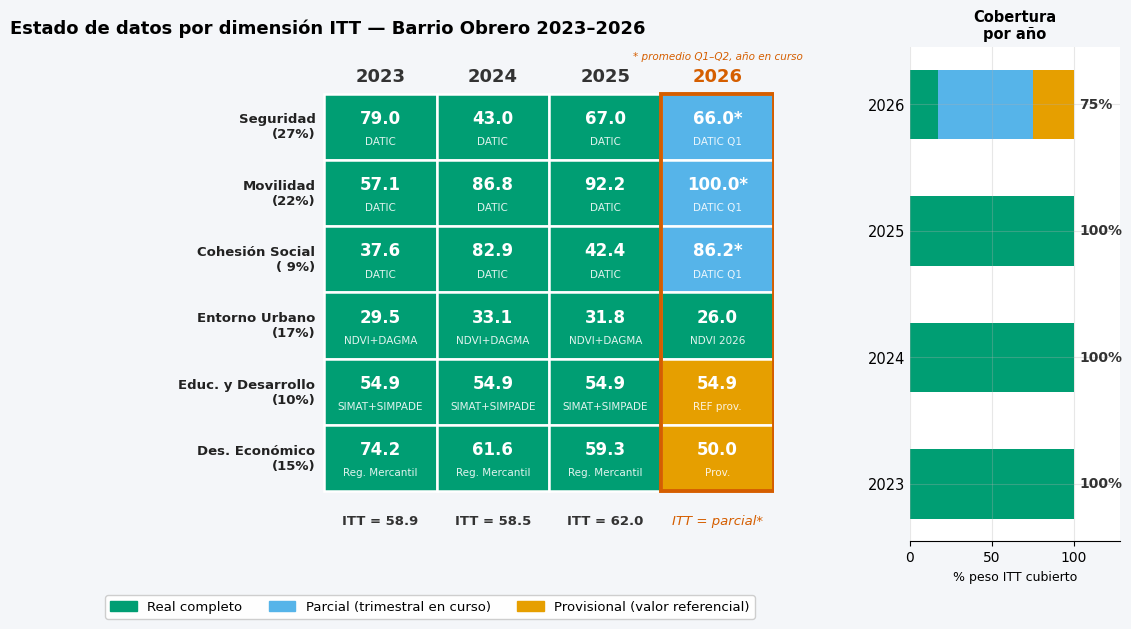

Guardado en: /content/itt_cobertura_datos_2026.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Celda: Estado de datos 2023–2026 por dimensión ITT
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path

OKI_VERDE   = '#009E73'
OKI_AZUL_C  = '#56B4E9'
OKI_NARANJA = '#E69F00'

# ── Scores parciales 2026 desde corr_trim ────────────────────────────────────
def _score_parcial(col, src):
    try:
        sub = base[base['año'] == 2026][col].dropna()
        if len(sub) == 0:
            return '—', src
        return f'{float(sub.iloc[0]):.1f}*', src
    except Exception:
        return '—', src

seg_val, seg_src = _score_parcial('score_seguridad', 'DATIC Q1')
mov_val, mov_src = _score_parcial('score_movilidad', 'DATIC Q1')
coh_val, coh_src = _score_parcial('score_cohesion',  'DATIC Q1')
print(f"Seg 2026: {seg_val}  |  Mov 2026: {mov_val}  |  Coh 2026: {coh_val}")

# ── Definición ────────────────────────────────────────────────────────────────
DIMS_INFO = [
    ('Seguridad',          '27%', 0.27),
    ('Movilidad',          '22%', 0.22),
    ('Cohesión Social',    ' 9%', 0.09),
    ('Entorno Urbano',     '17%', 0.17),
    ('Educ. y Desarrollo', '10%', 0.10),
    ('Des. Económico',     '15%', 0.15),
]
ANIOS = [2023, 2024, 2025, 2026]

# TABLA[dim][año] = (estado, score_txt, fuente_txt)
# estado: 3=Real completo  2=Parcial (en curso)  1=Provisional
TABLA = [
    # Seguridad
    [(3,'79.0','DATIC'),(3,'43.0','DATIC'),(3,'67.0','DATIC'),(2, seg_val, seg_src)],
    # Movilidad
    [(3,'57.1','DATIC'),(3,'86.8','DATIC'),(3,'92.2','DATIC'),(2, mov_val, mov_src)],
    # Cohesión Social
    [(3,'37.6','DATIC'),(3,'82.9','DATIC'),(3,'42.4','DATIC'),(2, coh_val, coh_src)],
    # Entorno Urbano
    [(3,'29.5','NDVI+DAGMA'),(3,'33.1','NDVI+DAGMA'),(3,'31.8','NDVI+DAGMA'),(3,'26.0','NDVI 2026')],
    # Educación y Desarrollo
    [(3,'54.9','SIMAT+SIMPADE'),(3,'54.9','SIMAT+SIMPADE'),(3,'54.9','SIMAT+SIMPADE'),(1,'54.9','REF prov.')],
    # Desarrollo Económico
    [(3,'74.2','Reg. Mercantil'),(3,'61.6','Reg. Mercantil'),(3,'59.3','Reg. Mercantil'),(1,'50.0','Prov.')],
]
ITT_ANUAL = {2023: '58.9', 2024: '58.5', 2025: '62.0', 2026: None}

C_MAP = {3: OKI_VERDE, 2: OKI_AZUL_C, 1: OKI_NARANJA}
NDIM = len(DIMS_INFO)
NANI = len(ANIOS)

fig = plt.figure(figsize=(15, 6.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1.1], wspace=0.28,
                         left=0.22, right=0.96, top=0.90, bottom=0.14)
ax  = fig.add_subplot(gs[0])
axb = fig.add_subplot(gs[1])

# ── Celdas del grid ───────────────────────────────────────────────────────────
for i in range(NDIM):
    row_y = NDIM - 1 - i
    for j, anio in enumerate(ANIOS):
        estado, score, fuente = TABLA[i][j]
        ax.add_patch(plt.Rectangle(
            (j, row_y), 1, 1,
            linewidth=1.8, edgecolor='white',
            facecolor=C_MAP[estado], zorder=1
        ))
        ax.text(j+0.5, row_y+0.63, score,
                ha='center', va='center', fontsize=12,
                fontweight='bold', color='white', zorder=2)
        ax.text(j+0.5, row_y+0.28, fuente,
                ha='center', va='center', fontsize=7.5,
                color='white', alpha=0.88, zorder=2)

# ── Etiquetas dimensiones ─────────────────────────────────────────────────────
for i, (dname, peso_s, _) in enumerate(DIMS_INFO):
    ax.text(-0.08, NDIM-1-i+0.5, f'{dname}\n({peso_s})',
            ha='right', va='center', fontsize=9.5,
            fontweight='bold', color='#222222')

# ── Etiquetas años ────────────────────────────────────────────────────────────
for j, anio in enumerate(ANIOS):
    c = '#D55E00' if anio == 2026 else '#333333'
    ax.text(j+0.5, NDIM+0.12, str(anio),
            ha='center', va='bottom', fontsize=13,
            color=c, fontweight='bold')

# ── Nota asterisco bajo columna 2026 ─────────────────────────────────────────
ax.text(3.5, NDIM+0.48, '* promedio Q1–Q2, año en curso',
        ha='center', va='bottom', fontsize=7.5,
        color='#D55E00', style='italic')

# ── ITT score debajo del grid ─────────────────────────────────────────────────
for j, anio in enumerate(ANIOS):
    c   = '#D55E00' if anio == 2026 else '#333333'
    val = ITT_ANUAL.get(anio)
    lbl = f'ITT = {val}' if val else 'ITT = parcial*'
    ax.text(j+0.5, -0.35, lbl,
            ha='center', va='top', fontsize=9.5, color=c,
            fontweight='bold' if val else 'normal',
            style='normal' if val else 'italic')

# ── Borde columna 2026 ────────────────────────────────────────────────────────
ax.add_patch(plt.Rectangle(
    (3, 0), 1, NDIM,
    linewidth=2.8, edgecolor='#D55E00', facecolor='none', zorder=4
))

ax.set_xlim(-2.8, NANI)
ax.set_ylim(-0.75, NDIM + 0.70)
ax.axis('off')
ax.set_title('Estado de datos por dimensión ITT — Barrio Obrero 2023–2026',
             fontsize=13, fontweight='bold', pad=10, loc='left', x=0.0)

# ── Barra apilada: cobertura del peso ITT por año ────────────────────────────
w_real = []; w_parcial = []; w_provis = []
for j in range(NANI):
    r = p = pv = 0.0
    for i, (_, _, peso) in enumerate(DIMS_INFO):
        e = TABLA[i][j][0]
        if e == 3:   r  += peso
        elif e == 2: p  += peso
        else:        pv += peso
    w_real.append(r * 100)
    w_parcial.append(p * 100)
    w_provis.append(pv * 100)

y_pos = np.arange(NANI)
axb.barh(y_pos, w_real,    color=OKI_VERDE,   height=0.55)
axb.barh(y_pos, w_parcial, color=OKI_AZUL_C,  height=0.55, left=w_real)
axb.barh(y_pos, w_provis,  color=OKI_NARANJA, height=0.55,
         left=[r+p for r, p in zip(w_real, w_parcial)])

for j in range(NANI):
    cobertura = w_real[j] + w_parcial[j]
    axb.text(103, j, f'{cobertura:.0f}%',
             va='center', fontsize=10, fontweight='bold', color='#333333')

axb.set_yticks(y_pos)
axb.set_yticklabels([str(a) for a in ANIOS], fontsize=10.5)
axb.set_xlim(0, 128)
axb.set_xlabel('% peso ITT cubierto', fontsize=9)
axb.set_title('Cobertura\npor año', fontsize=10.5, fontweight='bold')
axb.tick_params(axis='y', length=0)
axb.spines[['top', 'right', 'left']].set_visible(False)

# ── Leyenda ───────────────────────────────────────────────────────────────────
patches = [
    mpatches.Patch(color=OKI_VERDE,   label='Real completo'),
    mpatches.Patch(color=OKI_AZUL_C,  label='Parcial (trimestral en curso)'),
    mpatches.Patch(color=OKI_NARANJA, label='Provisional (valor referencial)'),
]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=9.5, frameon=True, framealpha=0.95,
           bbox_to_anchor=(0.5, 0.01))

# ── Guardar ───────────────────────────────────────────────────────────────────
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_cobertura_datos_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado en: {_img_dir / 'itt_cobertura_datos_2026.png'}")


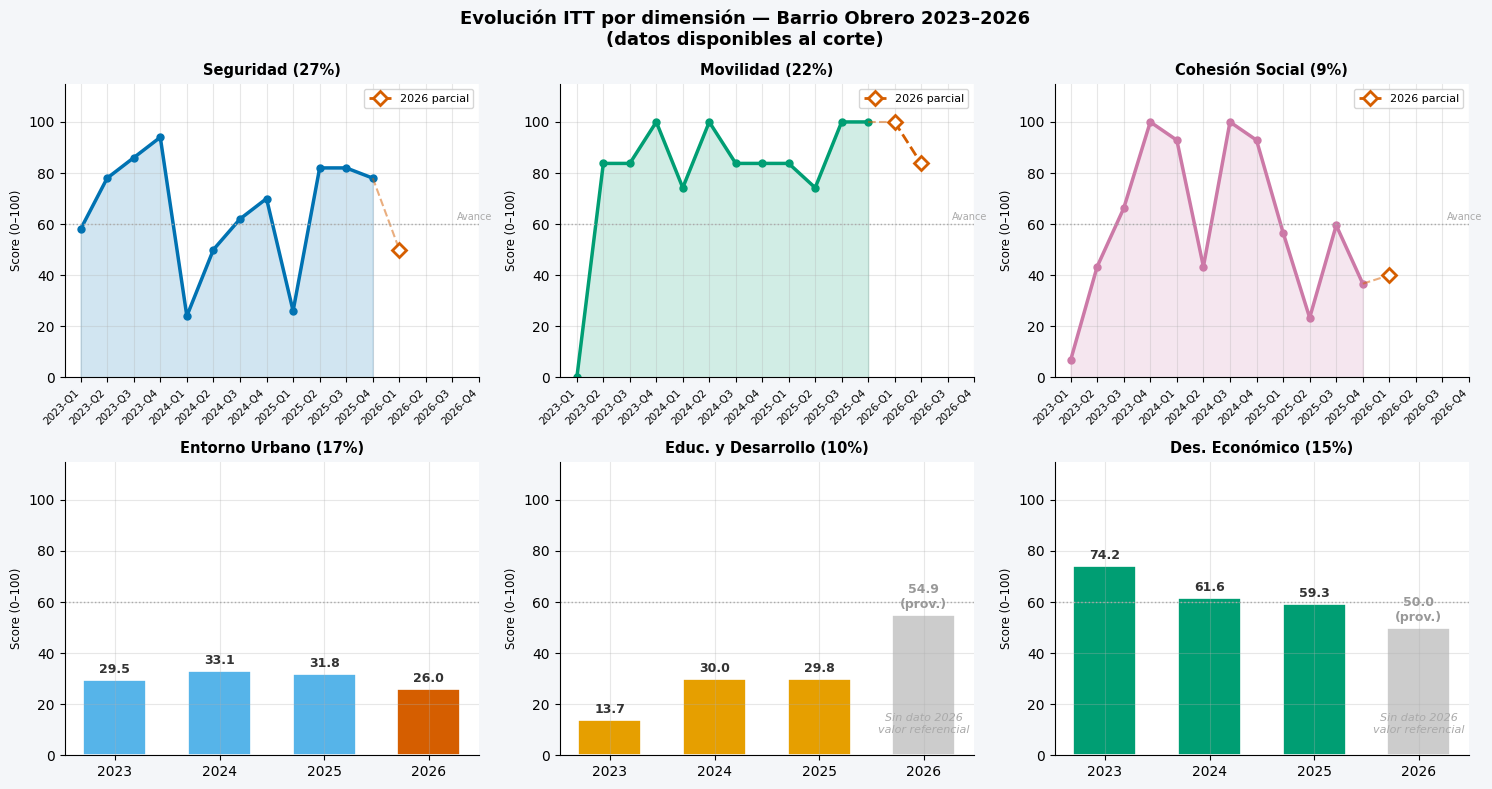

Guardado: /content/itt_dimensiones_evolucion_2026.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Celda: Evolución por dimensión 2023–2026 (datos disponibles al corte)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

OKI_AZUL    = '#0072B2'
OKI_VERDE   = '#009E73'
OKI_NARANJA = '#E69F00'
OKI_BERMELL = '#D55E00'
OKI_MORADO  = '#CC79A7'
OKI_AZUL_C  = '#56B4E9'

def _sr(v, rmin, rmax, inv=False):
    if pd.isna(v): return np.nan
    raw = np.clip((v - rmin) / (rmax - rmin) * 100, 0, 100)
    return 100 - raw if inv else raw

# ── Scores trimestrales desde corr_trim ───────────────────────────────────────
SPA_TRIM = {
    (2023,1):6,  (2023,2):1,  (2023,3):2,  (2023,4):0,
    (2024,1):0,  (2024,2):1,  (2024,3):0,  (2024,4):0,
    (2025,1):2,  (2025,2):17, (2025,3):6,  (2025,4):4,
    (2026,1):2,
}

df = corr_trim.copy()
df['sc_hom'] = df['homicidios'].apply(lambda v: _sr(v, 0,    5/4,  True))
df['sc_hur'] = df['hurtos'].apply(    lambda v: _sr(v, 10/4, 60/4, True))
df['sc_sin'] = df['siniestralidad'].apply(lambda v: _sr(v, 1/4, 15/4, True))
df['sc_les'] = df['lesionados'].apply(    lambda v: _sr(v, 1/4, 12/4, True))
df['sc_mor'] = df['mortales'].apply(      lambda v: _sr(v, 0,   3/4,  True))
df['sc_vif'] = df['vif'].apply(  lambda v: _sr(v, 1/4, 15/4, True))
df['sc_rin'] = df['rinas'].apply(lambda v: _sr(v, 0,   10/4, True))
df['sc_spa'] = df.apply(
    lambda r: _sr(SPA_TRIM.get((r['año'], r['trimestre']), np.nan), 0, 10/4, True), axis=1)

df['score_seg_q'] = (df['sc_hom'] + df['sc_hur']) / 2
df['score_mov_q'] = (df['sc_sin'] + df['sc_les'] + df['sc_mor']) / 3
df['score_coh_q'] = (df['sc_vif'] + df['sc_rin'] + df['sc_spa']) / 3

# ── Figura 2×3 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Evolución ITT por dimensión — Barrio Obrero 2023–2026\n(datos disponibles al corte)',
             fontsize=13, fontweight='bold')

ANIOS = [2023, 2024, 2025, 2026]

# ── Fila 1: dimensiones trimestrales ─────────────────────────────────────────
cfg_q = [
    (axes[0,0], 'score_seg_q', 'Seguridad (27%)',      OKI_AZUL),
    (axes[0,1], 'score_mov_q', 'Movilidad (22%)',       OKI_VERDE),
    (axes[0,2], 'score_coh_q', 'Cohesión Social (9%)',  OKI_MORADO),
]
for ax, col, titulo, color in cfg_q:
    periodos = df['periodo'].tolist()
    vals     = df[col].values.astype(float)
    x        = np.arange(len(periodos))
    is_2026  = df['año'].values == 2026

    x_h, v_h = x[~is_2026], vals[~is_2026]
    x_6, v_6 = x[is_2026],  vals[is_2026]

    ax.fill_between(x_h, np.where(~np.isnan(v_h), v_h, np.nan), alpha=0.18, color=color)
    ax.plot(x_h, np.where(~np.isnan(v_h), v_h, np.nan),
            color=color, linewidth=2.5, marker='o', markersize=5)

    valid_6 = ~np.isnan(v_6)
    if valid_6.any():
        ax.plot([x_h[-1], x_6[0]], [v_h[-1], v_6[0]],
                color=OKI_BERMELL, linewidth=1.5, linestyle='--', alpha=0.5)
        ax.plot(x_6[valid_6], v_6[valid_6],
                color=OKI_BERMELL, linewidth=2, linestyle='--',
                marker='D', markersize=7,
                markerfacecolor='white', markeredgewidth=2, label='2026 parcial')

    ax.axhline(60, color='#AAAAAA', linestyle=':', linewidth=1)
    ax.text(len(periodos) - 0.5, 61.5, 'Avance', fontsize=7,
            color='#AAAAAA', ha='right')
    ax.set_ylim(0, 115)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7.5)
    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_ylabel('Score (0–100)', fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    if valid_6.any():
        ax.legend(fontsize=8, framealpha=0.8)

# ── Fila 2: dimensiones anuales ───────────────────────────────────────────────
base_idx = base.set_index('año')

# es_real_2026: True = dato real en 2026 / False = provisional
cfg_a = [
    (axes[1,0], 'score_entorno_u', 'Entorno Urbano (17%)',     OKI_AZUL_C,  True),
    (axes[1,1], 'score_educ_des',  'Educ. y Desarrollo (10%)', OKI_NARANJA, False),
    (axes[1,2], 'score_des_eco',   'Des. Económico (15%)',     OKI_VERDE,   False),
]
for ax, col, titulo, color, es_real in cfg_a:
    vals = [float(base_idx.loc[a, col])
            if a in base_idx.index and not pd.isna(base_idx.loc[a, col])
            else np.nan for a in ANIOS]

    colores = [OKI_BERMELL if (a == 2026 and es_real) else
               '#CCCCCC'   if (a == 2026 and not es_real) else
               color for a in ANIOS]

    bars = ax.bar(range(4), vals, color=colores, width=0.6,
                  edgecolor='white', linewidth=1.2)

    for i, (bar, v) in enumerate(zip(bars, vals)):
        if not np.isnan(v):
            es_prov = ANIOS[i] == 2026 and not es_real
            ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
                    f'{v:.1f}' + ('\n(prov.)' if es_prov else ''),
                    ha='center', va='bottom', fontsize=9,
                    fontweight='bold',
                    color='#999999' if es_prov else '#333333')

    if not es_real:
        ax.text(3, 8, 'Sin dato 2026\nvalor referencial',
                ha='center', va='bottom', fontsize=8,
                color='#AAAAAA', style='italic')

    ax.axhline(60, color='#AAAAAA', linestyle=':', linewidth=1)
    ax.set_ylim(0, 115)
    ax.set_xticks(range(4))
    ax.set_xticklabels([str(a) for a in ANIOS], fontsize=10)
    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_ylabel('Score (0–100)', fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_dimensiones_evolucion_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {_img_dir / 'itt_dimensiones_evolucion_2026.png'}")


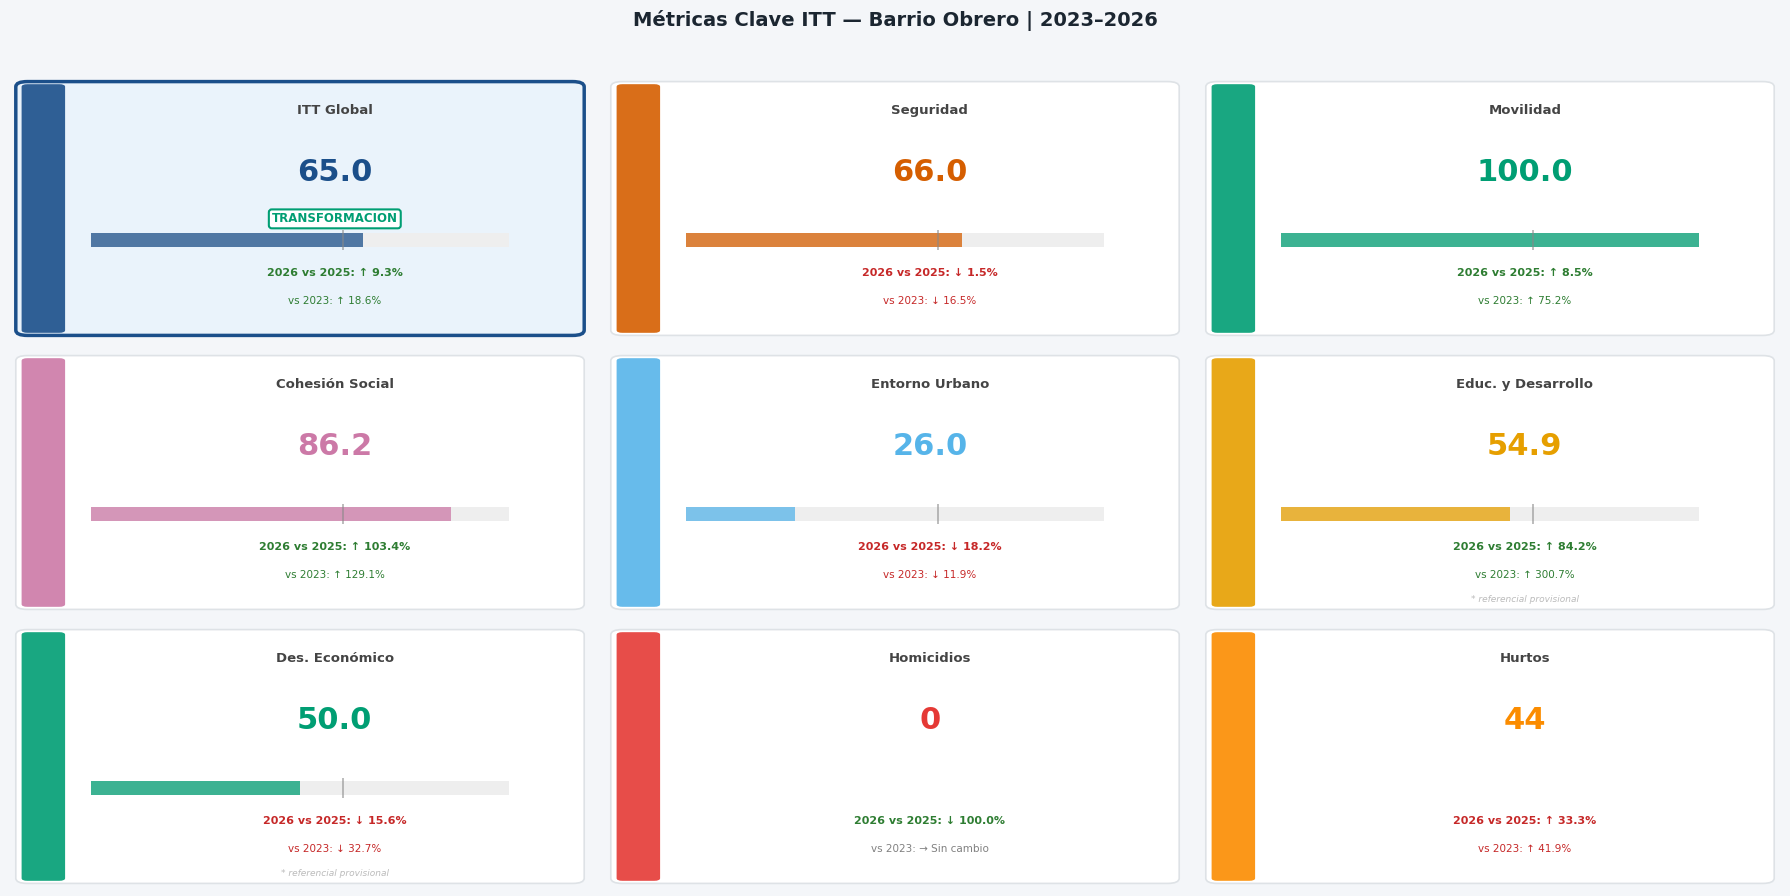

Guardado: /content/itt_obrero_metricas_clave.png


In [ ]:
# ── Métricas Clave — Dashboard ITT Barrio Obrero ──────────────────────────────
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def delta_lbl(pct, inv=True):
    if abs(pct) < 1: return '→ Sin cambio', 'gray'
    mejora = (pct < 0) if inv else (pct > 0)
    sym = '↑' if pct > 0 else '↓'
    return f'{sym} {abs(pct):.1f}%', ('#2E7D32' if mejora else '#C62828')

año_base = ANIOS[0]   # 2023 — línea base
año_ref  = 2025       # último año completo
año_ult  = ANIOS[-1]  # 2026

d_base = base[base['año'] == año_base].iloc[0]
d_ref  = base[base['año'] == año_ref].iloc[0]
d_ult  = base[base['año'] == año_ult].iloc[0]

# (titulo, columna, color, inverso, es_score_0-100, es_provisional)
CARDS = [
    ('ITT Global',         'ITT',             '#1B4F8A',   False, True,  False),
    ('Seguridad',          'score_seguridad', OKI_BERMELL, False, True,  False),
    ('Movilidad',          'score_movilidad', OKI_VERDE,   False, True,  False),
    ('Cohesión Social',    'score_cohesion',  OKI_MORADO,  False, True,  False),
    ('Entorno Urbano',     'score_entorno_u', OKI_AZUL_C,  False, True,  False),
    ('Educ. y Desarrollo', 'score_educ_des',  OKI_NARANJA, False, True,  True),
    ('Des. Económico',     'score_des_eco',   OKI_VERDE,   False, True,  True),
    ('Homicidios',         'homicidios',      '#E53935',   True,  False, False),
    ('Hurtos',             'hurtos',          '#FB8C00',   True,  False, False),
]

fig = plt.figure(figsize=(18, 9), facecolor=BG)
fig.suptitle(f'Métricas Clave ITT — Barrio Obrero | {año_base}–{año_ult}',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.99)

for i, (titulo, col, color, inv, es_score, es_prov) in enumerate(CARDS):
    ax = fig.add_subplot(3, 3, i + 1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    is_itt   = (col == 'ITT')
    bg_col   = '#EAF3FB' if is_itt else 'white'
    edge_col = color if is_itt else '#DEE2E6'
    edge_w   = 2.5   if is_itt else 1.2

    # Fondo card
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94,
        boxstyle='round,pad=0.02',
        linewidth=edge_w, edgecolor=edge_col, facecolor=bg_col))

    # Banda de color izquierda
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.055, 0.94,
        boxstyle='round,pad=0.01',
        linewidth=0, facecolor=color, alpha=0.9))

    v_base = float(d_base[col])
    v_ref  = float(d_ref[col])
    v_ult  = float(d_ult[col])

    # Título
    ax.text(0.56, 0.88, titulo,
            ha='center', va='center', fontsize=9.5,
            color='#444444', fontweight='bold')

    # Valor principal
    fmt = f'{v_ult:.1f}' if es_score else str(int(round(v_ult)))
    ax.text(0.56, 0.64, fmt,
            ha='center', va='center', fontsize=22,
            fontweight='bold', color=color)

    # Badge nivel ITT
    if is_itt and 'nivel' in d_ult.index:
        nivel  = str(d_ult['nivel'])
        ncolor = NIVEL_COLORS.get(nivel, '#888888')
        ax.text(0.56, 0.46, nivel.upper(),
                ha='center', va='center', fontsize=8.5,
                fontweight='bold', color=ncolor,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor=ncolor, linewidth=1.5))

    # Mini barra 0–100 (solo scores)
    if es_score:
        bx0, by, bw, bh = 0.14, 0.35, 0.72, 0.055
        ax.add_patch(mpatches.Rectangle(
            (bx0, by), bw, bh, facecolor='#EEEEEE', linewidth=0))
        fill_w = np.clip(v_ult / 100, 0, 1) * bw
        ax.add_patch(mpatches.Rectangle(
            (bx0, by), fill_w, bh, facecolor=color, linewidth=0, alpha=0.75))
        # Marca en 60 (umbral Transformación)
        ax.add_patch(mpatches.Rectangle(
            (bx0 + 0.60 * bw, by - 0.012), 0.004, bh + 0.024,
            facecolor='#888888', linewidth=0, alpha=0.55))

    # Comparaciones
    pct1 = safe_pct(v_ult, v_ref)
    lbl1, col1 = delta_lbl(pct1, inv)
    ax.text(0.56, 0.24, f'{año_ult} vs {año_ref}: {lbl1}',
            ha='center', fontsize=8, color=col1, fontweight='bold')

    pct2 = safe_pct(v_ult, v_base)
    lbl2, col2 = delta_lbl(pct2, inv)
    ax.text(0.56, 0.13, f'vs {año_base}: {lbl2}',
            ha='center', fontsize=7.5, color=col2)

    if es_prov:
        ax.text(0.56, 0.04, '* referencial provisional',
                ha='center', fontsize=6.5, color='#BBBBBB', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.97])
from pathlib import Path
_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')
plt.savefig(_img_dir / 'itt_obrero_metricas_clave.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Guardado: {_img_dir / 'itt_obrero_metricas_clave.png'}")


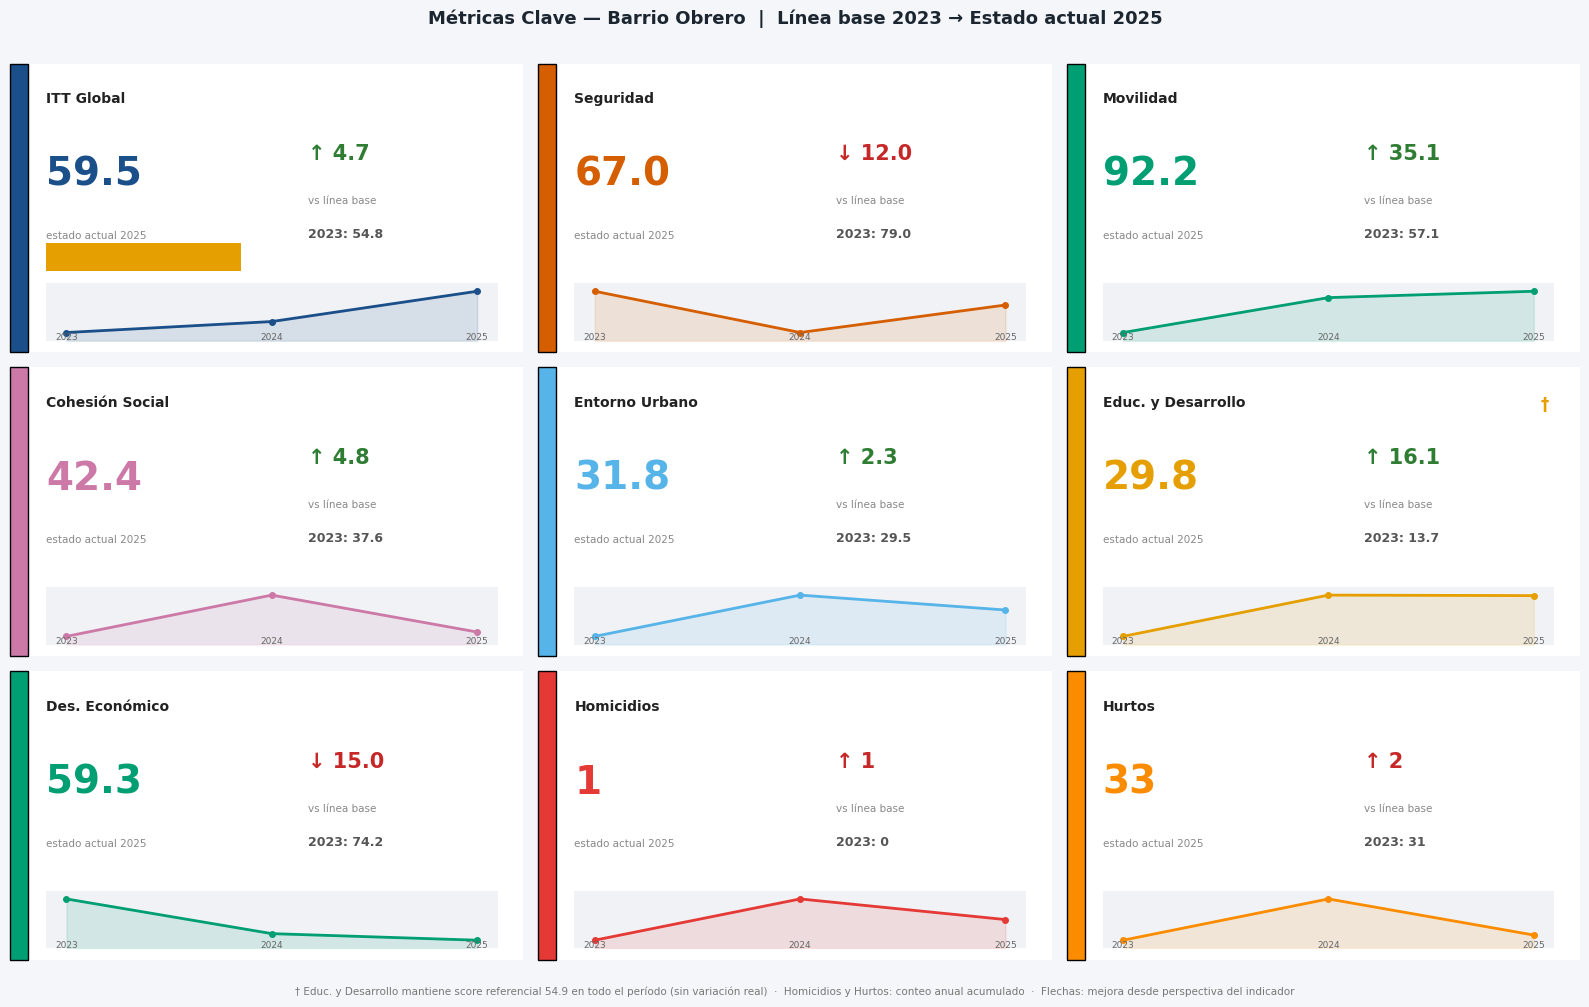

✓ Métricas Clave 2023–2025 generadas


In [ ]:
# ── Métricas Clave · Línea base 2023 → Estado actual 2025 ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_img_dir = IMG_DIR if 'IMG_DIR' in dir() else Path('/content')

# scores anuales (solo 2023-2025)
df_base = base[base['año'].isin([2023, 2024, 2025])].set_index('año')

# indicadores crudos anuales desde corr_trim
raw_anual = (corr_trim[corr_trim['año'].isin([2023, 2024, 2025])]
             .groupby('año')[['homicidios', 'hurtos']].sum())

# (título, columna, color, fuente_raw, es_inverso, es_provisional)
CARDS = [
    ('ITT Global',         'ITT',             '#1B4F8A', False, False, False),
    ('Seguridad',          'score_seguridad', '#D55E00', False, False, False),
    ('Movilidad',          'score_movilidad', '#009E73', False, False, False),
    ('Cohesión Social',    'score_cohesion',  '#CC79A7', False, False, False),
    ('Entorno Urbano',     'score_entorno_u', '#56B4E9', False, False, False),
    ('Educ. y Desarrollo', 'score_educ_des',  '#E69F00', False, False, True ),
    ('Des. Económico',     'score_des_eco',   '#009E73', False, False, False),
    ('Homicidios',         'homicidios',      '#E53935', True,  True,  False),
    ('Hurtos',             'hurtos',          '#FB8C00', True,  True,  False),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
fig.patch.set_facecolor('#F4F6F9')

for ax, (title, col, color, is_raw, es_inverso, es_prov) in zip(axes.flatten(), CARDS):
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

    src = raw_anual if is_raw else df_base
    try:
        v23 = float(src.loc[2023, col])
        v24 = float(src.loc[2024, col])
        v25 = float(src.loc[2025, col])
    except (KeyError, TypeError):
        ax.text(0.5, 0.5, 'Sin datos', transform=ax.transAxes,
                ha='center', va='center', fontsize=10, color='#999')
        continue

    delta   = v25 - v23
    mejora  = (delta < 0) if es_inverso else (delta >= 0)
    arrow   = '↑' if delta >= 0 else '↓'
    d_color = '#2E7D32' if mejora else '#C62828'
    fmt     = '.0f' if is_raw else '.1f'

    # banda de color izquierda
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.0, 0.0), 0.035, 1.0, boxstyle='square,pad=0',
        transform=ax.transAxes, facecolor=color, zorder=3, clip_on=False))

    # título
    ax.text(0.07, 0.90, title, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top', color='#222222')

    # valor principal 2025
    ax.text(0.07, 0.68, f'{v25:{fmt}}', transform=ax.transAxes,
            fontsize=28, fontweight='bold', va='top', color=color)
    ax.text(0.07, 0.42, 'estado actual 2025', transform=ax.transAxes,
            fontsize=7.5, va='top', color='#888888')

    # delta vs línea base
    ax.text(0.58, 0.72, f'{arrow} {abs(delta):{fmt}}',
            transform=ax.transAxes, fontsize=15, fontweight='bold',
            va='top', color=d_color)
    ax.text(0.58, 0.54, f'vs línea base', transform=ax.transAxes,
            fontsize=7.5, va='top', color='#888888')
    ax.text(0.58, 0.43, f'2023: {v23:{fmt}}', transform=ax.transAxes,
            fontsize=9, va='top', color='#555555', fontweight='bold')

    # nivel badge (solo ITT Global)
    if col == 'ITT':
        nivel = clasificar(v25)
        nc = NIVEL_COLORS.get(nivel, '#888888')
        badge = ax.inset_axes([0.07, 0.28, 0.38, 0.10])
        badge.set_facecolor(nc); badge.set_alpha(0.15)
        for s in badge.spines.values(): s.set_visible(False)
        badge.set_xticks([]); badge.set_yticks([])
        ax.text(0.265, 0.315, nivel, transform=ax.transAxes,
                ha='center', va='center', fontsize=8.5,
                fontweight='bold', color=nc)

    # badge provisional
    if es_prov:
        ax.text(0.94, 0.90, '†', transform=ax.transAxes,
                ha='right', va='top', fontsize=12,
                color='#E69F00', fontweight='bold')

    # sparkline 2023 → 2024 → 2025
    sp_ax = ax.inset_axes([0.07, 0.04, 0.88, 0.20])
    sp_ax.set_facecolor('#F0F2F5')
    for s in sp_ax.spines.values(): s.set_visible(False)
    sp_ax.set_xticks([]); sp_ax.set_yticks([])

    vals = [v23, v24, v25]
    ylo  = min(vals); yhi = max(vals)
    pad  = (yhi - ylo) * 0.2 if yhi > ylo else 1.0
    sp_ax.set_ylim(ylo - pad, yhi + pad)

    sp_ax.plot([0, 1, 2], vals, color=color, lw=2, marker='o', ms=4, zorder=3)
    sp_ax.fill_between([0, 1, 2], vals, ylo - pad, alpha=0.12, color=color)
    for xi, yr in zip([0, 1, 2], ['2023', '2024', '2025']):
        sp_ax.text(xi, ylo - pad * 0.1, yr,
                   ha='center', va='top', fontsize=6.5, color='#666666')

fig.suptitle(
    'Métricas Clave — Barrio Obrero  |  Línea base 2023 → Estado actual 2025',
    fontsize=13, fontweight='bold', y=0.99, color='#1B2631')

fig.text(0.5, 0.005,
    '† Educ. y Desarrollo mantiene score referencial 54.9 en todo el período (sin variación real)  '
    '·  Homicidios y Hurtos: conteo anual acumulado  ·  Flechas: mejora desde perspectiva del indicador',
    ha='center', fontsize=7.5, color='#777777')

plt.tight_layout(rect=[0, 0.025, 1, 0.985])
plt.savefig(_img_dir / 'metricas_clave_linea_base.png',
            dpi=150, bbox_inches='tight', facecolor='#F4F6F9')
plt.show()
print("✓ Métricas Clave 2023–2025 generadas")


In [43]:
print('base existe:', 'base' in globals())
print('df_educ existe:', 'df_educ' in globals())
print('score_ref existe:', 'score_ref' in globals())
print('clasificar existe:', 'clasificar' in globals())

if 'base' in globals():
    print('base columnas clave:')
    print([c for c in ['año','score_seguridad','score_movilidad','score_entorno_u','score_des_eco','score_vif','score_rinas','score_spa'] if c in base.columns])

if 'df_educ' in globals():
    print('df_educ columnas:')
    print(df_educ.columns.tolist())

base existe: True
df_educ existe: False
score_ref existe: True
clasificar existe: True
base columnas clave:
['año', 'score_seguridad', 'score_movilidad', 'score_entorno_u', 'score_des_eco', 'score_vif', 'score_rinas', 'score_spa']


In [42]:
# ── Celda ITT-5D: recalculo global correcto con Desarrollo Social directo ────
# Requiere:
# - base ya cargada
# - df_educ ya construido
# - score_ref ya definido
# - clasificar ya definido

import numpy as np
import pandas as pd

# 1) Pesos oficiales 5 dimensiones
PESOS = {
    'Seguridad': 0.27,
    'Movilidad': 0.22,
    'DesSocial': 0.19,
    'EntornoU':  0.17,
    'DesEco':    0.15
}

# 2) Validaciones base
if 'base' not in globals():
    raise RuntimeError("No existe `base` en la sesión. Ejecuta primero las celdas base del ITT.")

if 'df_educ' not in globals():
    raise RuntimeError("No existe `df_educ` en la sesión. Ejecuta primero la celda de Educación/Desarrollo.")

if 'score_ref' not in globals():
    raise RuntimeError("No existe `score_ref` en la sesión. Ejecuta primero la celda donde se define.")

if 'clasificar' not in globals():
    raise RuntimeError("No existe `clasificar` en la sesión. Ejecuta primero la celda base del ITT.")

req_base = ['año', 'score_seguridad', 'score_movilidad', 'score_entorno_u', 'score_des_eco']
faltan_base = [c for c in req_base if c not in base.columns]
if faltan_base:
    raise RuntimeError(f"Faltan columnas en `base`: {faltan_base}")

# 3) Verificar componentes sociales existentes
for col in ['score_vif', 'score_rinas', 'score_spa']:
    if col not in base.columns:
        base[col] = np.nan

# 4) Preparar bloque educativo-social
if 'año' not in df_educ.columns or 'matricula' not in df_educ.columns:
    raise RuntimeError("`df_educ` debe tener al menos las columnas `año` y `matricula`.")

# Fallback si score_desercion no existe pero sí tasa_desercion
if 'score_desercion' not in df_educ.columns:
    if 'tasa_desercion' in df_educ.columns and 'REF_DES_MIN' in globals() and 'REF_DES_MAX' in globals():
        df_educ = df_educ.copy()
        df_educ['score_desercion'] = df_educ['tasa_desercion'].apply(
            lambda v: score_ref(v, REF_DES_MIN, REF_DES_MAX, True) if pd.notna(v) else np.nan
        )
    else:
        raise RuntimeError(
            "No existe `score_desercion` en `df_educ`, ni hay suficientes insumos para calcularlo."
        )

# 5) Score de matricula
mat_valid = df_educ['matricula'].dropna()
if len(mat_valid) == 0:
    raise RuntimeError("`df_educ['matricula']` no tiene valores válidos.")

REF_MAT_MIN = float(mat_valid.min())
REF_MAT_MAX = float(mat_valid.max())

df_social_educ = df_educ[['año', 'matricula', 'score_desercion']].copy()
df_social_educ['score_matricula'] = df_social_educ['matricula'].apply(
    lambda v: score_ref(v, REF_MAT_MIN, REF_MAT_MAX, False) if pd.notna(v) else np.nan
)

# 6) Pasar score_matricula y score_desercion a base
for _, row in df_social_educ.iterrows():
    año = int(row['año'])
    base.loc[base['año'] == año, 'score_matricula'] = row['score_matricula']
    base.loc[base['año'] == año, 'score_desercion'] = row['score_desercion']

# 7) Desarrollo Social directo con 5 indicadores base
def calc_score_des_social(row):
    vals = [
        row['score_vif'] if 'score_vif' in row.index else np.nan,
        row['score_rinas'] if 'score_rinas' in row.index else np.nan,
        row['score_spa'] if 'score_spa' in row.index else np.nan,
        row['score_matricula'] if 'score_matricula' in row.index else np.nan,
        row['score_desercion'] if 'score_desercion' in row.index else np.nan,
    ]
    vals = [v for v in vals if pd.notna(v)]
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

base['score_des_social'] = base.apply(calc_score_des_social, axis=1)

# 8) 2026: si no tiene corte anual completo comparable, usar carry-forward 2025
if (base['año'] == 2025).any():
    sc_social_2025 = float(base.loc[base['año'] == 2025, 'score_des_social'].iloc[0])
    if (base['año'] == 2026).any():
        base.loc[base['año'] == 2026, 'score_des_social'] = sc_social_2025

# 9) Recalculo global ITT 5 dimensiones
base['ITT'] = (
    PESOS['Seguridad'] * base['score_seguridad'] +
    PESOS['Movilidad'] * base['score_movilidad'] +
    PESOS['DesSocial'] * base['score_des_social'] +
    PESOS['EntornoU']  * base['score_entorno_u'] +
    PESOS['DesEco']    * base['score_des_eco']
)

base['nivel'] = base['ITT'].apply(clasificar)

print('Componentes de Desarrollo Social usados en el ITT:')
cols_ds = [
    'año', 'score_vif', 'score_rinas', 'score_spa',
    'score_matricula', 'score_desercion', 'score_des_social'
]
print(base[cols_ds].round(1).to_string(index=False))
print()

print('ITT global actualizado — 5 dimensiones:')
cols_itt = [
    'año', 'score_seguridad', 'score_movilidad',
    'score_des_social', 'score_entorno_u', 'score_des_eco',
    'ITT', 'nivel'
]
print(base[cols_itt].round(1).to_string(index=False))

RuntimeError: No existe `df_educ` en la sesión. Ejecuta primero la celda de Educación/Desarrollo.

## Celda 17 — Exportar a Excel


In [ ]:
# ── Exportar consolidación ITT — 6 dimensiones ───────────────────────────────
import os, openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path

OUT_DIR = REPO / "outputs" / "itt_barrio_obrero"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = OUT_DIR / "ITT_Barrio_Obrero_Consolidado.xlsx"

# ── Hoja 1: ITT Resumen Anual ─────────────────────────────────────────────────
cols_anual = [
    'año',
    'score_seguridad','score_movilidad','score_cohesion',
    'score_entorno_u','score_educ_des','score_des_eco',
    'ITT','nivel'
]
cols_anual   = [c for c in cols_anual if c in base.columns]
df_itt_anual = base[cols_anual].copy().round(2)
df_itt_anual['nota_estado'] = df_itt_anual['año'].apply(
    lambda a: 'Parcial Q1-Q2 | EducDes y DesEco referenciales' if a == 2026 else 'Real'
)

# ── Hoja 2: ITT Trimestral ────────────────────────────────────────────────────
if 'df_evol' in dir():
    _df_evol = df_evol.copy()
    if 'parcial' not in _df_evol.columns:
        _df_evol['parcial'] = _df_evol['año'] == 2026
    df_itt_trim = _df_evol.round(2)
else:
    df_itt_trim = pd.DataFrame({'nota': ['Ejecutar celda de Evolucion Trimestral primero']})

# ── Hoja 3: Seguridad ─────────────────────────────────────────────────────────
_seg_raw = corr_trim.groupby('año')[['homicidios','hurtos']].sum().reset_index()
_seg_sc  = base[['año','score_seguridad']].copy()
df_seg   = _seg_raw.merge(_seg_sc, on='año', how='left')
df_seg['score_homicidios'] = df_seg['homicidios'].apply(
    lambda v: round(score_ref(v, *REFS['homicidios'][:3]), 1))
df_seg['score_hurtos'] = df_seg['hurtos'].apply(
    lambda v: round(score_ref(v, *REFS['hurtos'][:3]), 1))
df_seg['nota_estado'] = df_seg['año'].apply(
    lambda a: 'Parcial Q1-Q2' if a == 2026 else 'Real')
df_seg = df_seg[['año','homicidios','hurtos',
                  'score_homicidios','score_hurtos',
                  'score_seguridad','nota_estado']].round(2)

# ── Hoja 4: Movilidad ─────────────────────────────────────────────────────────
_mov_raw = corr_trim.groupby('año')[['siniestralidad','lesionados','mortales']].sum().reset_index()
_mov_sc  = base[['año','score_movilidad']].copy()
df_mov   = _mov_raw.merge(_mov_sc, on='año', how='left')
df_mov['score_siniestralidad'] = df_mov['siniestralidad'].apply(
    lambda v: round(score_ref(v, *REFS['siniestralidad'][:3]), 1))
df_mov['score_lesionados'] = df_mov['lesionados'].apply(
    lambda v: round(score_ref(v, *REFS['lesionados'][:3]), 1))
df_mov['score_mortales'] = df_mov['mortales'].apply(
    lambda v: round(score_ref(v, *REFS['mortales'][:3]), 1))
df_mov['nota_estado'] = df_mov['año'].apply(
    lambda a: 'Parcial Q1-Q2' if a == 2026 else 'Real')
df_mov = df_mov[['año','siniestralidad','lesionados','mortales',
                  'score_siniestralidad','score_lesionados','score_mortales',
                  'score_movilidad','nota_estado']].round(2)

# ── Hoja 5: Cohesion Social ───────────────────────────────────────────────────
# VIF y riñas: corr_trim | SPA: base (viene de comparendos, no de corr_trim)
_coh_raw = corr_trim.groupby('año')[['vif','rinas']].sum().reset_index()
_coh_spa = base[['año'] + [c for c in ['spa','score_spa','score_cohesion'] if c in base.columns]].copy()
df_coh   = _coh_raw.merge(_coh_spa, on='año', how='left')
df_coh['score_vif']   = df_coh['vif'].apply(
    lambda v: round(score_ref(v, *REFS['vif'][:3]), 1))
df_coh['score_rinas'] = df_coh['rinas'].apply(
    lambda v: round(score_ref(v, *REFS['rinas'][:3]), 1))
df_coh['nota_estado'] = df_coh['año'].apply(
    lambda a: 'Parcial Q1-Q2' if a == 2026 else 'Real')
_coh_cols = ['año','vif','rinas']
if 'spa' in df_coh.columns:       _coh_cols += ['spa']
_coh_cols += ['score_vif','score_rinas']
if 'score_spa' in df_coh.columns: _coh_cols += ['score_spa']
_coh_cols += ['score_cohesion','nota_estado']
df_coh = df_coh[_coh_cols].round(2)

# ── Hoja 6: Entorno Urbano ────────────────────────────────────────────────────
filas_eu = []
for año in ANIOS:
    st   = ndvi_stats.get(año, {})
    brow = base[base['año'] == año]
    filas_eu.append({
        'año':                     año,
        'ndvi_mean':               round(st.get('ndvi_mean', np.nan), 4),
        'pct_verde_%':             round(st.get('pct_verde',  np.nan), 1),
        'area_verde_m2':           round(st.get('verde_m2',   np.nan), 0),
        'densidad_arboles_arb_ha': round(globals().get('dens_arboles_ha', np.nan), 1),
        'score_entorno_u':         round(float(brow['score_entorno_u'].iloc[0]), 2) if not brow.empty else np.nan,
        'nota_estado':             'Real (NDVI anual + DAGMA)',
    })
df_eu = pd.DataFrame(filas_eu)

# ── Hoja 7: Educacion ─────────────────────────────────────────────────────────
filas_educ = []
for año in AÑOS_EDUC:
    try:    m_f = float(matricula_simat.get(año, np.nan))
    except: m_f = np.nan
    try:    d_f = float(desertores_educ.get(año, np.nan))
    except: d_f = np.nan
    try:    r_f = float(repitentes_simat.get(año, np.nan))
    except: r_f = np.nan
    tasa_des = round(d_f/m_f*100, 2) if (not np.isnan(d_f) and not np.isnan(m_f) and m_f > 0) else np.nan
    tasa_rep = round(r_f/m_f*100, 2) if (not np.isnan(r_f) and not np.isnan(m_f) and m_f > 0) else np.nan
    brow = base[base['año'] == año]
    sc   = round(float(brow['score_educ_des'].iloc[0]), 2) if not brow.empty else np.nan
    filas_educ.append({
        'año': año, 'matricula': m_f, 'desertores': d_f, 'repitentes': r_f,
        'tasa_desercion_%': tasa_des, 'tasa_repitencia_%': tasa_rep,
        'score_educ_des': sc,
        'nota_estado': 'Real (SIMAT + SIMPADE)' if not np.isnan(sc) else 'Sin datos — SIMAT requerido',
    })
df_educ = pd.DataFrame(filas_educ).round(2)

# ── Hoja 8: Desarrollo Economico ─────────────────────────────────────────────
if 'df_de_scores' in dir():
    df_de_export = df_de_scores.copy().round(2)
elif 'df_de_anual' in dir():
    df_de_export = df_de_anual.copy().round(2)
else:
    df_de_export = pd.DataFrame({'nota': ['Ejecutar celdas DE primero']})
if 'año' in df_de_export.columns:
    df_de_export['nota_estado'] = df_de_export['año'].apply(
        lambda a: 'Provisional (sin corte Reg. Mercantil 2026)' if a == 2026 else 'Real')

# ── Hoja 9: Indicadores Trimestrales (raw) ───────────────────────────────────
df_trim_export = corr_trim.copy()

# ── Armar hojas ───────────────────────────────────────────────────────────────
sheets = {
    'ITT_Resumen':              df_itt_anual,
    'ITT_Trimestral':           df_itt_trim,
    'Seguridad':                df_seg,
    'Movilidad':                df_mov,
    'Cohesion_Social':          df_coh,
    'Entorno_Urbano':           df_eu,
    'Educacion':                df_educ,
    'Desarrollo_Economico':     df_de_export,
    'Indicadores_Trimestrales': df_trim_export,
}

# ── Escribir Excel ────────────────────────────────────────────────────────────
with pd.ExcelWriter(str(EXPORT_PATH), engine='openpyxl') as writer:
    for sheet_name, df in sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

    wb = writer.book
    header_fill = PatternFill('solid', fgColor='1B4F8A')
    header_font = Font(color='FFFFFF', bold=True)
    provis_fill = PatternFill('solid', fgColor='FFF3CD')
    thin        = Side(style='thin', color='CCCCCC')
    border      = Border(left=thin, right=thin, top=thin, bottom=thin)

    for ws in wb.worksheets:
        for cell in ws[1]:
            cell.fill      = header_fill
            cell.font      = header_font
            cell.alignment = Alignment(horizontal='center', wrap_text=True)
        for col in ws.columns:
            max_len = max((len(str(c.value)) for c in col if c.value), default=8)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 3, 35)
        ws.freeze_panes = 'A2'
        col_names = [cell.value for cell in ws[1]]
        año_col   = col_names.index('año') + 1 if 'año' in col_names else None
        for row in ws.iter_rows(min_row=2):
            es_2026 = (año_col and row[año_col - 1].value == 2026)
            for cell in row:
                cell.border    = border
                cell.alignment = Alignment(horizontal='center')
                if es_2026:
                    cell.fill = provis_fill

print(f'Excel guardado: {EXPORT_PATH}')
print(f'Hojas: {", ".join(sheets.keys())}')

try:
    from google.colab import files
    files.download(str(EXPORT_PATH))
    print('Descarga iniciada.')
except ImportError:
    print('Entorno local — archivo en outputs/itt_barrio_obrero/')


Excel guardado: /content/itt_repos_cali/outputs/itt_barrio_obrero/ITT_Barrio_Obrero_Consolidado.xlsx
Hojas: ITT_Resumen, ITT_Trimestral, Seguridad, Movilidad, Cohesion_Social, Entorno_Urbano, Educacion, Desarrollo_Economico, Indicadores_Trimestrales


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada.


In [ ]:
import base64
from IPython.display import HTML

ruta = '/content/itt_repos_cali/outputs/itt_barrio_obrero/ITT_Barrio_Obrero_Consolidado.xlsx'
with open(ruta, 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

mime = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
HTML(f'<a href="data:{mime};base64,{b64}" download="ITT_Barrio_Obrero_Consolidado.xlsx">'
     '<b>Haz click aqui para descargar el Excel</b></a>')